In [73]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [74]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


In [75]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

# Compute Fairness
An addition is made to compute_fairness_metrics. A count_group dictionary is made specifying the subgroup and the "length" which is TN + FP + FN + TP

## Classifier and Predictions

## Functions

### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

Compute the previous functions, plus the confusion matrix for...

## Build the dictionaries 

In the form {Subgroup: data}

In [76]:
sensible_attribute = 'sex-race'

In [77]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [78]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


sex
Precision: 0.7622682660850599, Recall: 0.5849372384937238, Accuracy: 0.8538083538083538, F1: 0.6619318181818182
{np.int64(0): array([[1451,   17],
       [  96,   85]]), np.int64(1): array([[2020,  201],
       [ 400,  614]])}
sex
Precision: 0.7685279187817259, Recall: 0.6276948590381426, Accuracy: 0.8614124872057318, F1: 0.6910086718393428
{np.int64(0): array([[1413,   17],
       [ 100,   80]]), np.int64(1): array([[2038,  211],
       [ 349,  677]])}
race
Precision: 0.7622682660850599, Recall: 0.5849372384937238, Accuracy: 0.8538083538083538, F1: 0.6619318181818182
{np.int64(1): array([[3000,  211],
       [ 456,  673]]), np.int64(0): array([[471,   7],
       [ 40,  26]])}
race
Precision: 0.7685279187817259, Recall: 0.6276948590381426, Accuracy: 0.8614124872057318, F1: 0.6910086718393428
{np.int64(1): array([[2966,  219],
       [ 399,  731]]), np.int64(0): array([[485,   9],
       [ 50,  26]])}
sex-race
Precision: 0.7622682660850599, Recall: 0.5849372384937238, Accuracy: 0.85

# Compute Penalties: Validation and Test

Compute harmonic, geometric and arithmetic penalties, but only use harmonic for simplicity

In [79]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

# Model 2: Fit on training (with weights), predict on test

In [80]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [81]:
def model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights, model_type='GB'):
  # Note: weights were computed on validation set, then propagated to the training set based on group membership.
  #       now we fit the model on training set with these weights and evaluate on test set.
  
  
  if model_type=='GB':
    # Model 2: Fit on training, predict on test
    model = GradientBoostingClassifier(random_state = 1234).fit(X_train[sensible_attribute], y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test[sensible_attribute])
  elif model_type=='RF':
    model = RandomForestClassifier(random_state = 1234).fit(X_train[sensible_attribute], y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test[sensible_attribute])
  elif model_type=='XGB':
    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and test
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    model = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test_numeric)

  sensible_indexes = X_test[sensible_attribute][sensible_attribute].loc[list(X_test[sensible_attribute].index)]
  cm = confusion_matrix(y_test[sensible_attribute], y_pred_on_test, labels=[0,1])
  print(cm)

  precision, recall, accuracy, f1_score = performance_metrics(y_test[sensible_attribute], y_pred_on_test)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  # Compute fairness metrics on TEST set predictions
  cm_dict = compute_cm_group(df, sensible_attribute, sensible_indexes, y_pred_on_test, y_test[sensible_attribute], X_test[sensible_attribute], [0,1])
  for metric in fair_metrics:
    fairness_metrics_dict_after[metric], count_groups_after = compute_fairness_metrics_and_counts(cm_dict, metric, sensible_attribute, mapping, dataset_path)

  # TODO: Change logic so it applies to all metrics (computing difference of fairness metrics after and before reweighitng)
  last_metric = fair_metrics[-1]
  for k in fairness_metrics_dict_after[last_metric].keys():
    a = fairness_metrics_dict_val[sensible_attribute][last_metric][k]
    b = fairness_metrics_dict_after[last_metric][k]
    diff = b - a
    # print(f"Group {k}: before={a}, after={b}, diff={diff}")

  return precision, recall, accuracy, f1_score

# Calculating and Implementing weights

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [82]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [83]:
def compute_weights_notsized(lambda_=5.0, m='PPE'):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [84]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 22792, Unique weights per group: {'00': 2.695755225166989, '01': 3.119138352568861, '10': 3.561409871019609, '11': 0.01}


In [85]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized)

[[3508  171]
 [ 569  637]]
Precision: 0.7883663366336634, Recall: 0.5281923714759535, Accuracy: 0.8485158648925282, F1: 0.6325719960278053


(0.7883663366336634,
 0.5281923714759535,
 0.8485158648925282,
 0.6325719960278053)

### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [86]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [87]:
def compute_weights_sized(lambda_=1.0, m='PPE'):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [88]:
weights_sized = compute_weights_sized(10.0)

Training samples: 22792, Unique weights per group: {'00': 1.3041604292522222, '01': 2.904153302308252, '10': 1.493243226705168, '11': 0.01}


### $w_i = 1 + \lambda * Penalty(g_i) $  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;   *WITH FAIRNESS METRICS FLAT GROUP*

With penalty computed, for different metrics

In [89]:
def compute_weights_flatgroup(lambda_, metric_penalties):
    train_df = X_train[sensible_attribute].copy()

    weights_for_training = np.ones(len(train_df))
    
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in metric_penalties.items()
    }
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    return weights_for_training

Compute flatgroup penalties

In [90]:
# list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
list_of_metrics = ['fpn', 'ppe', 'fpa', 'fpp']
df_val = X_val[sensible_attribute].copy()

weights_per_metric = {}

for m in list_of_metrics:
    # Compute flat penalties for metric m 
    metric_penalties = compute_sample_weights_flat_group_allmetrics(
        df_val, 
        y_val[sensible_attribute], 
        y_pred_val[sensible_attribute], 
        sensible_attribute, 
        focus_on=m, 
    )

    weights_per_metric[m] = compute_weights_flatgroup(5.0, metric_penalties)
    
    print(f"Metric: {m}, Penalties: {metric_penalties}")

Metric: fpn, Penalties: {'11': np.float64(-7.6797649963812775), '01': np.float64(40.93832457835182), '10': np.float64(63.789568045060946), '00': np.float64(-66.13756613756614)}
Metric: ppe, Penalties: {'11': np.float64(-31.752259417030775), '01': np.float64(73.97601578238303), '10': np.float64(71.79719274776988), '00': np.float64(20.797720797720793)}
Metric: fpa, Penalties: {'11': np.float64(-17.388351523865538), '01': np.float64(35.77867946847757), '10': np.float64(-13.760698064470374), '00': np.float64(55.61469357617525)}
Metric: fpp, Penalties: {'11': np.float64(-23.67549872626357), '01': np.float64(68.99192078512338), '10': np.float64(68.71692104136729), '00': np.float64(15.098722415795576)}


In [91]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric['ppe'])

[[3551  128]
 [ 613  593]]
Precision: 0.8224687933425797, Recall: 0.4917081260364842, Accuracy: 0.8483111566018424, F1: 0.6154644525168655


(0.8224687933425797,
 0.4917081260364842,
 0.8483111566018424,
 0.6154644525168655)

---

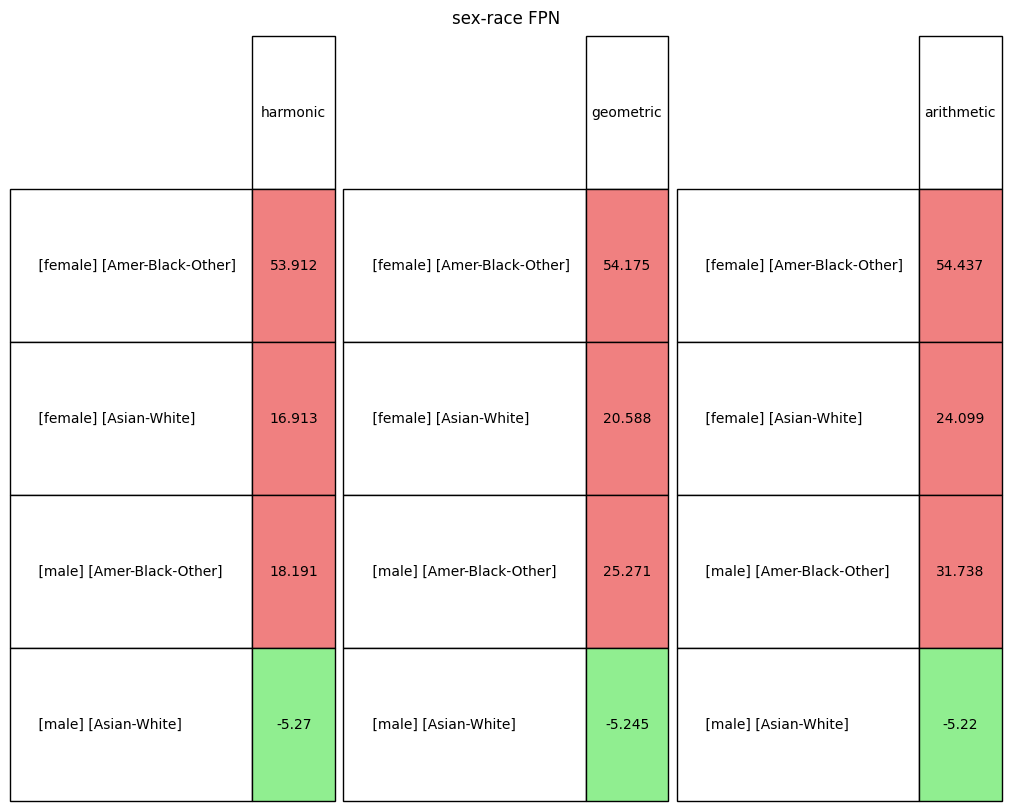

---

# Model 2: Fairness metrics and penalty after reweighting

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

In [92]:
from sklearn.ensemble import RandomForestClassifier

In [93]:
def compute_penalties_after_reweighting(weights, fairness_metric, verbose=False):
    """
    Compute penalties after reweighting using a SINGLE model trained on the combined attribute.
    
    Optimizations:
    - Train only ONE model (on sensible_attribute) instead of 3
    - Read CSV only ONCE
    - Use same predictions for all attribute fairness computations
    """
    # Load dataframe ONCE
    df_fresh = pd.read_csv(dataset_path)
    
    # Train ONE model on the combined sensible_attribute with weights
    model_reweighted = RandomForestClassifier(random_state=1234).fit(
        X_train[sensible_attribute], 
        y_train[sensible_attribute], 
        sample_weight=weights
    )
    y_pred_reweighted = model_reweighted.predict(X_test[sensible_attribute])
    
    if verbose:
        precision, recall, accuracy, f1 = performance_metrics(y_test[sensible_attribute], y_pred_reweighted)
        print(f"Reweighted model - Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}, F1: {f1:.4f}")
    
    # Compute fairness metrics for each attribute using the SAME predictions
    fairness_metrics_reweighted = {}
    
    for attribute in attributes:
        # Create attribute column if combined
        df_attr = df_fresh.copy()
        if '-' in attribute:
            individual_attrs = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str), 
                [df_attr[col] for col in individual_attrs]
            )
        
        # Get sensible indexes for this attribute
        sensible_indexes_attr = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
        
        # Compute confusion matrix using the SAME predictions
        cm_dict_attr = compute_cm_group(
            df_attr, attribute, sensible_indexes_attr,
            y_pred_reweighted, y_test[sensible_attribute], X_test[sensible_attribute], 
            target_variable_labels
        )
        
        # Compute fairness metrics
        fairness_metrics_reweighted[attribute] = {}
        for m in fair_metrics:
            fairness_metrics_reweighted[attribute][m], _ = compute_fairness_metrics_and_counts(
                cm_dict_attr, m, attribute, mapping, dataset_path
            )
    
    # Compute penalties
    individual_attributes = sensible_attribute.split('-')
    harmonic, geometric, arithmetic = compute_penalty_2(
        fairness_metrics_reweighted, df_fresh, 
        individual_attributes[0], individual_attributes[1], 
        fairness_metric
    )
    
    return harmonic

# ⛔ TAGGED FOR DELETION ⛔

In [94]:
"""

def compute_penalties_after_reweigh(weights, fairness_metric):
    fairness_metrics_dict_test_reweighed = {}
    y_pred_test_reweighed = {}

    for attribute in attributes:
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        # (Don't use the global sensible_indexes_test which is for the combined attribute)
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute MODEL PREDICTIONS for each attribute, on TEST set, with weights
        y_pred_test_reweighed[attribute], cm_test_reweighed, model_reweighed_test = \
        compute_rew_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute, weights=weights)

        # Compute FAIRNESS METRICS for each attribute, on TEST set
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed[attribute], y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic
"""

"\n\ndef compute_penalties_after_reweigh(weights, fairness_metric):\n    fairness_metrics_dict_test_reweighed = {}\n    y_pred_test_reweighed = {}\n\n    for attribute in attributes:\n        df = prepare_dataframe_for_attribute(dataset_path, attribute)\n\n        # Compute sensible_indexes_test FRESH for this specific attribute\n        # (Don't use the global sensible_indexes_test which is for the combined attribute)\n        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]\n\n        # Compute MODEL PREDICTIONS for each attribute, on TEST set, with weights\n        y_pred_test_reweighed[attribute], cm_test_reweighed, model_reweighed_test =         compute_rew_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute, weights=weights)\n\n        # Compute FAIRNESS METRICS for each attribute, on TEST set\n        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweig

In [95]:
# Takes a dictionary of weights with keys as lambda values andd values as weight arrays
def compute_penalties_after_reweighting(weights, fairness_metric):
  # Train Model 2 with weights and get predictions on test set

  # model_2 = RandomForestClassifier(random_state=1234).fit(
  #     X_train[sensible_attribute], 
  #     y_train[sensible_attribute], 
  #     sample_weight = weights  # Change this to use different weights
  # )
  # y_pred_model2_test = model_2.predict(X_test[sensible_attribute])

  import xgboost as xgb
  # Convert string combinations to numeric codes for BOTH train and val
  X_train_numeric = X_train[sensible_attribute].copy()
  X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes

  X_test_numeric = X_test[sensible_attribute].copy()
  X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes

  model_2 = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
  model_2.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
  y_pred_model2_test = model_2.predict(X_test_numeric)


  attributes = sensible_attribute.split('-') + [sensible_attribute]
  # attrs = sensible_attribute.split('-') + [sensible_attribute]

  fairness_metrics_model2 = {}
  count_groups_model2 = {}

  # Load FRESH dataframe for metric computation (has all original columns)
  df_fresh = pd.read_csv(dataset_path)

  for attribute in attributes:
    # Create a clean copy for this attribute
    df_attr = df_fresh.copy()
    
    # If combined attribute, create it
    if '-' in attribute:
      individual_attrs = attribute.split('-')
      df_attr[attribute] = reduce(
        lambda x, y: x.astype(str) + y.astype(str), 
        [df_attr[col] for col in individual_attrs]
      )
      df_attr = df_attr.drop(columns=individual_attrs)
    
    # Get sensible indexes for test set
    sensible_indexes = df_attr[attribute].loc[list(X_test[attribute].index)]
    
    # Compute confusion matrix
    cm_dict_individual = compute_cm_group(
      df_attr, attribute, sensible_indexes,
      y_pred_model2_test, y_test[attribute], X_test[attribute], target_variable_labels
    )

    # precision, recall, accuracy, f1_score = performance_metrics(y_test[sensible_attribute], y_pred_model2_test)
    # print(f"Performance after reweighting: Precision={precision:.4f}, Recall={recall:.4f}, Accuracy={accuracy:.4f}, F1={f1_score:.4f}")
    
    fairness_metrics_model2[attribute] = {}
    for m in fair_metrics:
      fairness_metrics_model2[attribute][m], count_groups_model2[attribute] = compute_fairness_metrics_and_counts(cm_dict_individual, m, attribute, mapping, dataset_path)
  
  individual_attributes = sensible_attribute.split('-')
  harmonic, geometric, arithmetic  = compute_penalty_2(fairness_metrics_model2, df_fresh, individual_attributes[0], individual_attributes[1], fairness_metric)

  return harmonic
  

You can also now specify sensitive attribute

In [96]:
weights_notsized = compute_weights_notsized(5.0, 'PPE')
compute_penalties_after_reweighting(weights_notsized, 'PPE')

Training samples: 22792, Unique weights per group: {'00': 2.695755225166989, '01': 3.119138352568861, '10': 3.561409871019609, '11': 0.01}


{'00': 71.3778409090909,
 '01': 26.380527342958626,
 '10': -22.726982097186706,
 '11': -21.97931599778941}

In [97]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
compute_penalties_after_reweighting(weights_notsized, 'FPN')

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.6671177742711683, '10': 3.978263444681355, '11': 0.593258607736691}


{'00': 2.13128729752771,
 '01': 20.33478574339361,
 '10': 32.061705232436935,
 '11': -6.488796439002846}

In [98]:
penalties_ontest_after_reweighting = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.6671177742711683, '10': 3.978263444681355, '11': 0.593258607736691}
Training samples: 22792, Unique weights per group: {'00': 2.695755225166989, '01': 3.119138352568861, '10': 3.561409871019609, '11': 0.01}
Training samples: 22792, Unique weights per group: {'00': 3.6772296132052227, '01': 2.469779259913846, '10': 1.8817100057269693, '11': 0.014273652257749458}
Training samples: 22792, Unique weights per group: {'00': 1.590659340659341, '01': 0.6520818184692223, '10': 0.31995427211225247, '11': 1.056680291854272}
Training samples: 22792, Unique weights per group: {'00': 0.7779672589014786, '01': 0.775994164753704, '10': 0.8946541791709225, '11': 1.136573013896529}
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.206009882020772, '10': 3.2596837242359626, '11': 0.8212889338791235}
Training samples: 22792, Unique weights per group: {'00': 3.8846539400278943, '01': 1.9726427951563403, '10': 0.33

Conclusions:

Group 00: Penalty reduced from 100 to 62 | 48

Group 01: Penalty INCREASED from 16.8 to 33 | 31

Group 10: Penalty DECREASED from 9.2 to -19.0 (PPE) and INCREASED from 9.2 to 11.4

Group 11: Penalty DECREASED from -6.5 to -25 | -26

---

# Plots

## Penalty before and after reweighting

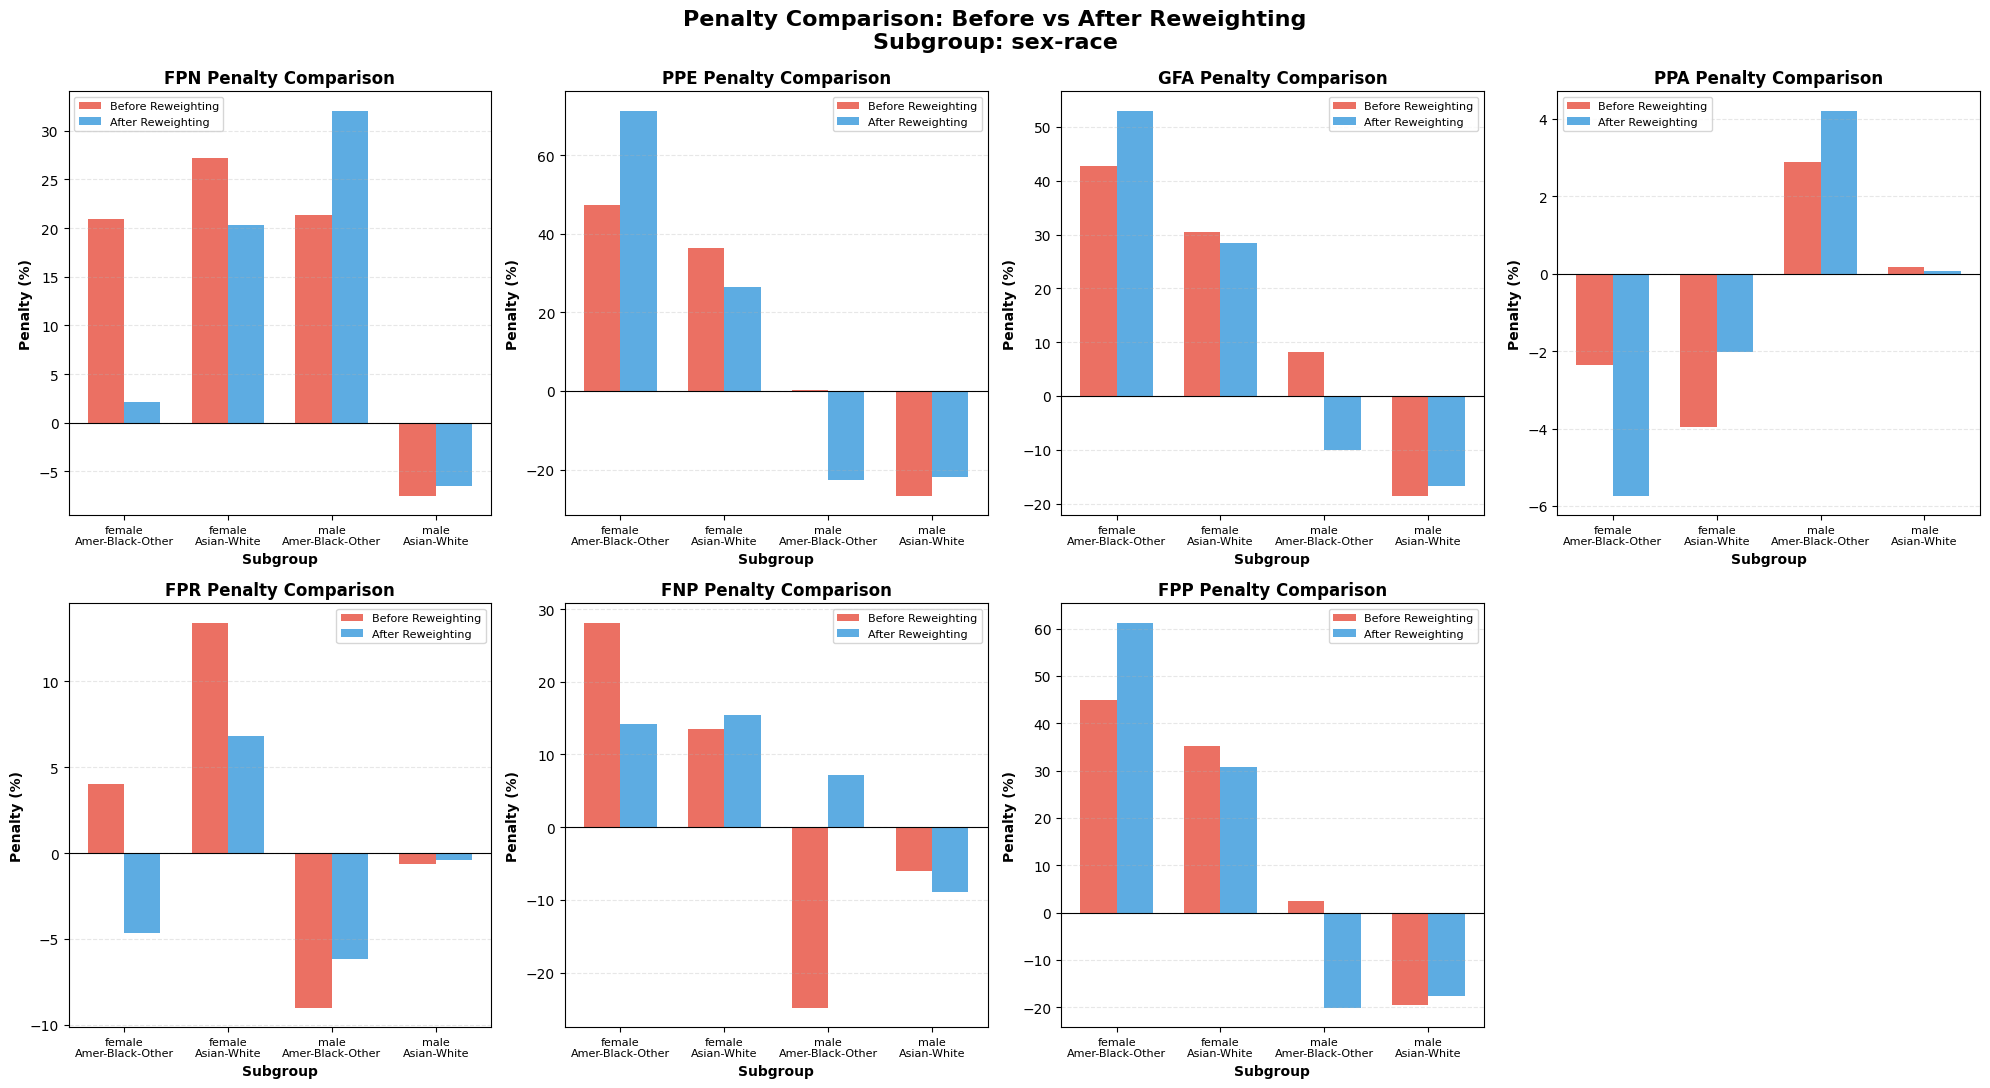

In [99]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

# Use the generalized function
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping)

In [100]:
"""

Unique weights per group: 
{'00': 0.18399168399168364, '01': 2.784338863750628, '10': 2.1301130811112654, '11': 0.16815239766806744}

"""

"\n\nUnique weights per group: \n{'00': 0.18399168399168364, '01': 2.784338863750628, '10': 2.1301130811112654, '11': 0.16815239766806744}\n\n"

In [101]:
penalties_ontest['FPN']

{'00': 20.953479430988082,
 '01': 27.21796937953264,
 '10': 21.38160007192489,
 '11': -7.506488160574622}

In [102]:
penalties_onval['FPN']

{'00': -48.4593837535014,
 '01': 33.34235548542337,
 '10': 59.5652688936271,
 '11': -8.134827845266178}

In [103]:
# Diagnostic analysis for FPN metric
metric = 'FPN'
individual_attrs = sensible_attribute.split('-')

print("="*80)
print(f"DIAGNOSTIC ANALYSIS: {metric} metric on {sensible_attribute}")
print("="*80)

# Get the weights
weights_notsized_fpn = compute_weights_notsized(10.0, metric)

# Get unique group weights
train_df = X_train[sensible_attribute].copy()
group_weight_map = {}
for i, (idx, row) in enumerate(train_df.iterrows()):
    group = row[sensible_attribute]
    group_weight_map[group] = weights_notsized_fpn[i]

print("\n1. WEIGHTS AND PENALTIES (Validation Set):")
print("-" * 80)
print(f"{'Subgroup':10s} | {'Weight':>8s} | {'Penalty Val':>12s} | {'Penalty Test Before':>20s} | {'Penalty Test After':>20s} | {'Δ Penalty':>12s}")
print("-" * 80)

for group in sorted(group_weight_map.keys()):
    weight = group_weight_map[group]
    penalty_val = penalties_onval[metric].get(group, 0)
    penalty_before = penalties_ontest[metric].get(group, 0)
    penalty_after = penalties_ontest_after_reweighting[metric].get(group, 0)
    delta = penalty_after - penalty_before
    
    # Decode
    decoded_parts = [mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))]
    decoded = '-'.join(decoded_parts)
    
    print(f"{group} ({decoded:15s}) | {weight:8.3f} | {penalty_val:12.2f} | {penalty_before:20.2f} | {penalty_after:20.2f} | {delta:+12.2f}")

print("\n2. CONFUSION MATRICES (Test Set - Before Reweighting):")
print("-" * 80)
print(f"{'Subgroup':20s} | {'TN':>5s} | {'FP':>5s} | {'FN':>5s} | {'TP':>5s} | {'FP/(FP+FN)':>12s} (FPN)")
print("-" * 80)

for group in sorted(cm_dict_test[sensible_attribute].keys()):
    cm = cm_dict_test[sensible_attribute][group]
    tn, fp = cm[0]
    fn, tp = cm[1]
    
    fpn_value = fp / (fp + fn) if (fp + fn) > 0 else 0
    
    decoded_parts = [mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))]
    decoded = '-'.join(decoded_parts)
    
    print(f"{group} ({decoded:15s}) | {tn:5d} | {fp:5d} | {fn:5d} | {tp:5d} | {fpn_value:12.4f}")

print("\n3. KEY INSIGHTS:")
print("-" * 80)
print("• High weight (>1.0) = Model focuses MORE on this group during training")
print("• Low weight (<1.0) = Model focuses LESS on this group during training")
print("• Penalty change depends on how model predictions shift across ALL groups")
print("• Small FP or FN counts make metrics unstable (high variance)")
print("\n⚠️  IMPORTANT: Weights affect MODEL LEARNING, not direct penalty reduction!")
print("   A high-weight group may not improve if:")
print("   - It's inherently difficult to classify correctly")
print("   - Improving it hurts other groups (zero-sum tradeoff)")
print("   - It has very small FP/FN counts (unstable metrics)")
print("="*80)

DIAGNOSTIC ANALYSIS: FPN metric on sex-race
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 4.3342355485423365, '10': 6.95652688936271, '11': 0.18651721547338218}

1. WEIGHTS AND PENALTIES (Validation Set):
--------------------------------------------------------------------------------
Subgroup   |   Weight |  Penalty Val |  Penalty Test Before |   Penalty Test After |    Δ Penalty
--------------------------------------------------------------------------------
00 (female-Amer-Black-Other) |    0.010 |       -48.46 |                20.95 |                 2.13 |       -18.82
01 (female-Asian-White) |    4.334 |        33.34 |                27.22 |                20.33 |        -6.88
10 (male-Amer-Black-Other) |    6.957 |        59.57 |                21.38 |                32.06 |       +10.68
11 (male-Asian-White) |    0.187 |        -8.13 |                -7.51 |                -6.49 |        +1.02

2. CONFUSION MATRICES (Test Set - Before Reweighting):
-----

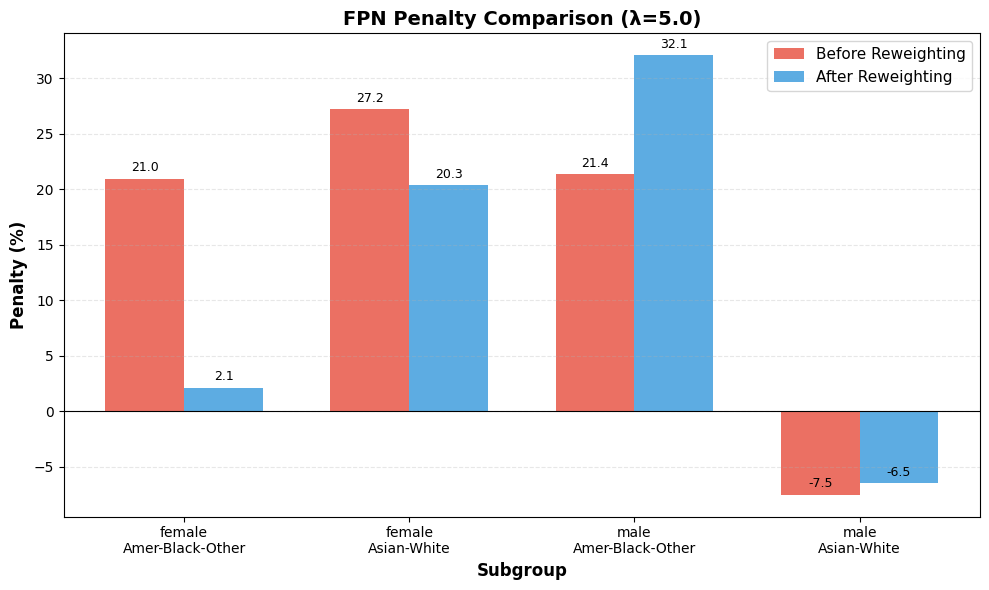


FPN - Penalty Changes:
  female-Amer-Black-Other: 20.95 → 2.13 (Δ = -18.82)
  female-Asian-White: 27.22 → 20.33 (Δ = -6.88)
  male-Amer-Black-Other: 21.38 → 32.06 (Δ = +10.68)
  male-Asian-White: -7.51 → -6.49 (Δ = +1.02)
------------------------------------------------------------


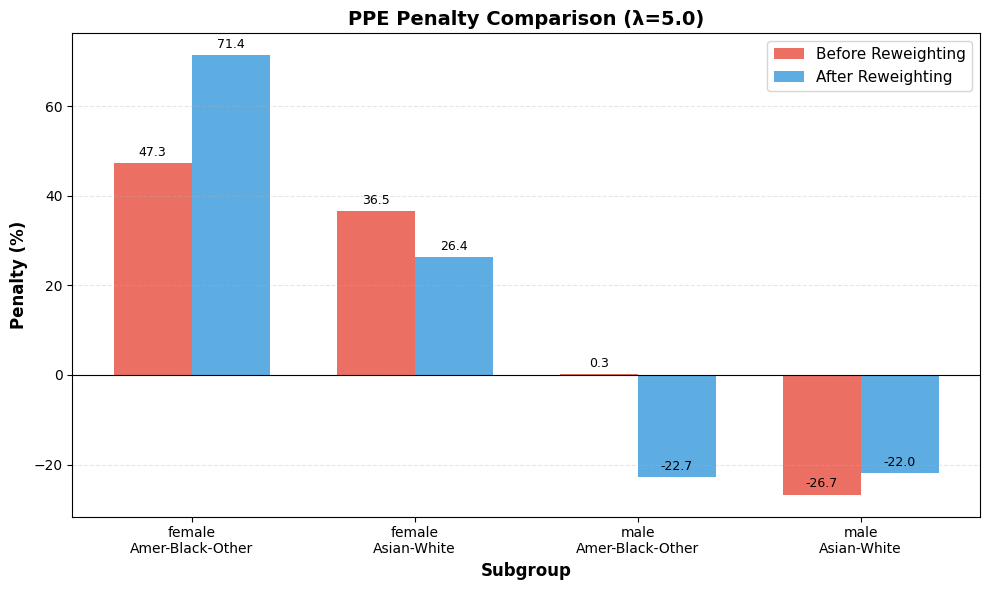


PPE - Penalty Changes:
  female-Amer-Black-Other: 47.35 → 71.38 (Δ = +24.03)
  female-Asian-White: 36.54 → 26.38 (Δ = -10.16)
  male-Amer-Black-Other: 0.25 → -22.73 (Δ = -22.98)
  male-Asian-White: -26.70 → -21.98 (Δ = +4.72)
------------------------------------------------------------


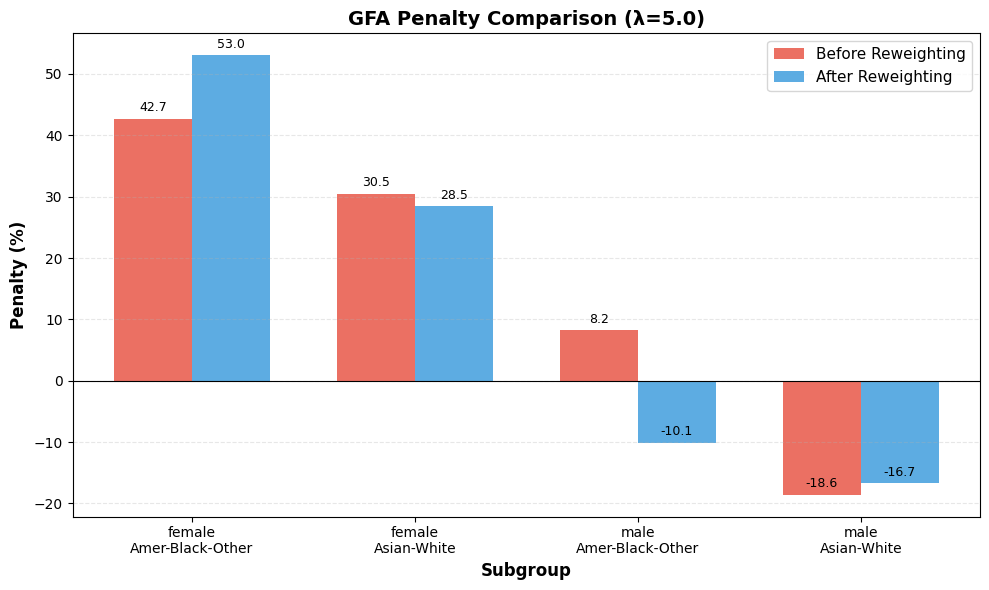


GFA - Penalty Changes:
  female-Amer-Black-Other: 42.71 → 53.04 (Δ = +10.33)
  female-Asian-White: 30.49 → 28.51 (Δ = -1.98)
  male-Amer-Black-Other: 8.25 → -10.08 (Δ = -18.33)
  male-Asian-White: -18.56 → -16.74 (Δ = +1.82)
------------------------------------------------------------


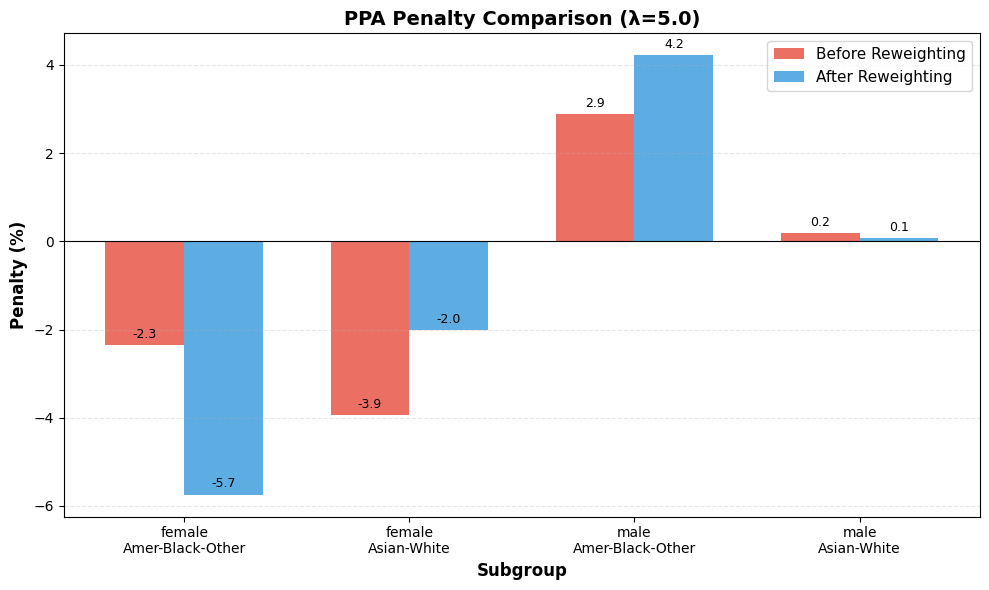


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.35 → -5.74 (Δ = -3.40)
  female-Asian-White: -3.95 → -2.02 (Δ = +1.93)
  male-Amer-Black-Other: 2.89 → 4.22 (Δ = +1.33)
  male-Asian-White: 0.18 → 0.07 (Δ = -0.11)
------------------------------------------------------------


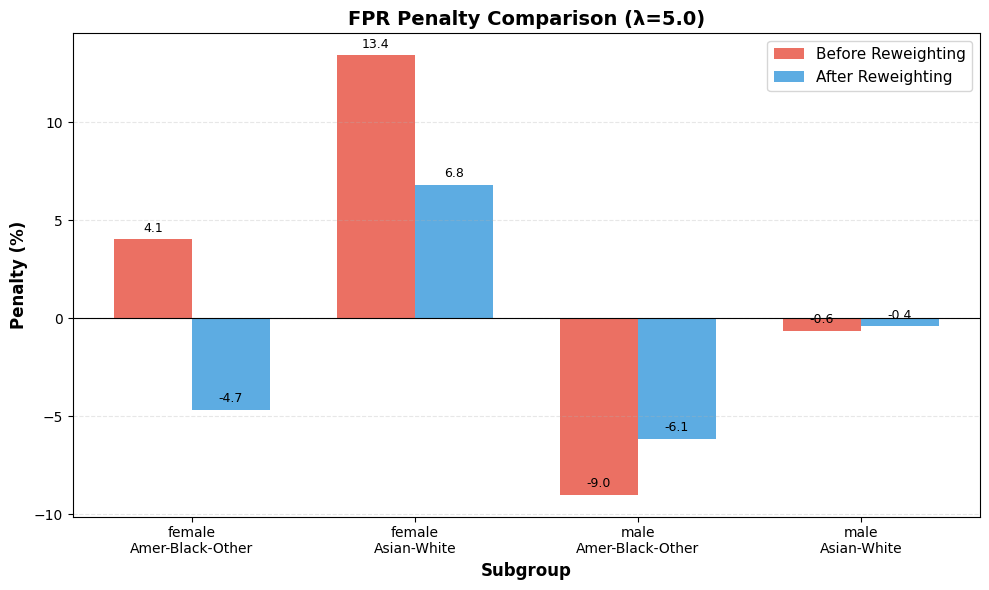


FPR - Penalty Changes:
  female-Amer-Black-Other: 4.05 → -4.67 (Δ = -8.72)
  female-Asian-White: 13.42 → 6.82 (Δ = -6.60)
  male-Amer-Black-Other: -9.00 → -6.15 (Δ = +2.86)
  male-Asian-White: -0.63 → -0.42 (Δ = +0.22)
------------------------------------------------------------


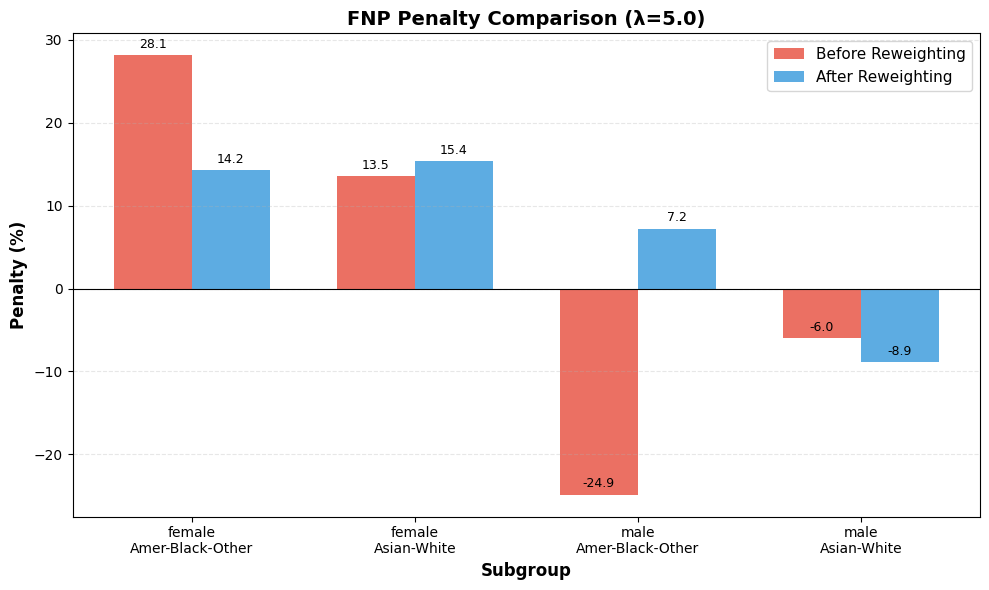


FNP - Penalty Changes:
  female-Amer-Black-Other: 28.14 → 14.24 (Δ = -13.90)
  female-Asian-White: 13.54 → 15.39 (Δ = +1.85)
  male-Amer-Black-Other: -24.85 → 7.23 (Δ = +32.08)
  male-Asian-White: -5.99 → -8.86 (Δ = -2.87)
------------------------------------------------------------


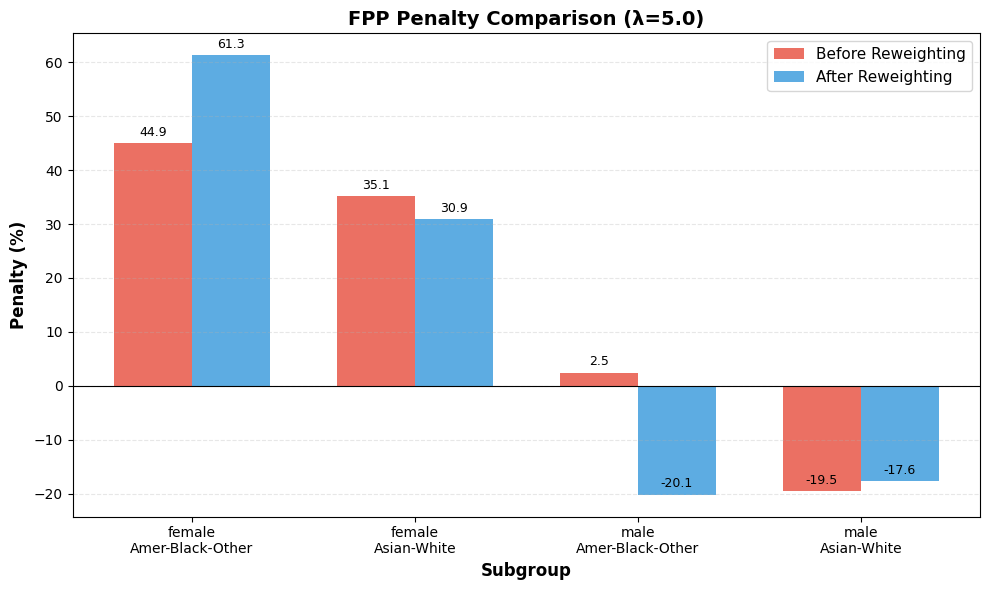


FPP - Penalty Changes:
  female-Amer-Black-Other: 44.93 → 61.26 (Δ = +16.33)
  female-Asian-White: 35.14 → 30.86 (Δ = -4.28)
  male-Amer-Black-Other: 2.48 → -20.13 (Δ = -22.60)
  male-Asian-White: -19.49 → -17.62 (Δ = +1.87)
------------------------------------------------------------


In [104]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        # Decode subgroup labels using mapping
        decoded_labels = []
        for group in subgroups:
            sex_code = group[0]
            race_code = group[1]
            sex_label = mapping['sex'][int(sex_code)]
            race_label = mapping['race'][int(race_code)]
            decoded_labels.append(f"{sex_label}\n{race_label}")
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison (λ=5.0)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping)

---

---

---

# Fixed Anchor Samples Approach (Professor's Method)

## Step 1: Analyze Subgroup Distribution

Before implementing the fixed anchor approach, we need to understand:
1. **How many samples per subgroup?**
2. **How many positive (y=1) vs negative (y=0) per subgroup?**
3. **Is each subgroup balanced enough to extract fixed anchor samples (e.g., 10 pos + 10 neg)?**

This analysis will help us:
- Identify which subgroups are problematic (small, imbalanced)
- Determine if the fixed anchor approach is feasible
- Choose the right number of anchor samples per subgroup

In [107]:
sensible_attribute = 'sex-race'

attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


In [108]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


sex
Precision: 0.7622682660850599, Recall: 0.5849372384937238, Accuracy: 0.8538083538083538, F1: 0.6619318181818182
{np.int64(0): array([[1451,   17],
       [  96,   85]]), np.int64(1): array([[2020,  201],
       [ 400,  614]])}
sex
Precision: 0.7685279187817259, Recall: 0.6276948590381426, Accuracy: 0.8614124872057318, F1: 0.6910086718393428
{np.int64(0): array([[1413,   17],
       [ 100,   80]]), np.int64(1): array([[2038,  211],
       [ 349,  677]])}
race
Precision: 0.7622682660850599, Recall: 0.5849372384937238, Accuracy: 0.8538083538083538, F1: 0.6619318181818182
{np.int64(1): array([[3000,  211],
       [ 456,  673]]), np.int64(0): array([[471,   7],
       [ 40,  26]])}
race
Precision: 0.7685279187817259, Recall: 0.6276948590381426, Accuracy: 0.8614124872057318, F1: 0.6910086718393428
{np.int64(1): array([[2966,  219],
       [ 399,  731]]), np.int64(0): array([[485,   9],
       [ 50,  26]])}
sex-race
Precision: 0.7622682660850599, Recall: 0.5849372384937238, Accuracy: 0.85

In [109]:
# Step 1: Analyze Subgroup Distribution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the full dataset
df_analysis = pd.read_csv(dataset_path)

# Create combined attribute column
individual_attrs = sensible_attribute.split('-')
df_analysis[sensible_attribute] = df_analysis[individual_attrs[0]].astype(str) + df_analysis[individual_attrs[1]].astype(str)

print("="*100)
print("SUBGROUP DISTRIBUTION ANALYSIS")
print("="*100)
print(f"\nDataset: {dataset_path}")
print(f"Total samples: {len(df_analysis)}")
print(f"Sensitive attribute: {sensible_attribute}")
print(f"Target variable: {target_variable}")

# Get all subgroups
subgroups = sorted(df_analysis[sensible_attribute].unique())

# Create summary table
print("\n" + "-"*100)
print(f"{'Subgroup':<12} | {'Decoded':<25} | {'Total':>8} | {'Pos (y=1)':>10} | {'Neg (y=0)':>10} | {'Pos Rate':>10} | {'Balanced?':>10}")
print("-"*100)

distribution_data = []

for group in subgroups:
    # Decode the group
    decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
    
    # Get counts
    group_data = df_analysis[df_analysis[sensible_attribute] == group]
    total = len(group_data)
    positive = (group_data[target_variable] == 1).sum()
    negative = (group_data[target_variable] == 0).sum()
    pos_rate = positive / total if total > 0 else 0
    
    # Determine if balanced (within 40-60% range for positive rate)
    balanced = "Yes" if 0.3 <= pos_rate <= 0.7 else "No"
    
    # Check if we can extract 10+10 anchor samples
    can_anchor_10 = "✓" if positive >= 10 and negative >= 10 else "✗"
    
    distribution_data.append({
        'group': group,
        'decoded': decoded,
        'total': total,
        'positive': positive,
        'negative': negative,
        'pos_rate': pos_rate,
        'balanced': balanced,
        'can_anchor_10': can_anchor_10
    })
    
    print(f"{group:<12} | {decoded:<25} | {total:>8} | {positive:>10} | {negative:>10} | {pos_rate:>9.1%} | {balanced:>10}")

print("-"*100)

# Summary statistics
print("\n" + "="*100)
print("FEASIBILITY CHECK: Can we extract anchor samples?")
print("="*100)

for n_anchor in [5, 10, 15, 20]:
    print(f"\n{n_anchor} positive + {n_anchor} negative per subgroup:")
    for d in distribution_data:
        can = "✓" if d['positive'] >= n_anchor and d['negative'] >= n_anchor else "✗"
        shortage_pos = max(0, n_anchor - d['positive'])
        shortage_neg = max(0, n_anchor - d['negative'])
        status = "OK" if can == "✓" else f"Need +{shortage_pos} pos, +{shortage_neg} neg"
        print(f"  {d['group']} ({d['decoded']:18s}): {can} {status}")

SUBGROUP DISTRIBUTION ANALYSIS

Dataset: AdultCensus/adult-preprocessed-2race-2age-2edu.csv
Total samples: 32561
Sensitive attribute: sex-race
Target variable: income

----------------------------------------------------------------------------------------------------
Subgroup     | Decoded                   |    Total |  Pos (y=1) |  Neg (y=0) |   Pos Rate |  Balanced?
----------------------------------------------------------------------------------------------------
00           | female-Amer-Black-Other   |     1783 |        108 |       1675 |      6.1% |         No
01           | female-Asian-White        |     8988 |       1071 |       7917 |     11.9% |         No
10           | male-Amer-Black-Other     |     1923 |        340 |       1583 |     17.7% |         No
11           | male-Asian-White          |    19867 |       6322 |      13545 |     31.8% |        Yes
----------------------------------------------------------------------------------------------------

FEASIBILITY 

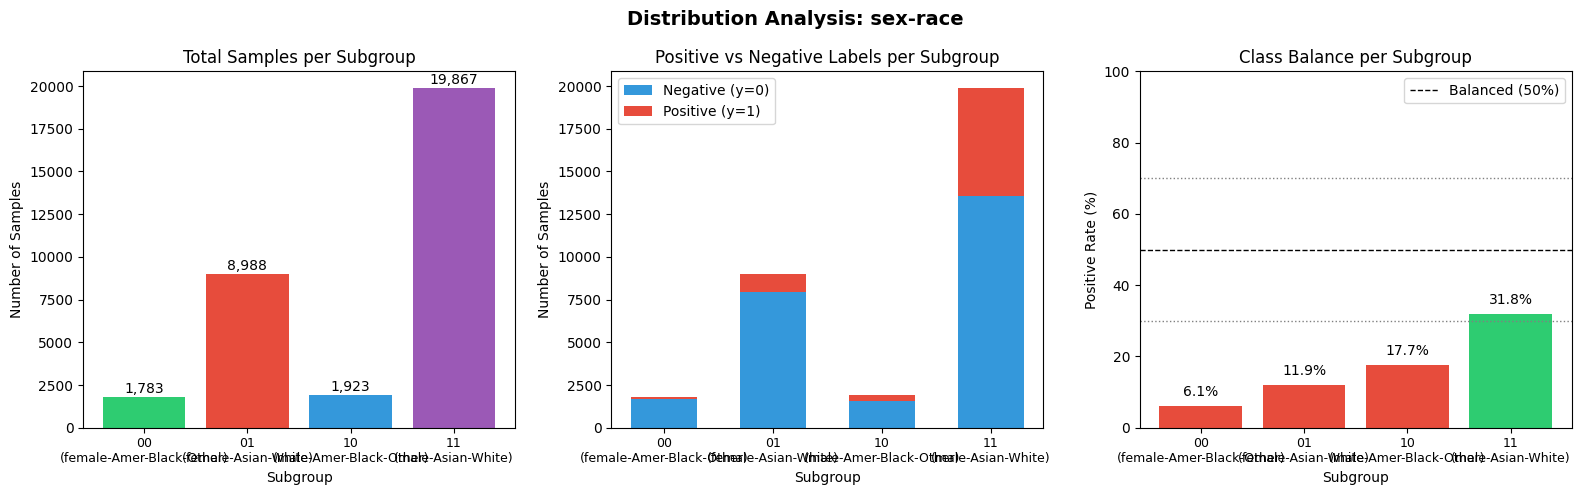

In [110]:
# Visualization: Subgroup Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total samples per subgroup
ax1 = axes[0]
groups = [d['group'] for d in distribution_data]
totals = [d['total'] for d in distribution_data]
decoded_labels = [d['decoded'] for d in distribution_data]

bars = ax1.bar(groups, totals, color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
ax1.set_xlabel('Subgroup')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Total Samples per Subgroup')
ax1.set_xticks(range(len(groups)))
ax1.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)

# Add value labels on bars
for bar, total in zip(bars, totals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{total:,}', ha='center', va='bottom', fontsize=10)

# Plot 2: Positive vs Negative per subgroup (stacked)
ax2 = axes[1]
positives = [d['positive'] for d in distribution_data]
negatives = [d['negative'] for d in distribution_data]

x = np.arange(len(groups))
width = 0.6

bars_neg = ax2.bar(x, negatives, width, label='Negative (y=0)', color='#3498db')
bars_pos = ax2.bar(x, positives, width, bottom=negatives, label='Positive (y=1)', color='#e74c3c')

ax2.set_xlabel('Subgroup')
ax2.set_ylabel('Number of Samples')
ax2.set_title('Positive vs Negative Labels per Subgroup')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
ax2.legend()

# Plot 3: Positive rate per subgroup
ax3 = axes[2]
pos_rates = [d['pos_rate'] * 100 for d in distribution_data]

bars = ax3.bar(groups, pos_rates, color=['#2ecc71' if 30 <= r <= 70 else '#e74c3c' for r in pos_rates])
ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, label='Balanced (50%)')
ax3.axhline(y=30, color='gray', linestyle=':', linewidth=1)
ax3.axhline(y=70, color='gray', linestyle=':', linewidth=1)
ax3.set_xlabel('Subgroup')
ax3.set_ylabel('Positive Rate (%)')
ax3.set_title('Class Balance per Subgroup')
ax3.set_xticks(range(len(groups)))
ax3.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
ax3.set_ylim(0, 100)
ax3.legend()

# Add value labels
for bar, rate in zip(bars, pos_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Distribution Analysis: {sensible_attribute}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [111]:
# Identify the most problematic subgroup (for professor's approach)
print("="*100)
print("IDENTIFYING MOST PROBLEMATIC SUBGROUP")
print("="*100)

# Calculate a "problem score" based on:
# 1. Small size (fewer samples = higher score)
# 2. Imbalance (further from 50% = higher score)
# 3. Low positive count (can't extract enough positive anchors)

max_total = max(d['total'] for d in distribution_data)

for d in distribution_data:
    # Size score: smaller = more problematic
    size_score = 1 - (d['total'] / max_total)
    
    # Imbalance score: further from 0.5 = more problematic
    imbalance_score = abs(d['pos_rate'] - 0.5) * 2  # Scale to 0-1
    
    # Minority class score: smaller minority = more problematic
    minority_count = min(d['positive'], d['negative'])
    minority_score = 1 - (minority_count / (d['total'] / 2)) if d['total'] > 0 else 1
    
    # Combined problem score
    problem_score = (size_score * 0.4) + (imbalance_score * 0.3) + (minority_score * 0.3)
    d['problem_score'] = problem_score
    d['minority_count'] = minority_count

# Sort by problem score
sorted_data = sorted(distribution_data, key=lambda x: x['problem_score'], reverse=True)

print("\nSubgroups ranked by 'problem score' (higher = more problematic):")
print("-"*100)
print(f"{'Rank':<6} | {'Subgroup':<12} | {'Decoded':<20} | {'Total':>8} | {'Minority':>10} | {'Pos Rate':>10} | {'Score':>8}")
print("-"*100)

for rank, d in enumerate(sorted_data, 1):
    print(f"{rank:<6} | {d['group']:<12} | {d['decoded']:<20} | {d['total']:>8} | {d['minority_count']:>10} | {d['pos_rate']:>9.1%} | {d['problem_score']:>7.3f}")

most_problematic = sorted_data[0]
print("\n" + "="*100)
print(f"MOST PROBLEMATIC SUBGROUP: {most_problematic['group']} ({most_problematic['decoded']})")
print("="*100)
print(f"  Total samples: {most_problematic['total']}")
print(f"  Positive (y=1): {most_problematic['positive']}")
print(f"  Negative (y=0): {most_problematic['negative']}")
print(f"  Positive rate: {most_problematic['pos_rate']:.1%}")
print(f"  Minority class count: {most_problematic['minority_count']}")

# Recommendation for anchor samples
max_anchor = most_problematic['minority_count'] // 2  # Leave some for training
print(f"\n  Recommended anchor samples: {min(max_anchor, 10)} positive + {min(max_anchor, 10)} negative")
print(f"  (Based on having {most_problematic['minority_count']} in minority class, keeping half for training)")

IDENTIFYING MOST PROBLEMATIC SUBGROUP

Subgroups ranked by 'problem score' (higher = more problematic):
----------------------------------------------------------------------------------------------------
Rank   | Subgroup     | Decoded              |    Total |   Minority |   Pos Rate |    Score
----------------------------------------------------------------------------------------------------
1      | 00           | female-Amer-Black-Other |     1783 |        108 |      6.1% |   0.891
2      | 10           | male-Amer-Black-Other |     1923 |        340 |     17.7% |   0.749
3      | 01           | female-Asian-White   |     8988 |       1071 |     11.9% |   0.676
4      | 11           | male-Asian-White     |    19867 |       6322 |     31.8% |   0.218

MOST PROBLEMATIC SUBGROUP: 00 (female-Amer-Black-Other)
  Total samples: 1783
  Positive (y=1): 108
  Negative (y=0): 1675
  Positive rate: 6.1%
  Minority class count: 108

  Recommended anchor samples: 10 positive + 10 negative
  

In [112]:
# Detailed view: Distribution within each split (train/val/test)
from sklearn.model_selection import train_test_split

print("="*100)
print("DISTRIBUTION ACROSS TRAIN/VAL/TEST SPLITS (Current Random Split)")
print("="*100)

# Use current split
Y = df_analysis[target_variable]
X = df_analysis.drop(target_variable, axis=1)

# Recreate the splits
X_train_temp, X_temp, y_train_temp, y_temp = train_test_split(X, Y, test_size=0.3, random_state=1)
X_val_temp, X_test_temp, y_val_temp, y_test_temp = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

splits = {
    'Train (70%)': (X_train_temp, y_train_temp),
    'Val (15%)': (X_val_temp, y_val_temp),
    'Test (15%)': (X_test_temp, y_test_temp)
}

# Analyze each split
for split_name, (X_split, y_split) in splits.items():
    print(f"\n{split_name}:")
    print("-"*90)
    print(f"  {'Subgroup':<12} | {'Decoded':<20} | {'Total':>8} | {'Pos':>8} | {'Neg':>8} | {'Pos Rate':>10}")
    print("  " + "-"*80)
    
    # Get sensitive attribute for this split
    sens_split = df_analysis[sensible_attribute].loc[X_split.index]
    
    for group in subgroups:
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        mask = sens_split == group
        total = mask.sum()
        positive = (y_split[mask] == 1).sum()
        negative = (y_split[mask] == 0).sum()
        pos_rate = positive / total if total > 0 else 0
        
        print(f"  {group:<12} | {decoded:<20} | {total:>8} | {positive:>8} | {negative:>8} | {pos_rate:>9.1%}")

print("\n" + "="*100)
print("KEY OBSERVATION: Check if any subgroup has 0 positives or 0 negatives in any split!")
print("="*100)

DISTRIBUTION ACROSS TRAIN/VAL/TEST SPLITS (Current Random Split)

Train (70%):
------------------------------------------------------------------------------------------
  Subgroup     | Decoded              |    Total |      Pos |      Neg |   Pos Rate
  --------------------------------------------------------------------------------
  00           | female-Amer-Black-Other |     1250 |       73 |     1177 |      5.8%
  01           | female-Asian-White   |     6262 |      745 |     5517 |     11.9%
  10           | male-Amer-Black-Other |     1342 |      233 |     1109 |     17.4%
  11           | male-Asian-White     |    13938 |     4389 |     9549 |     31.5%

Val (15%):
------------------------------------------------------------------------------------------
  Subgroup     | Decoded              |    Total |      Pos |      Neg |   Pos Rate
  --------------------------------------------------------------------------------
  00           | female-Amer-Black-Other |      246 |    

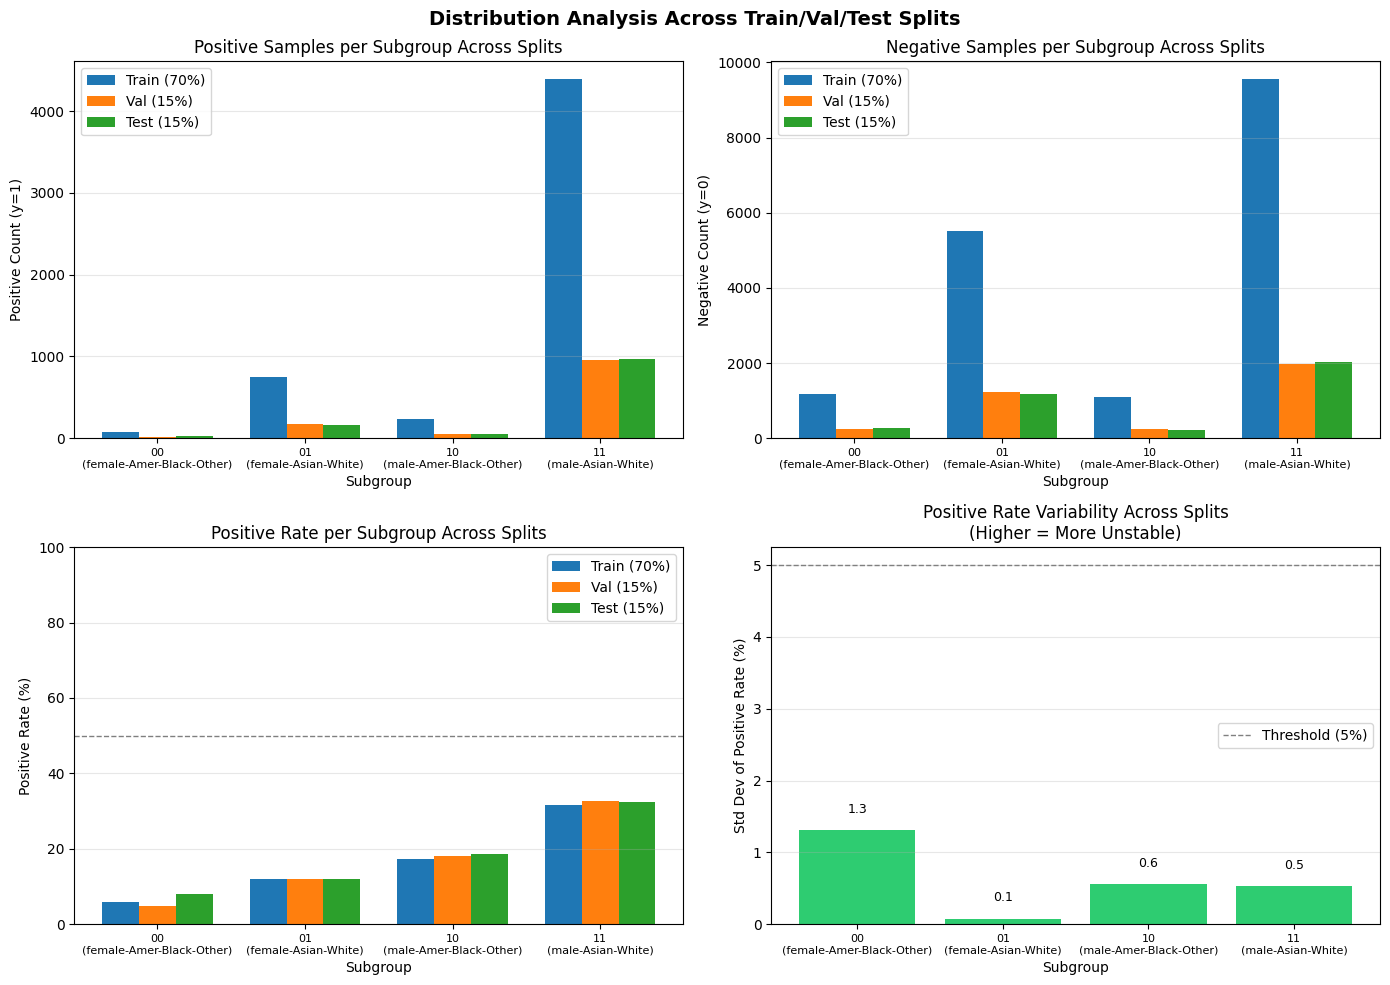


INTERPRETATION:
- High variance in positive rate suggests the split is unstable for that subgroup
- Subgroups with variance > 5% may benefit from fixed anchor samples
- Small subgroups tend to have higher variance due to random sampling effects


In [113]:
# Visualization: Compare distributions across splits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Collect data for all splits
split_data = {}
for split_name, (X_split, y_split) in splits.items():
    sens_split = df_analysis[sensible_attribute].loc[X_split.index]
    split_data[split_name] = {
        'pos': [],
        'neg': [],
        'pos_rate': []
    }
    for group in subgroups:
        mask = sens_split == group
        positive = (y_split[mask] == 1).sum()
        negative = (y_split[mask] == 0).sum()
        total = positive + negative
        split_data[split_name]['pos'].append(positive)
        split_data[split_name]['neg'].append(negative)
        split_data[split_name]['pos_rate'].append(positive / total * 100 if total > 0 else 0)

# Plot 1: Positive counts across splits
ax1 = axes[0, 0]
x = np.arange(len(subgroups))
width = 0.25
for i, (split_name, data) in enumerate(split_data.items()):
    ax1.bar(x + i*width, data['pos'], width, label=split_name)
ax1.set_xlabel('Subgroup')
ax1.set_ylabel('Positive Count (y=1)')
ax1.set_title('Positive Samples per Subgroup Across Splits')
ax1.set_xticks(x + width)
ax1.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Negative counts across splits
ax2 = axes[0, 1]
for i, (split_name, data) in enumerate(split_data.items()):
    ax2.bar(x + i*width, data['neg'], width, label=split_name)
ax2.set_xlabel('Subgroup')
ax2.set_ylabel('Negative Count (y=0)')
ax2.set_title('Negative Samples per Subgroup Across Splits')
ax2.set_xticks(x + width)
ax2.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Positive rate comparison across splits
ax3 = axes[1, 0]
for i, (split_name, data) in enumerate(split_data.items()):
    ax3.bar(x + i*width, data['pos_rate'], width, label=split_name)
ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Subgroup')
ax3.set_ylabel('Positive Rate (%)')
ax3.set_title('Positive Rate per Subgroup Across Splits')
ax3.set_xticks(x + width)
ax3.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 100)

# Plot 4: Variance in positive rate across splits (indicator of instability)
ax4 = axes[1, 1]
pos_rate_variance = []
for i, group in enumerate(subgroups):
    rates = [split_data[split]['pos_rate'][i] for split in split_data.keys()]
    variance = np.std(rates)
    pos_rate_variance.append(variance)

bars = ax4.bar(subgroups, pos_rate_variance, color=['#e74c3c' if v > 5 else '#2ecc71' for v in pos_rate_variance])
ax4.set_xlabel('Subgroup')
ax4.set_ylabel('Std Dev of Positive Rate (%)')
ax4.set_title('Positive Rate Variability Across Splits\n(Higher = More Unstable)')
ax4.set_xticks(range(len(subgroups)))
ax4.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax4.axhline(y=5, color='gray', linestyle='--', linewidth=1, label='Threshold (5%)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, var in zip(bars, pos_rate_variance):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{var:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution Analysis Across Train/Val/Test Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("INTERPRETATION:")
print("="*100)
print("- High variance in positive rate suggests the split is unstable for that subgroup")
print("- Subgroups with variance > 5% may benefit from fixed anchor samples")
print("- Small subgroups tend to have higher variance due to random sampling effects")

# K-Fold Cross-Validation for Penalty Estimation

**Goal**: Get more stable penalty estimates by averaging across 5 validation folds.

**Process**:
1. Combine Train + Val data (85% of total)
2. Split into 5 folds using StratifiedKFold (preserves class balance)
3. For each fold: train on 4 folds, validate on 1 fold, compute penalties
4. Average penalties across all 5 folds
5. Use averaged penalties to compute final weights
6. Train final model on ALL train+val data with weights → Predict on Test

**Test set (15%) remains completely separate!**

In [114]:
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

def compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5, verbose=True):
    """
    Compute penalties using K-Fold cross-validation for more stable estimates.
    
    Args:
        sensible_attribute: Combined attribute like 'sex-race'
        fair_metrics: List of fairness metrics to compute penalties for
        n_folds: Number of folds (default 5)
        verbose: Print progress
    
    Returns:
        penalties_kfold_avg: Dict of {metric: {subgroup: averaged_penalty}}
        penalties_per_fold: Dict of {metric: {subgroup: [penalties_per_fold]}}
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    if verbose:
        print("="*80)
        print(f"K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K={n_folds})")
        print("="*80)
        print(f"Train+Val samples: {len(X_trainval)}")
        print(f"Test samples (held out): {len(X_test[sensible_attribute])}")
    
    # Initialize storage for penalties per fold
    penalties_per_fold = {m: {g: [] for g in ['00', '01', '10', '11']} for m in fair_metrics}
    
    # Setup stratified K-fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Load dataframe once for fairness computation
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Split data for this fold
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        if verbose:
            # Show distribution in this fold's validation set
            val_dist = X_fold_val[sensible_attribute].value_counts().sort_index()
            print(f"  Val distribution: {val_dist.to_dict()}")
        
        # Convert to numeric for XGBoost
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        X_fold_val_num = X_fold_val.copy()
        X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes
        
        # Train model on this fold's training data
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # Predict on this fold's validation data
        y_pred_fold_val = model_fold.predict(X_fold_val_num)
        
        # Compute fairness metrics for each attribute
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            # Get sensible indexes for this fold's validation set
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
            
            # Compute confusion matrix
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
            )
            
            # Compute fairness metrics
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties for each metric
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            # Store penalty for each subgroup
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {}
    for m in fair_metrics:
        penalties_kfold_avg[m] = {}
        for group in ['00', '01', '10', '11']:
            fold_penalties = penalties_per_fold[m][group]
            penalties_kfold_avg[m][group] = np.mean(fold_penalties)
    
    if verbose:
        print("\n" + "="*80)
        print("AVERAGED PENALTIES (across 5 folds)")
        print("="*80)
        for m in fair_metrics[:3]:  # Show first 3 metrics
            print(f"\n{m}:")
            for group in ['00', '01', '10', '11']:
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                fold_vals = penalties_per_fold[m][group]
                print(f"  {group}: avg={avg:+.2f}%, std={std:.2f}, folds={[f'{v:.1f}' for v in fold_vals]}")
    
    return penalties_kfold_avg, penalties_per_fold

# Run K-fold penalty computation
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
penalties_kfold_avg, penalties_per_fold = compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5)

K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K=5)
Train+Val samples: 27676
Test samples (held out): 4885

--- Fold 1/5 ---
  Val distribution: {'00': 276, '01': 1619, '10': 300, '11': 3341}

--- Fold 2/5 ---
  Val distribution: {'00': 306, '01': 1472, '10': 341, '11': 3416}

--- Fold 3/5 ---
  Val distribution: {'00': 317, '01': 1545, '10': 361, '11': 3312}

--- Fold 4/5 ---
  Val distribution: {'00': 310, '01': 1500, '10': 339, '11': 3386}

--- Fold 5/5 ---
  Val distribution: {'00': 287, '01': 1529, '10': 299, '11': 3420}

AVERAGED PENALTIES (across 5 folds)

FPN:
  00: avg=+12.97%, std=55.40, folds=['48.3', '-17.0', '-7.2', '100.0', '-59.3']
  01: avg=+15.32%, std=8.68, folds=['17.4', '5.6', '7.7', '15.7', '30.1']
  10: avg=+16.93%, std=22.21, folds=['-11.1', '42.6', '31.5', '30.1', '-8.3']
  11: avg=-4.12%, std=0.90, folds=['-3.5', '-3.7', '-3.9', '-5.9', '-3.6']

PPE:
  00: avg=+57.54%, std=27.58, folds=['67.8', '59.6', '44.0', '100.0', '16.2']
  01: avg=+30.29%, std=6.66, fold

In [115]:
penalties_kfold_avg

{'FPN': {'00': np.float64(12.96581780792307),
  '01': np.float64(15.319003557070761),
  '10': np.float64(16.928243411662287),
  '11': np.float64(-4.119680886902444)},
 'PPE': {'00': np.float64(57.53794764942453),
  '01': np.float64(30.287422648312436),
  '10': np.float64(0.92538570310696),
  '11': np.float64(-25.03802470905868)},
 'GFA': {'00': np.float64(54.372086384881584),
  '01': np.float64(25.46729960565417),
  '10': np.float64(5.270138173465244),
  '11': np.float64(-16.950362529475616)},
 'PPA': {'00': np.float64(0.07770088400096994),
  '01': np.float64(-2.687393539892148),
  '10': np.float64(-2.283517791609239),
  '11': np.float64(0.3562294482808884)},
 'OAE': {'00': np.float64(-3.949372782146431),
  '01': np.float64(-4.439854717642117),
  '10': np.float64(-1.688285251530227),
  '11': np.float64(2.529049855709195)},
 'FPR': {'00': np.float64(2.631939113518064),
  '01': np.float64(7.43488195680141),
  '10': np.float64(3.507458753709339),
  '11': np.float64(-0.9415819749857164)},


In [116]:
# Compare: Single-split penalties vs K-fold averaged penalties
print("="*100)
print("COMPARISON: Single-Split vs K-Fold Averaged Penalties")
print("="*100)

individual_attrs = sensible_attribute.split('-')

for m in fair_metrics[:5]:  # Show first 5 metrics
    print(f"\n{m}:")
    print(f"  {'Group':<25} | {'Single-Split':>12} | {'K-Fold Avg':>12} | {'K-Fold Std':>12} | {'Difference':>12}")
    print("  " + "-"*85)
    
    for group in ['00', '01', '10', '11']:
        # Decode group name
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        single_val = penalties_onval[m].get(group, 0)
        kfold_avg = penalties_kfold_avg[m][group]
        kfold_std = np.std(penalties_per_fold[m][group])
        diff = kfold_avg - single_val
        
        print(f"  {group} ({decoded:18s}) | {single_val:+12.2f} | {kfold_avg:+12.2f} | {kfold_std:12.2f} | {diff:+12.2f}")

print("\n" + "="*100)
print("NOTE: Lower std = more stable penalty estimate")
print("      Large difference = single-split was noisy")
print("="*100)

COMPARISON: Single-Split vs K-Fold Averaged Penalties

FPN:
  Group                     | Single-Split |   K-Fold Avg |   K-Fold Std |   Difference
  -------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |       -48.46 |       +12.97 |        55.40 |       +61.43
  01 (female-Asian-White) |       +33.34 |       +15.32 |         8.68 |       -18.02
  10 (male-Amer-Black-Other) |       +59.57 |       +16.93 |        22.21 |       -42.64
  11 (male-Asian-White  ) |        -8.13 |        -4.12 |         0.90 |        +4.02

PPE:
  Group                     | Single-Split |   K-Fold Avg |   K-Fold Std |   Difference
  -------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |       +33.92 |       +57.54 |        27.58 |       +23.62
  01 (female-Asian-White) |       +42.38 |       +30.29 |         6.66 |       -12.10
  10 (male-Amer-Black-Other) |       +51.23 |        

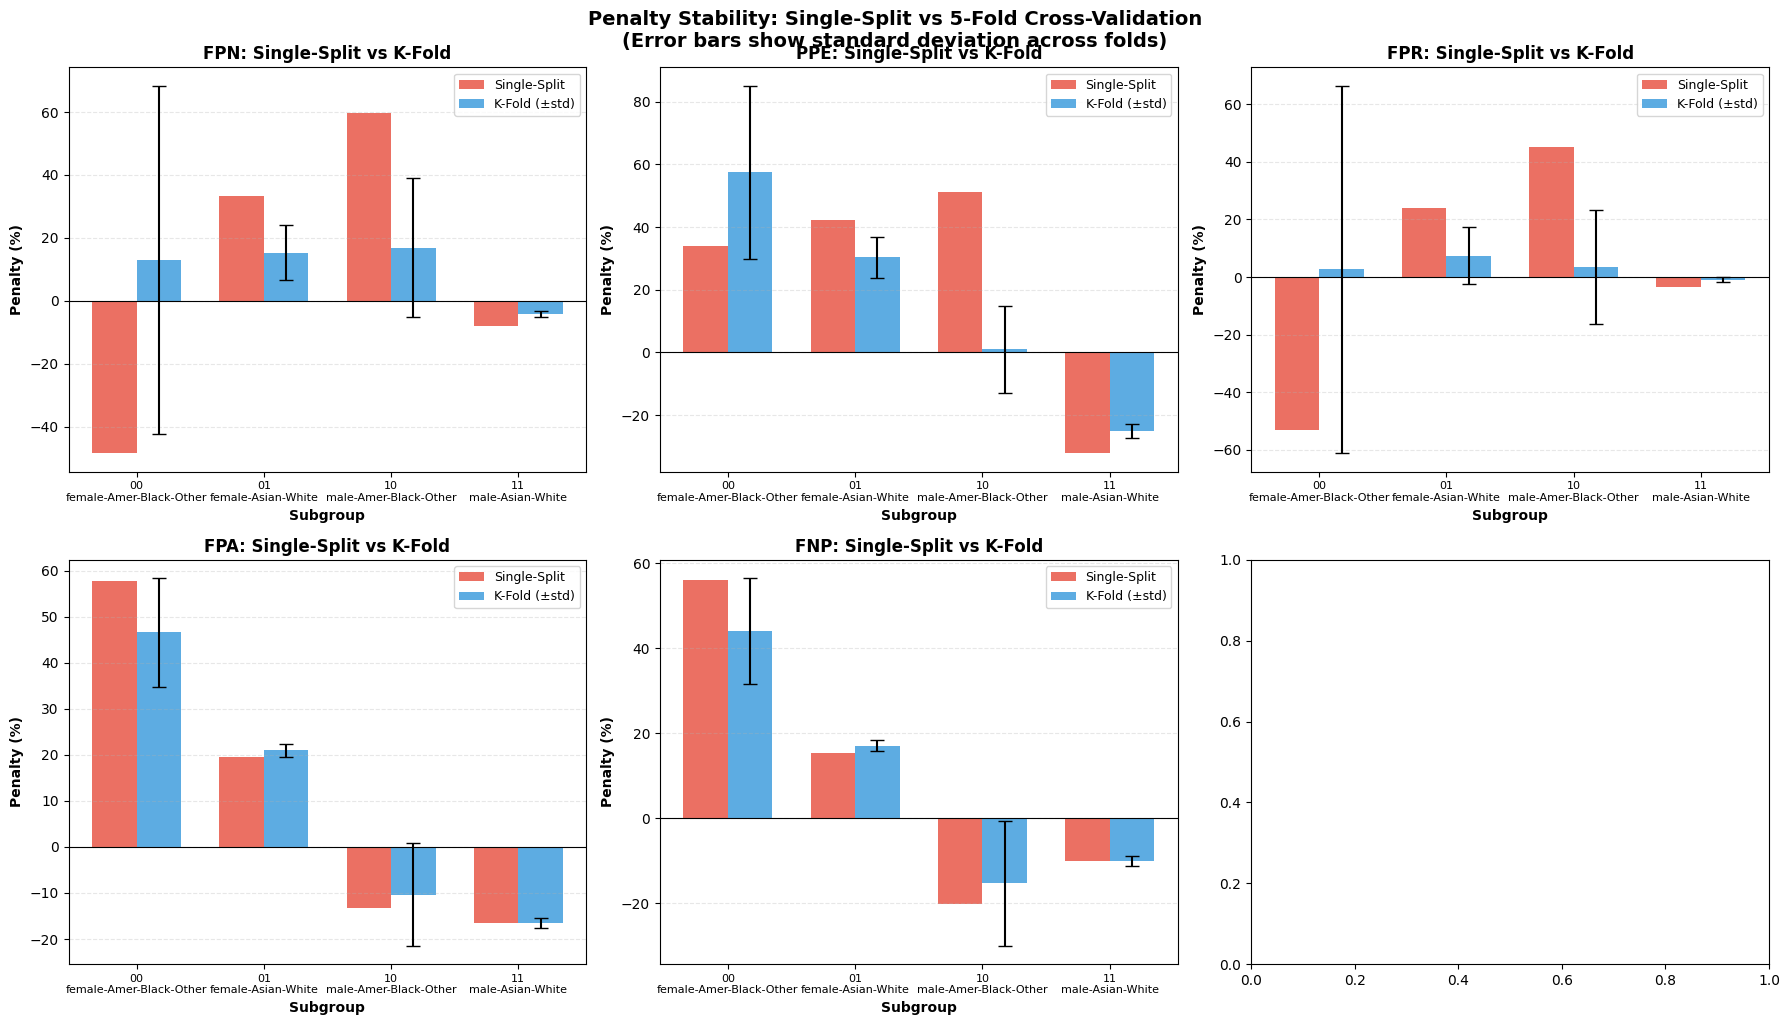

In [117]:
# Visualize penalty stability: K-fold variance by subgroup
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

individual_attrs = sensible_attribute.split('-')
metrics_to_plot = ['FPN', 'PPE', 'FPR', 'FPA', 'FNP']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    groups = ['00', '01', '10', '11']
    x = np.arange(len(groups))
    
    # Get data for this metric
    single_vals = [penalties_onval[metric].get(g, 0) for g in groups]
    kfold_avgs = [penalties_kfold_avg[metric][g] for g in groups]
    kfold_stds = [np.std(penalties_per_fold[metric][g]) for g in groups]
    
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, single_vals, width, label='Single-Split', alpha=0.8, color='#e74c3c')
    bars2 = ax.bar(x + width/2, kfold_avgs, width, yerr=kfold_stds, capsize=5, 
                   label='K-Fold (±std)', alpha=0.8, color='#3498db')
    
    # Decode labels
    decoded_labels = ['-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))]) 
                      for g in groups]
    
    ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
    ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
    ax.set_title(f'{metric}: Single-Split vs K-Fold', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n{l}" for g, l in zip(groups, decoded_labels)], fontsize=8)
    ax.legend(fontsize=9)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.suptitle('Penalty Stability: Single-Split vs 5-Fold Cross-Validation\n(Error bars show standard deviation across folds)', 
            fontsize=14, fontweight='bold', y=1.02)
plt.show()

## Compute Weights Using K-Fold Averaged Penalties

Now we use the more stable K-fold averaged penalties to compute weights, train the final model, and compare with the single-split approach.

In [118]:
def compute_weights_kfold(lambda_=5.0, m='PPE'):
    """
    Compute weights using K-fold averaged penalties instead of single-split penalties.
    """
    # Combine train + val for final training
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    weights_for_training = np.ones(len(X_trainval))
    
    # Use K-fold averaged penalties
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_kfold_avg[m].items()
    }
    
    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(X_trainval.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    print(f"Training samples: {len(weights_for_training)}, Weights per group (K-fold): {group_weights}")
    
    return weights_for_training, X_trainval, y_trainval

# Compute weights using K-fold penalties
weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, 'PPE')

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.8768973824712263), '01': np.float64(2.5143711324156217), '10': np.float64(1.046269285155348), '11': 0.01}


In [119]:
def compute_penalties_after_reweighting_kfold(weights, X_trainval, y_trainval, fairness_metric='PPE'):
    """
    Train model on FULL train+val data with K-fold weights, evaluate on test set.
    """
    # Convert to numeric for XGBoost
    X_trainval_num = X_trainval.copy()
    X_trainval_num[sensible_attribute] = X_trainval_num[sensible_attribute].astype('category').cat.codes
    
    X_test_num = X_test[sensible_attribute].copy()
    X_test_num[sensible_attribute] = X_test_num[sensible_attribute].astype('category').cat.codes
    
    # Train model on full train+val with weights
    model_kfold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_kfold.fit(X_trainval_num, y_trainval, sample_weight=weights)
    
    # Predict on test set
    y_pred_test_kfold = model_kfold.predict(X_test_num)
    
    # Compute fairness metrics
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    df_fresh = pd.read_csv(dataset_path)
    
    fairness_metrics_kfold = {}
    
    for attribute in attributes:
        df_attr = df_fresh.copy()
        
        if '-' in attribute:
            indiv_attrs = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str),
                [df_attr[col] for col in indiv_attrs]
            )
        
        sensible_indexes_attr = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
        
        cm_dict_attr = compute_cm_group(
            df_attr, attribute, sensible_indexes_attr,
            y_pred_test_kfold, y_test[sensible_attribute], X_test[sensible_attribute],
            target_variable_labels
        )
        
        fairness_metrics_kfold[attribute] = {}
        for m in fair_metrics:
            fairness_metrics_kfold[attribute][m], _ = compute_fairness_metrics_and_counts(
                cm_dict_attr, m, attribute, mapping, dataset_path
            )
    
    # Compute penalties
    harmonic, _, _ = compute_penalty_2(
        fairness_metrics_kfold, df_fresh,
        individual_attrs[0], individual_attrs[1],
        fairness_metric
    )
    
    return harmonic

# Compute penalties on test set after K-fold reweighting
penalties_ontest_after_kfold = {}
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, metric)
    penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(
        weights_kfold, X_trainval, y_trainval, metric
    )
    
print("\nPenalties after K-fold reweighting computed for all metrics.")

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.6482908903961535), '01': np.float64(1.7659501778535382), '10': np.float64(1.8464121705831142), '11': np.float64(0.7940159556548778)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.8768973824712263), '01': np.float64(2.5143711324156217), '10': np.float64(1.046269285155348), '11': 0.01}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.718604319244079), '01': np.float64(2.2733649802827083), '10': np.float64(1.2635069086732622), '11': np.float64(0.15248187352621922)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.0038850442000484), '01': np.float64(0.8656303230053926), '10': np.float64(0.8858241104195381), '11': np.float64(1.0178114724140443)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(0.8025313608926784), '01': np.float64(0.7780072641178941), '10': np.float64(0.9155857374234886), '11': np.float64(1.1264524927854598

In [120]:
# Final Comparison: Single-Split vs K-Fold Reweighting
print("="*120)
print("FINAL COMPARISON: Single-Split Reweighting vs K-Fold Reweighting")
print("="*120)
print("\nPenalties on TEST SET after reweighting:")
print("-"*120)

individual_attrs = sensible_attribute.split('-')

for m in fair_metrics[:5]:
    print(f"\n{m}:")
    print(f"  {'Group':<25} | {'Before':>10} | {'After (Single)':>15} | {'After (K-Fold)':>15} | {'Δ Single':>12} | {'Δ K-Fold':>12}")
    print("  " + "-"*105)
    
    for group in ['00', '01', '10', '11']:
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        before = penalties_ontest[m].get(group, 0)
        after_single = penalties_ontest_after_reweighting[m].get(group, 0)
        after_kfold = penalties_ontest_after_kfold[m].get(group, 0)
        delta_single = after_single - before
        delta_kfold = after_kfold - before
        
        print(f"  {group} ({decoded:18s}) | {before:+10.2f} | {after_single:+15.2f} | {after_kfold:+15.2f} | {delta_single:+12.2f} | {delta_kfold:+12.2f}")

print("\n" + "="*120)
print("LEGEND:")
print("  Before = Penalty on test set (baseline model, no reweighting)")
print("  After (Single) = Penalty after reweighting using single-split validation penalties")
print("  After (K-Fold) = Penalty after reweighting using 5-fold averaged penalties")
print("  Δ = Change in penalty (negative = improvement, positive = worsening)")
print("="*120)

FINAL COMPARISON: Single-Split Reweighting vs K-Fold Reweighting

Penalties on TEST SET after reweighting:
------------------------------------------------------------------------------------------------------------------------

FPN:
  Group                     |     Before |  After (Single) |  After (K-Fold) |     Δ Single |     Δ K-Fold
  ---------------------------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |     +20.95 |           +2.13 |          +28.19 |       -18.82 |        +7.24
  01 (female-Asian-White) |     +27.22 |          +20.33 |          +16.71 |        -6.88 |       -10.51
  10 (male-Amer-Black-Other) |     +21.38 |          +32.06 |          +26.46 |       +10.68 |        +5.08
  11 (male-Asian-White  ) |      -7.51 |           -6.49 |           -6.04 |        +1.02 |        +1.46

PPE:
  Group                     |     Before |  After (Single) |  After (K-Fold) |     Δ Single |     Δ K-Fold
  --------

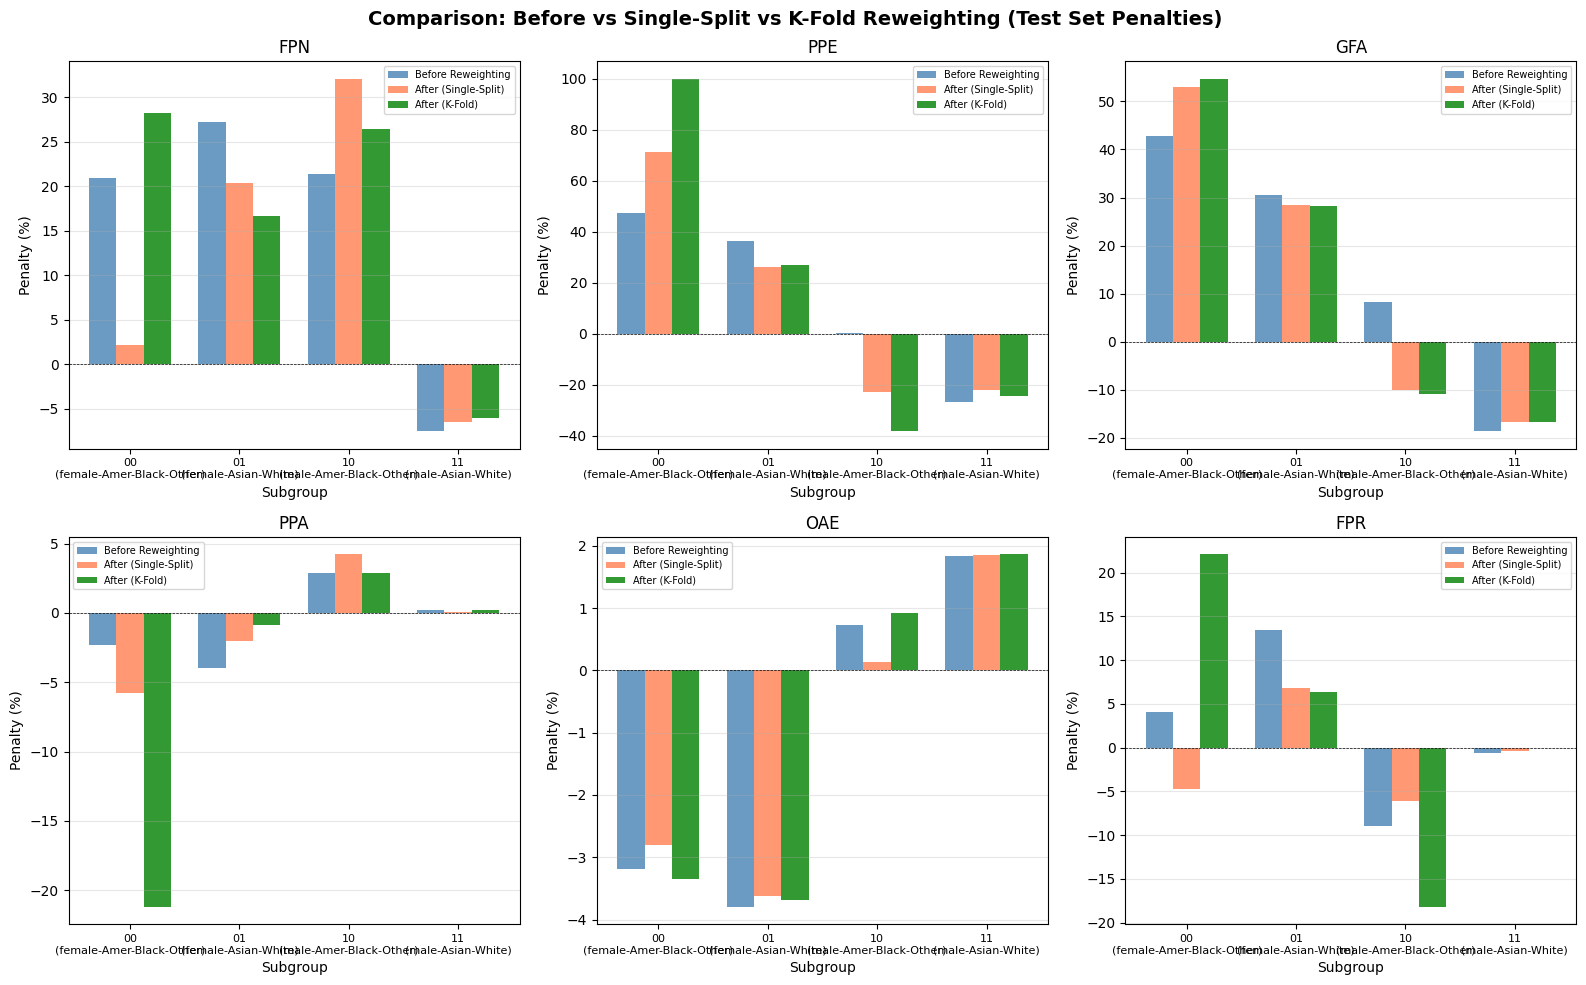


SUMMARY: Average Absolute Penalty Change by Approach
FPN: Before = 19.26 | Single-Split = 15.25 | K-Fold = 19.35
PPE: Before = 27.71 | Single-Split = 35.62 | K-Fold = 47.42
GFA: Before = 25.00 | Single-Split = 27.09 | K-Fold = 27.63
PPA: Before = 2.34 | Single-Split = 3.01 | K-Fold = 6.28
OAE: Before = 2.39 | Single-Split = 2.10 | K-Fold = 2.45
FPR: Before = 6.78 | Single-Split = 4.51 | K-Fold = 11.64


In [121]:
# Visualization: Single-Split vs K-Fold Reweighting Effects
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

individual_attrs = sensible_attribute.split('-')

for idx, m in enumerate(fair_metrics[:6]):
    ax = axes[idx]
    
    groups = ['00', '01', '10', '11']
    x = np.arange(len(groups))
    width = 0.25
    
    before_vals = [penalties_ontest[m].get(g, 0) for g in groups]
    after_single = [penalties_ontest_after_reweighting[m].get(g, 0) for g in groups]
    after_kfold = [penalties_ontest_after_kfold[m].get(g, 0) for g in groups]
    
    bars1 = ax.bar(x - width, before_vals, width, label='Before Reweighting', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x, after_single, width, label='After (Single-Split)', color='coral', alpha=0.8)
    bars3 = ax.bar(x + width, after_kfold, width, label='After (K-Fold)', color='green', alpha=0.8)
    
    # Decode group labels
    labels = [f"{g}\n({'-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))])})" 
              for g in groups]
    
    ax.set_xlabel('Subgroup')
    ax.set_ylabel('Penalty (%)')
    ax.set_title(f'{m}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparison: Before vs Single-Split vs K-Fold Reweighting (Test Set Penalties)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY: Average Absolute Penalty Change by Approach")
print("="*80)

for m in fair_metrics[:6]:
    before_vals = np.array([abs(penalties_ontest[m].get(g, 0)) for g in groups])
    after_single = np.array([abs(penalties_ontest_after_reweighting[m].get(g, 0)) for g in groups])
    after_kfold = np.array([abs(penalties_ontest_after_kfold[m].get(g, 0)) for g in groups])
    
    print(f"{m}: Before = {before_vals.mean():.2f} | Single-Split = {after_single.mean():.2f} | K-Fold = {after_kfold.mean():.2f}")

## Distribution Analysis: Validation vs Test Sets

**The Problem**: Penalties from validation set differ significantly from test set penalties.

**Hypothesis**: The validation and test sets have different subgroup distributions (class balance per subgroup), causing different penalty values even though both come from the same original data.

**Why this matters**: Weights are computed from validation penalties but applied to predict on test set. If distributions differ, the weights won't correctly address the discrimination patterns present in the test set.

Let's diagnose this by comparing:
1. Subgroup sizes in val vs test
2. Positive class rates per subgroup (y=1 rate)
3. Label-subgroup joint distributions

In [122]:
# Diagnose Distribution Differences: Validation vs Test
from scipy.stats import chi2_contingency, entropy
import numpy as np
import pandas as pd

def analyze_distribution_mismatch(sensible_attr, X_val, y_val, X_test, y_test, sensible_indexes_val, sensible_indexes_test, mapping):
    """
    Compare distributions between validation and test sets.
    """
    individual_attrs = sensible_attr.split('-')
    
    print("="*100)
    print("DISTRIBUTION ANALYSIS: VALIDATION vs TEST SET")
    print("="*100)
    
    # 1. Subgroup sizes
    val_groups = sensible_indexes_val.value_counts().sort_index()
    test_groups = sensible_indexes_test.value_counts().sort_index()
    
    print("\n1. SUBGROUP SIZES")
    print("-"*80)
    print(f"{'Group':<30} | {'Val Size':>10} | {'Val %':>8} | {'Test Size':>10} | {'Test %':>8} | {'Diff %':>8}")
    print("-"*80)
    
    for group in sorted(val_groups.index):
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        val_size = val_groups.get(group, 0)
        test_size = test_groups.get(group, 0)
        val_pct = val_size / len(sensible_indexes_val) * 100
        test_pct = test_size / len(sensible_indexes_test) * 100
        diff_pct = val_pct - test_pct
        print(f"{group} ({decoded:18s}) | {val_size:>10} | {val_pct:>7.1f}% | {test_size:>10} | {test_pct:>7.1f}% | {diff_pct:>+7.1f}%")
    
    # 2. Positive class rate (y=1) per subgroup
    print("\n2. POSITIVE CLASS RATE (y=1) PER SUBGROUP")
    print("-"*80)
    print(f"{'Group':<30} | {'Val y=1 Rate':>12} | {'Test y=1 Rate':>13} | {'Difference':>12}")
    print("-"*80)
    
    y_val_series = y_val[sensible_attr] if isinstance(y_val, dict) else y_val
    y_test_series = y_test[sensible_attr] if isinstance(y_test, dict) else y_test
    
    for group in sorted(val_groups.index):
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        val_mask = sensible_indexes_val == group
        test_mask = sensible_indexes_test == group
        
        val_rate = y_val_series[val_mask].mean() if val_mask.sum() > 0 else 0
        test_rate = y_test_series[test_mask].mean() if test_mask.sum() > 0 else 0
        diff = val_rate - test_rate
        
        print(f"{group} ({decoded:18s}) | {val_rate:>11.1%} | {test_rate:>12.1%} | {diff:>+11.1%}")
    
    # 3. Jensen-Shannon Divergence between val and test distributions
    print("\n3. DISTRIBUTION DIVERGENCE METRICS")
    print("-"*80)
    
    # For subgroup distribution
    all_groups = sorted(set(val_groups.index) | set(test_groups.index))
    val_dist = np.array([val_groups.get(g, 0) for g in all_groups]) / len(sensible_indexes_val)
    test_dist = np.array([test_groups.get(g, 0) for g in all_groups]) / len(sensible_indexes_test)
    
    # Add small epsilon to avoid log(0)
    eps = 1e-10
    val_dist = val_dist + eps
    test_dist = test_dist + eps
    val_dist = val_dist / val_dist.sum()
    test_dist = test_dist / test_dist.sum()
    
    # Jensen-Shannon Divergence
    m = (val_dist + test_dist) / 2
    jsd = 0.5 * entropy(val_dist, m) + 0.5 * entropy(test_dist, m)
    
    print(f"Jensen-Shannon Divergence (subgroup distribution): {jsd:.6f}")
    print(f"  (0 = identical distributions, 1 = completely different)")
    
    # 4. Joint distribution (subgroup × label)
    print("\n4. JOINT DISTRIBUTION (Subgroup × Label)")
    print("-"*80)
    
    joint_val = {}
    joint_test = {}
    
    for group in all_groups:
        val_mask = sensible_indexes_val == group
        test_mask = sensible_indexes_test == group
        
        for label in [0, 1]:
            key = f"{group}_y{label}"
            joint_val[key] = ((val_mask) & (y_val_series == label)).sum() / len(y_val_series)
            joint_test[key] = ((test_mask) & (y_test_series == label)).sum() / len(y_test_series)
    
    print(f"{'Group-Label':<20} | {'Val Joint %':>12} | {'Test Joint %':>13} | {'Difference':>12}")
    print("-"*80)
    for key in sorted(joint_val.keys()):
        diff = joint_val[key] - joint_test[key]
        print(f"{key:<20} | {joint_val[key]:>11.2%} | {joint_test[key]:>12.2%} | {diff:>+11.2%}")
    
    return {
        'jsd': jsd,
        'val_dist': val_dist,
        'test_dist': test_dist
    }

# Run the analysis
dist_analysis = analyze_distribution_mismatch(
    sensible_attribute, 
    X_val, y_val, 
    X_test, y_test,
    sensible_indexes_val, sensible_indexes_test,
    mapping
)

DISTRIBUTION ANALYSIS: VALIDATION vs TEST SET

1. SUBGROUP SIZES
--------------------------------------------------------------------------------
Group                          |   Val Size |    Val % |  Test Size |   Test % |   Diff %
--------------------------------------------------------------------------------
00 (female-Amer-Black-Other) |        246 |     5.0% |        287 |     5.9% |    -0.8%
01 (female-Asian-White) |       1403 |    28.7% |       1323 |    27.1% |    +1.6%
10 (male-Amer-Black-Other) |        298 |     6.1% |        283 |     5.8% |    +0.3%
11 (male-Asian-White  ) |       2937 |    60.1% |       2992 |    61.2% |    -1.1%

2. POSITIVE CLASS RATE (y=1) PER SUBGROUP
--------------------------------------------------------------------------------
Group                          | Val y=1 Rate | Test y=1 Rate |   Difference
--------------------------------------------------------------------------------
00 (female-Amer-Black-Other) |        4.9% |         8.0% |  

In [123]:
penalties_ontest_after_reweighting = {}
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.6671177742711683, '10': 3.978263444681355, '11': 0.593258607736691}
Training samples: 22792, Unique weights per group: {'00': 2.695755225166989, '01': 3.119138352568861, '10': 3.561409871019609, '11': 0.01}
Training samples: 22792, Unique weights per group: {'00': 3.6772296132052227, '01': 2.469779259913846, '10': 1.8817100057269693, '11': 0.014273652257749458}
Training samples: 22792, Unique weights per group: {'00': 1.590659340659341, '01': 0.6520818184692223, '10': 0.31995427211225247, '11': 1.056680291854272}
Training samples: 22792, Unique weights per group: {'00': 0.7779672589014786, '01': 0.775994164753704, '10': 0.8946541791709225, '11': 1.136573013896529}
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.206009882020772, '10': 3.2596837242359626, '11': 0.8212889338791235}
Training samples: 22792, Unique weights per group: {'00': 3.8846539400278943, '01': 1.9726427951563403, '10': 0.33

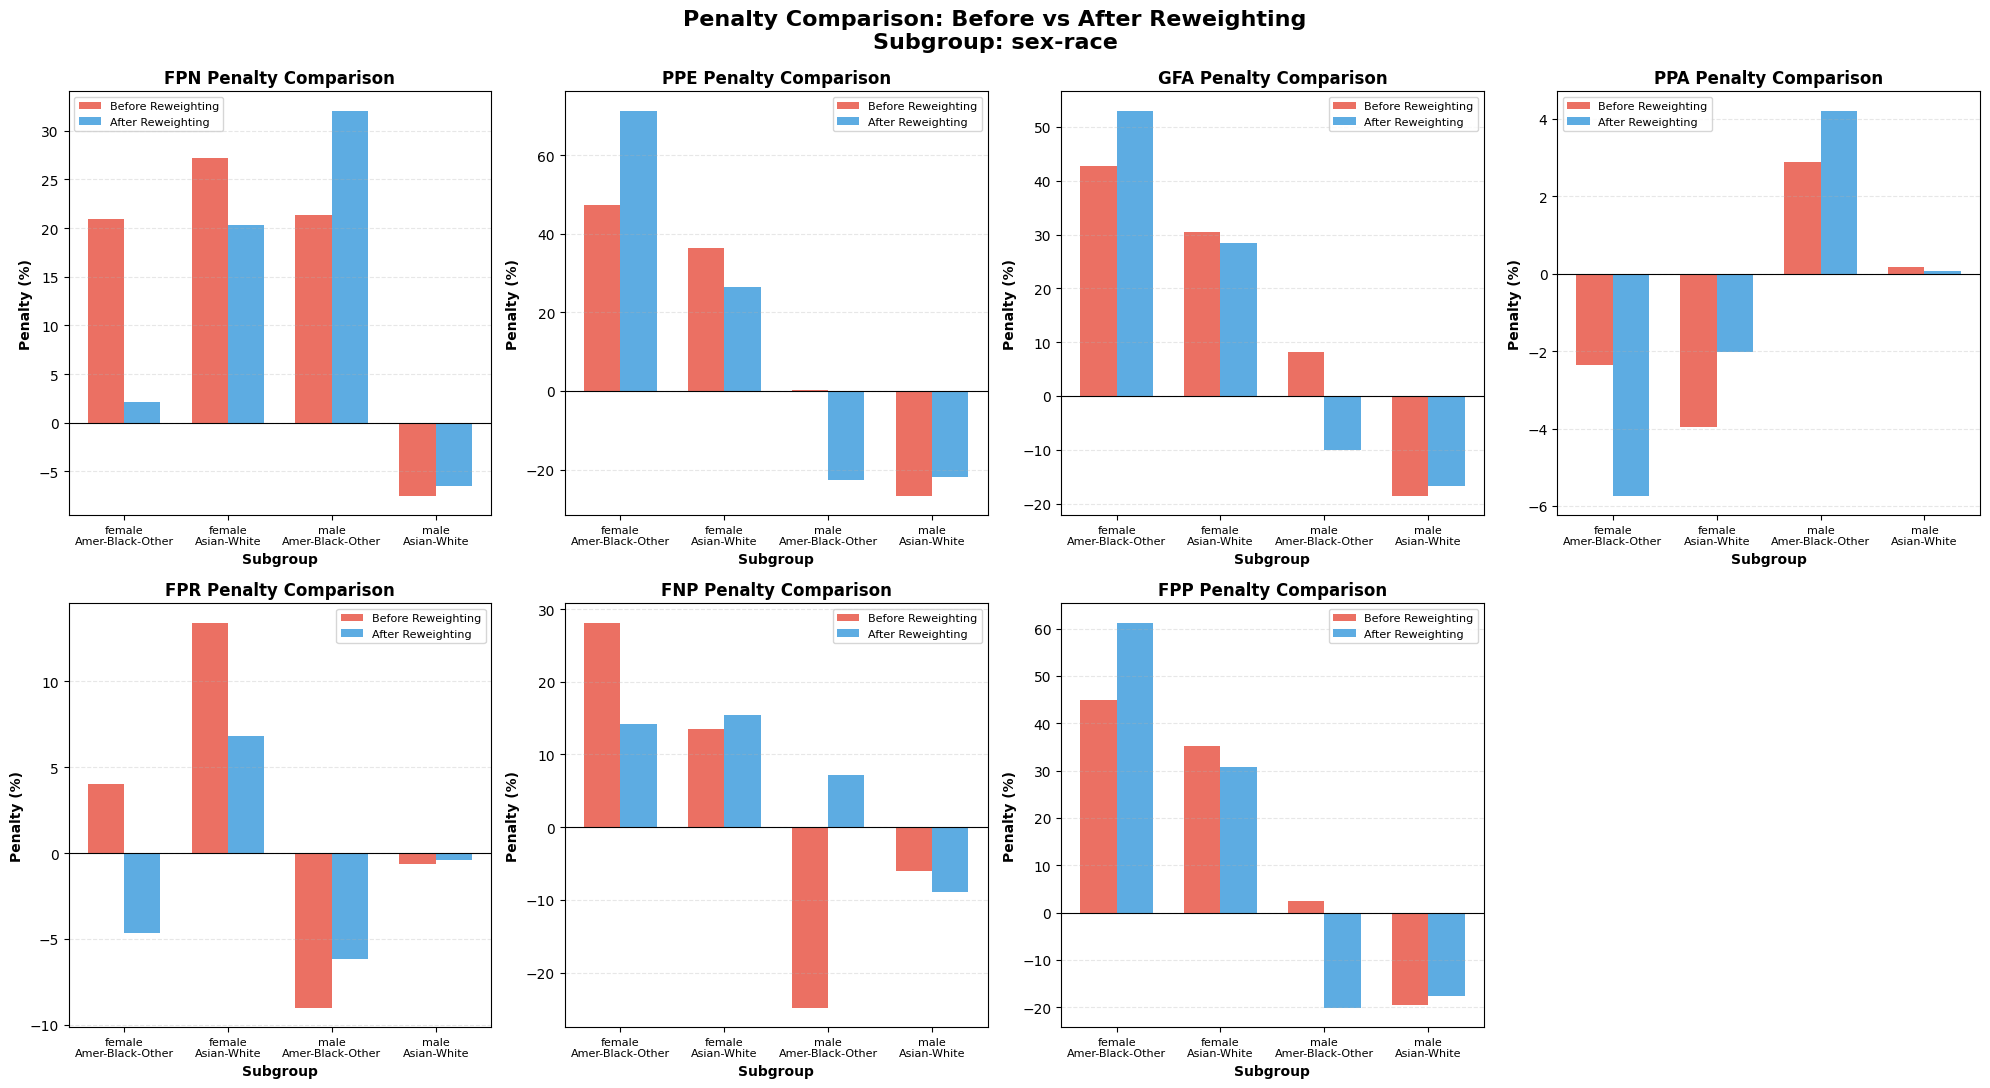

In [124]:
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting,
                                        sensible_attribute, mapping)

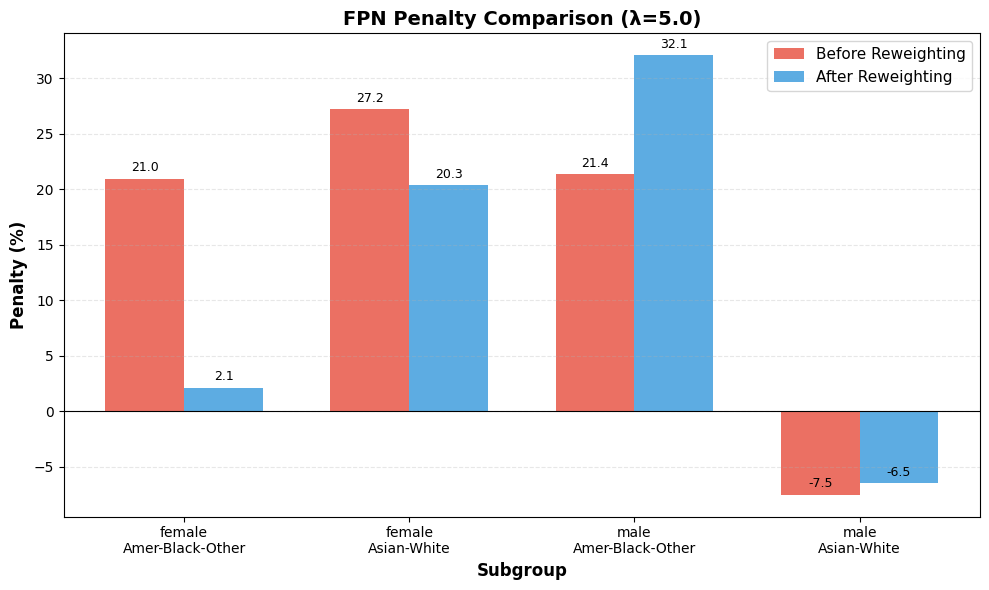


FPN - Penalty Changes:
  female-Amer-Black-Other: 20.95 → 2.13 (Δ = -18.82)
  female-Asian-White: 27.22 → 20.33 (Δ = -6.88)
  male-Amer-Black-Other: 21.38 → 32.06 (Δ = +10.68)
  male-Asian-White: -7.51 → -6.49 (Δ = +1.02)
------------------------------------------------------------


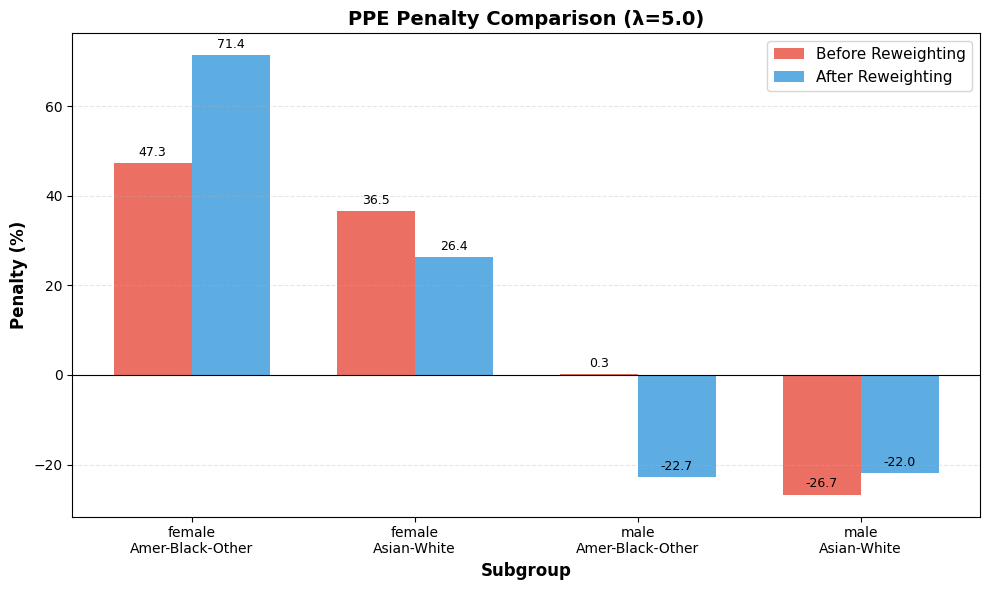


PPE - Penalty Changes:
  female-Amer-Black-Other: 47.35 → 71.38 (Δ = +24.03)
  female-Asian-White: 36.54 → 26.38 (Δ = -10.16)
  male-Amer-Black-Other: 0.25 → -22.73 (Δ = -22.98)
  male-Asian-White: -26.70 → -21.98 (Δ = +4.72)
------------------------------------------------------------


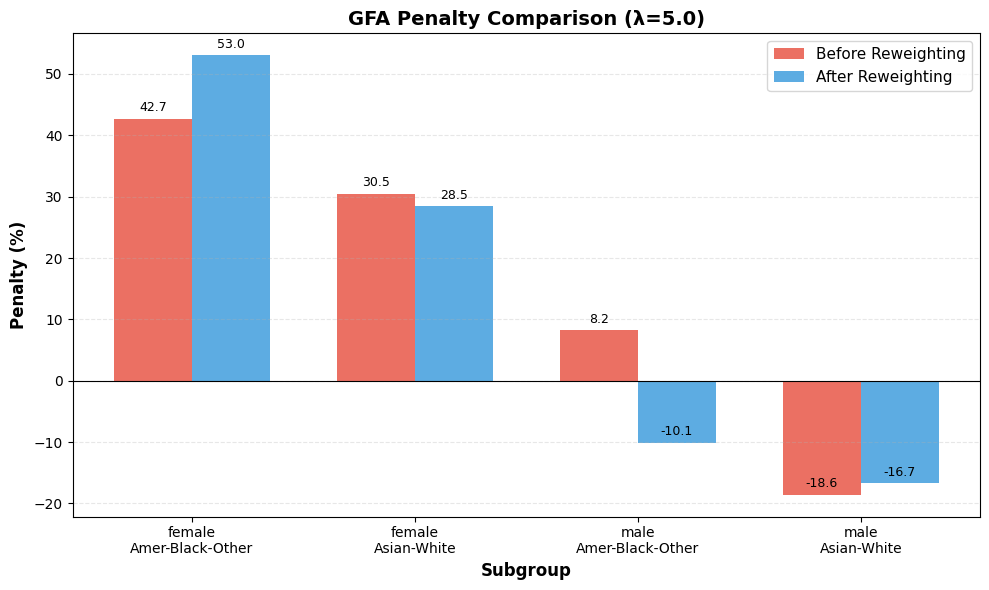


GFA - Penalty Changes:
  female-Amer-Black-Other: 42.71 → 53.04 (Δ = +10.33)
  female-Asian-White: 30.49 → 28.51 (Δ = -1.98)
  male-Amer-Black-Other: 8.25 → -10.08 (Δ = -18.33)
  male-Asian-White: -18.56 → -16.74 (Δ = +1.82)
------------------------------------------------------------


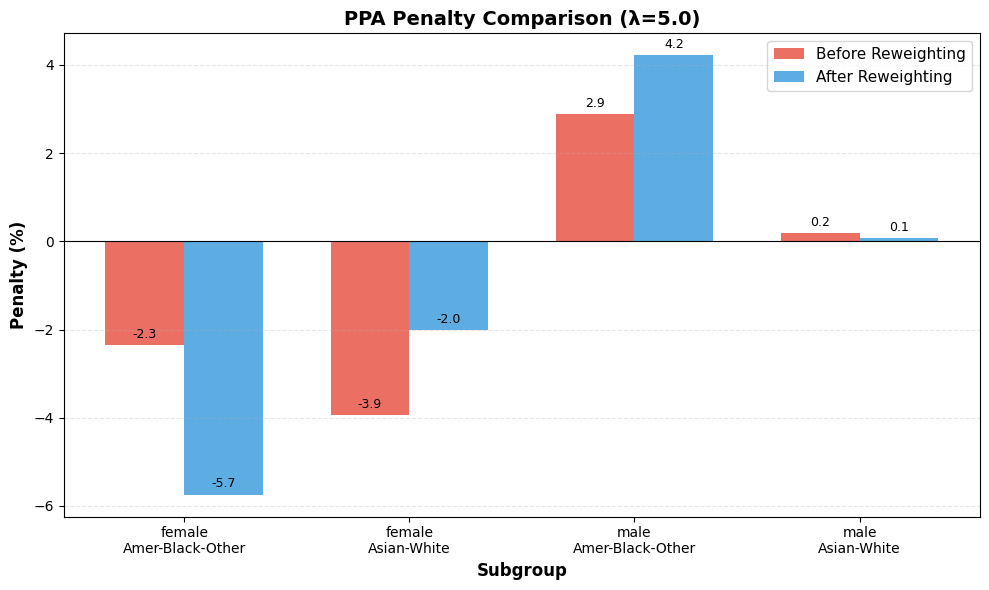


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.35 → -5.74 (Δ = -3.40)
  female-Asian-White: -3.95 → -2.02 (Δ = +1.93)
  male-Amer-Black-Other: 2.89 → 4.22 (Δ = +1.33)
  male-Asian-White: 0.18 → 0.07 (Δ = -0.11)
------------------------------------------------------------


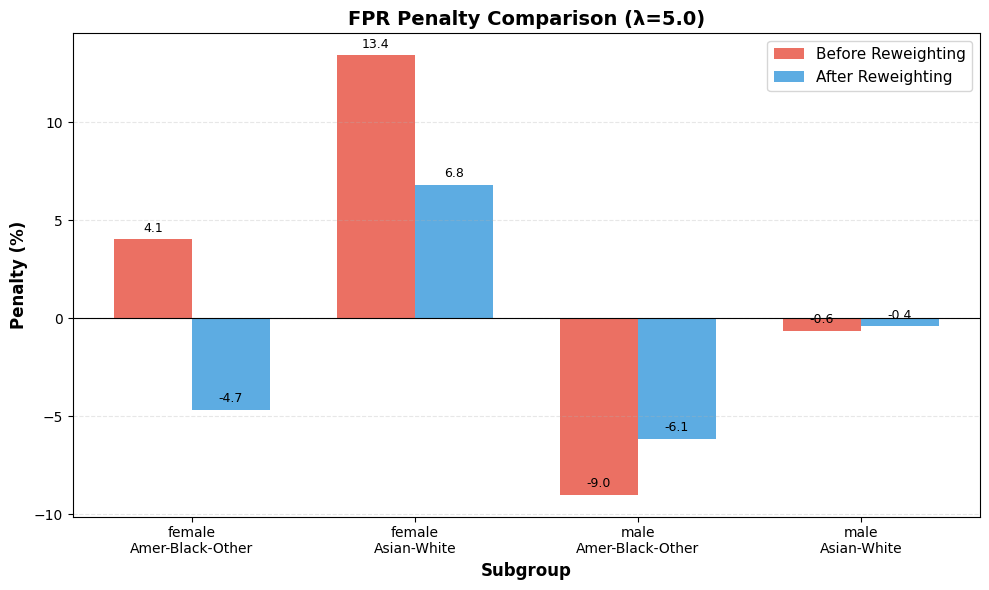


FPR - Penalty Changes:
  female-Amer-Black-Other: 4.05 → -4.67 (Δ = -8.72)
  female-Asian-White: 13.42 → 6.82 (Δ = -6.60)
  male-Amer-Black-Other: -9.00 → -6.15 (Δ = +2.86)
  male-Asian-White: -0.63 → -0.42 (Δ = +0.22)
------------------------------------------------------------


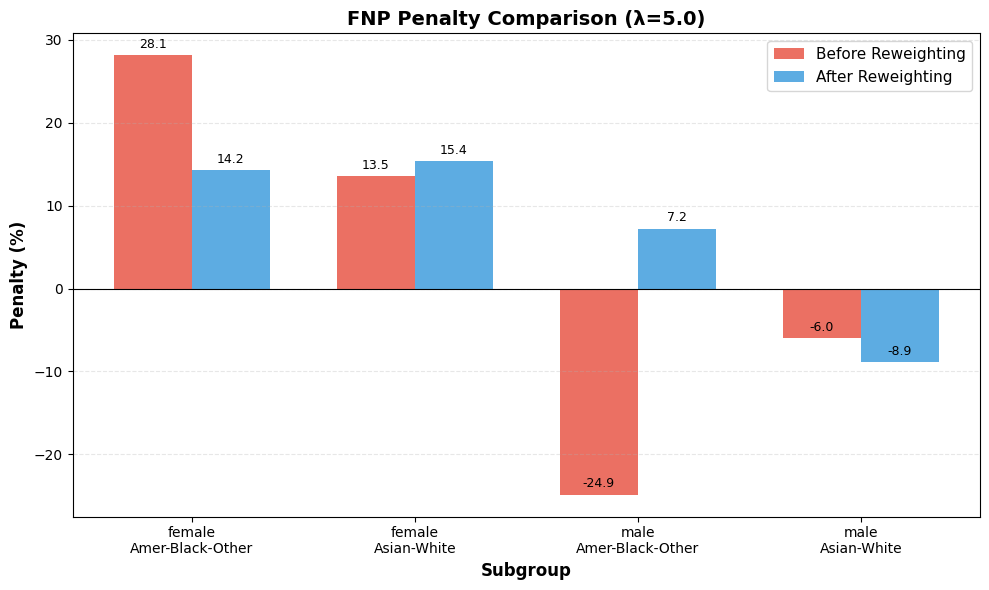


FNP - Penalty Changes:
  female-Amer-Black-Other: 28.14 → 14.24 (Δ = -13.90)
  female-Asian-White: 13.54 → 15.39 (Δ = +1.85)
  male-Amer-Black-Other: -24.85 → 7.23 (Δ = +32.08)
  male-Asian-White: -5.99 → -8.86 (Δ = -2.87)
------------------------------------------------------------


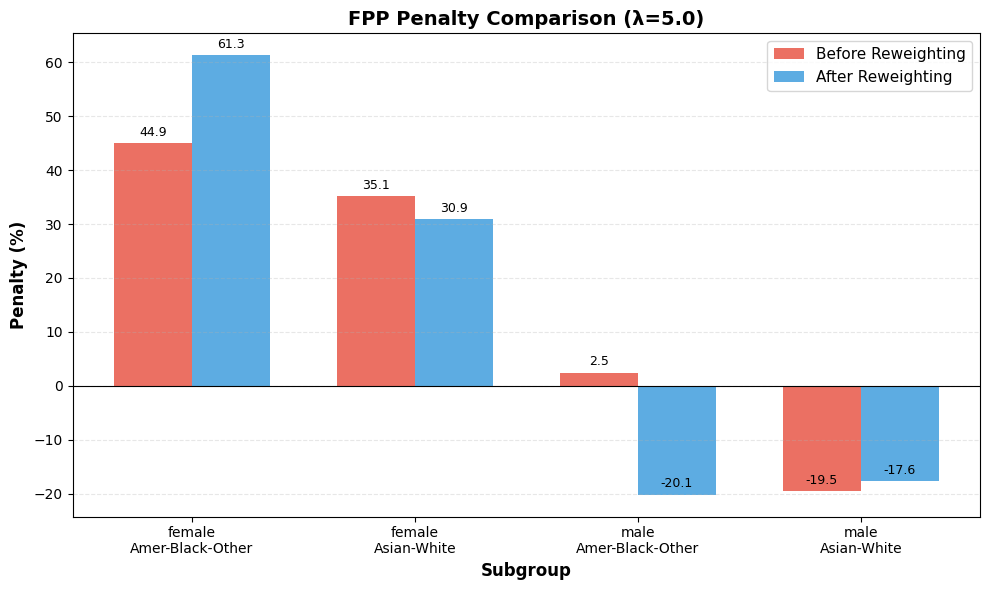


FPP - Penalty Changes:
  female-Amer-Black-Other: 44.93 → 61.26 (Δ = +16.33)
  female-Asian-White: 35.14 → 30.86 (Δ = -4.28)
  male-Amer-Black-Other: 2.48 → -20.13 (Δ = -22.60)
  male-Asian-White: -19.49 → -17.62 (Δ = +1.87)
------------------------------------------------------------


In [125]:
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting,
                                        sensible_attribute, mapping)

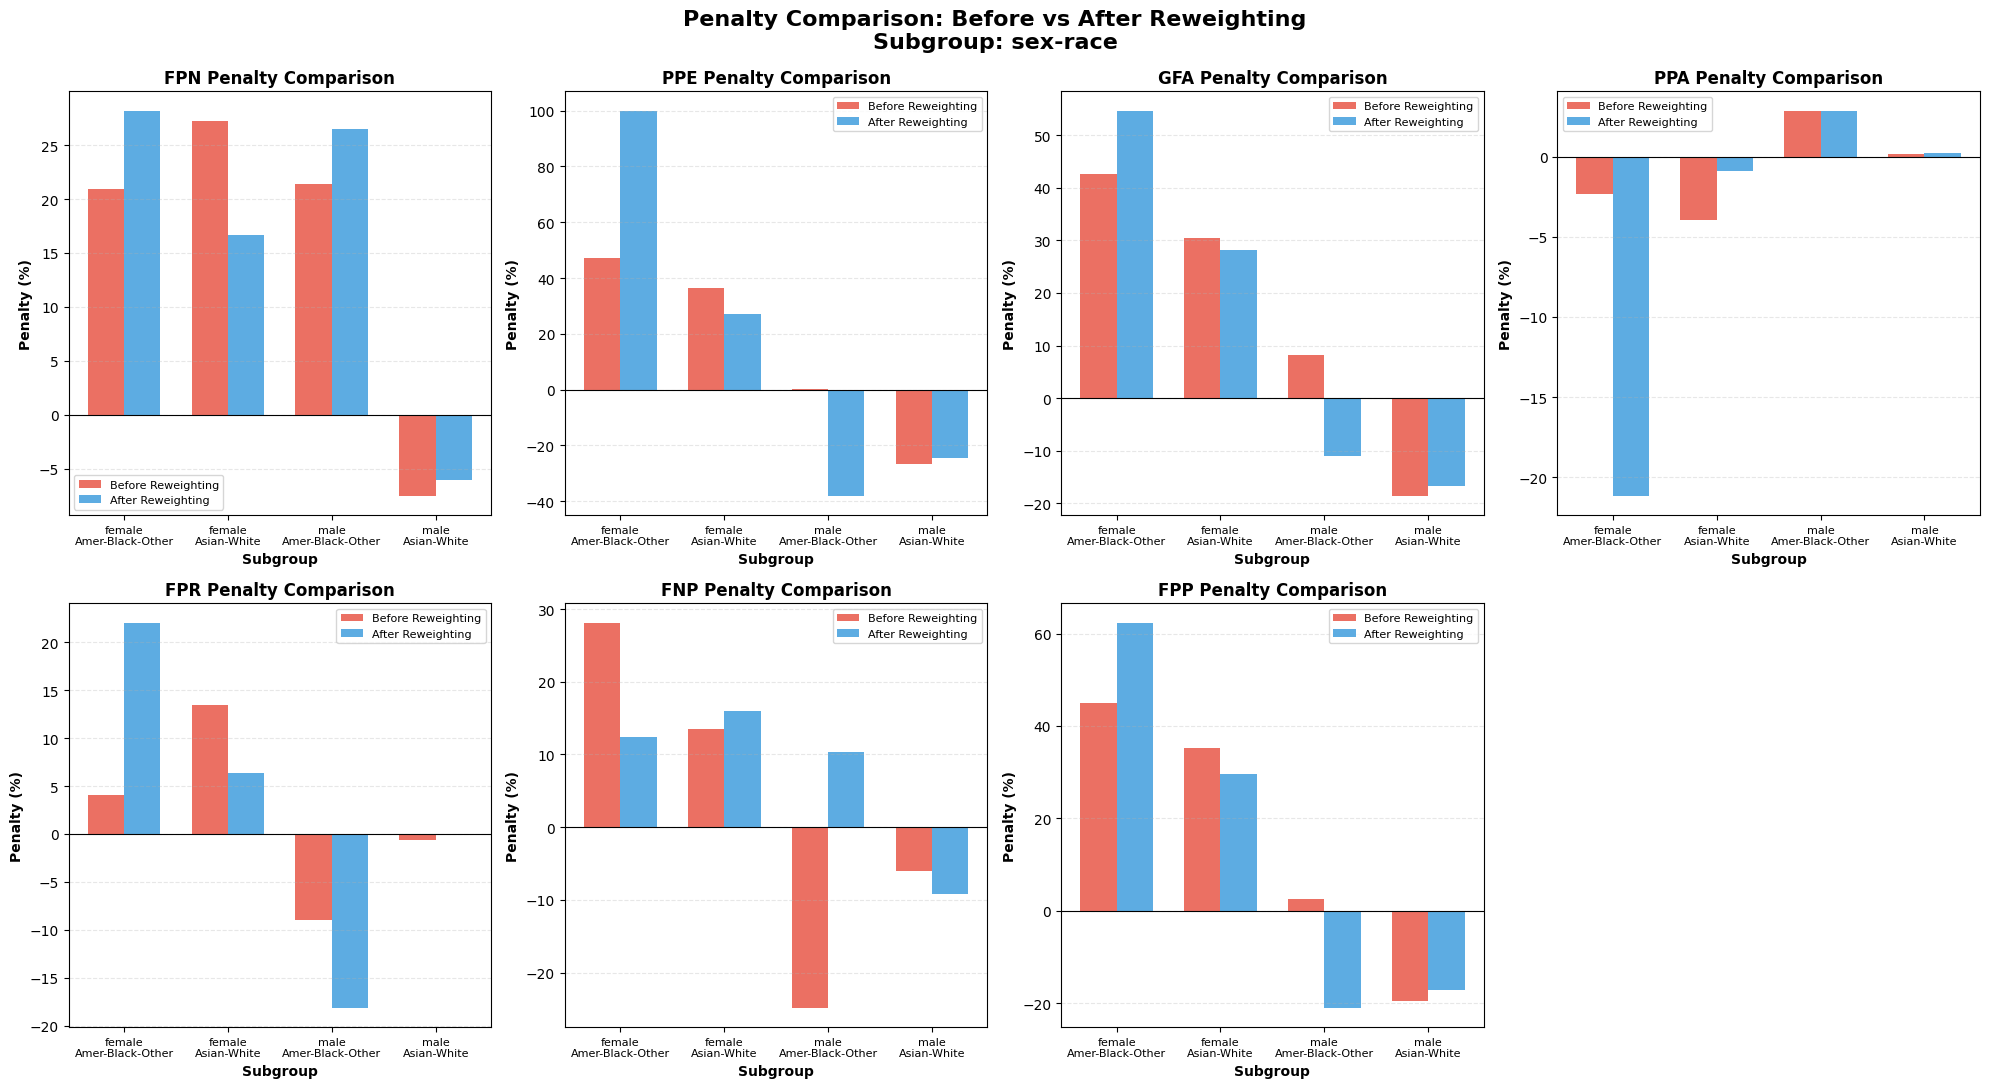

In [126]:
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_kfold,
                                        sensible_attribute, mapping)

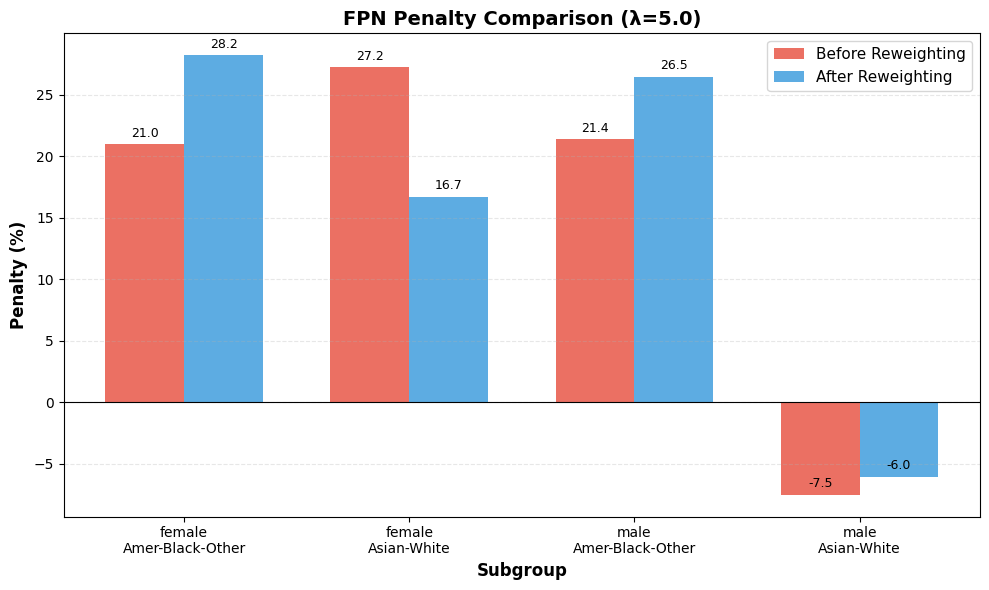


FPN - Penalty Changes:
  female-Amer-Black-Other: 20.95 → 28.19 (Δ = +7.24)
  female-Asian-White: 27.22 → 16.71 (Δ = -10.51)
  male-Amer-Black-Other: 21.38 → 26.46 (Δ = +5.08)
  male-Asian-White: -7.51 → -6.04 (Δ = +1.46)
------------------------------------------------------------


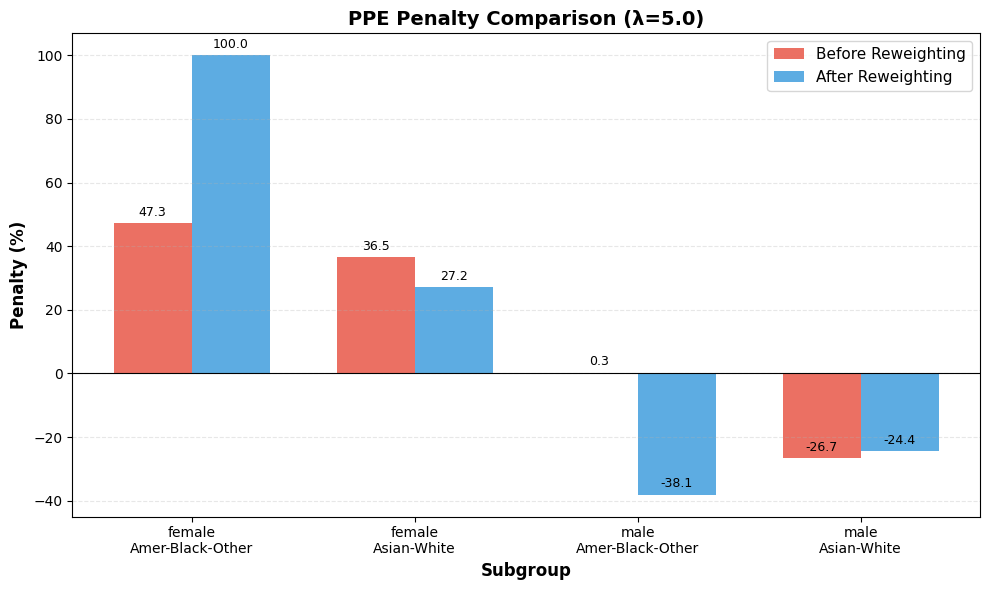


PPE - Penalty Changes:
  female-Amer-Black-Other: 47.35 → 100.00 (Δ = +52.65)
  female-Asian-White: 36.54 → 27.17 (Δ = -9.37)
  male-Amer-Black-Other: 0.25 → -38.07 (Δ = -38.32)
  male-Asian-White: -26.70 → -24.43 (Δ = +2.27)
------------------------------------------------------------


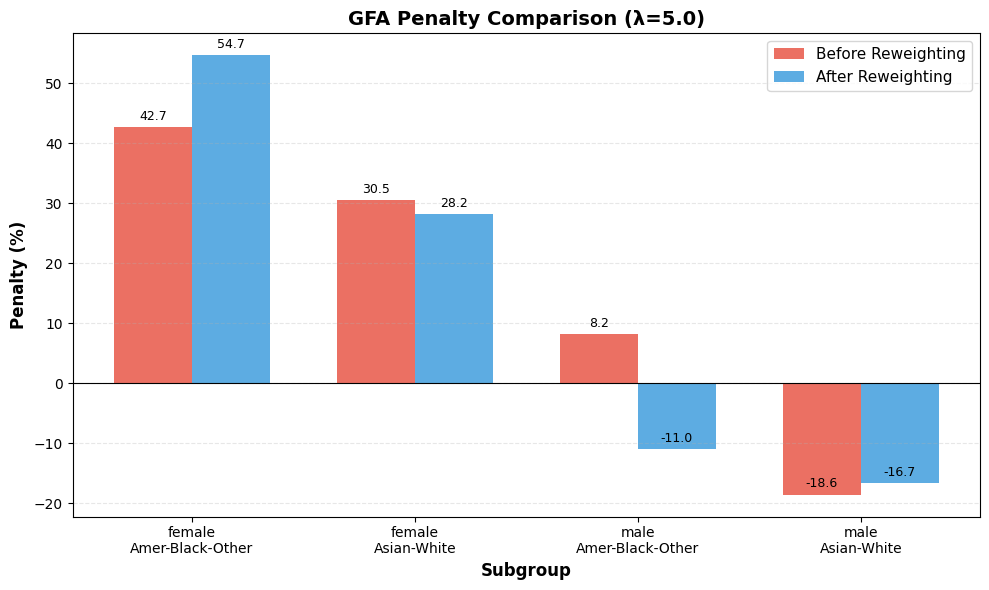


GFA - Penalty Changes:
  female-Amer-Black-Other: 42.71 → 54.66 (Δ = +11.95)
  female-Asian-White: 30.49 → 28.23 (Δ = -2.26)
  male-Amer-Black-Other: 8.25 → -10.95 (Δ = -19.20)
  male-Asian-White: -18.56 → -16.69 (Δ = +1.87)
------------------------------------------------------------


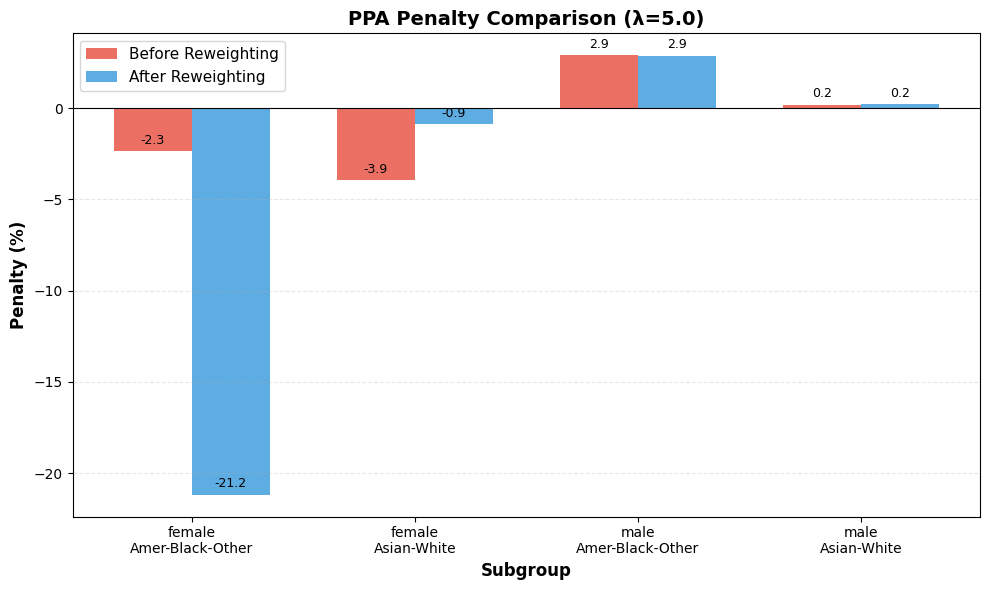


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.35 → -21.17 (Δ = -18.82)
  female-Asian-White: -3.95 → -0.86 (Δ = +3.08)
  male-Amer-Black-Other: 2.89 → 2.87 (Δ = -0.01)
  male-Asian-White: 0.18 → 0.23 (Δ = +0.05)
------------------------------------------------------------


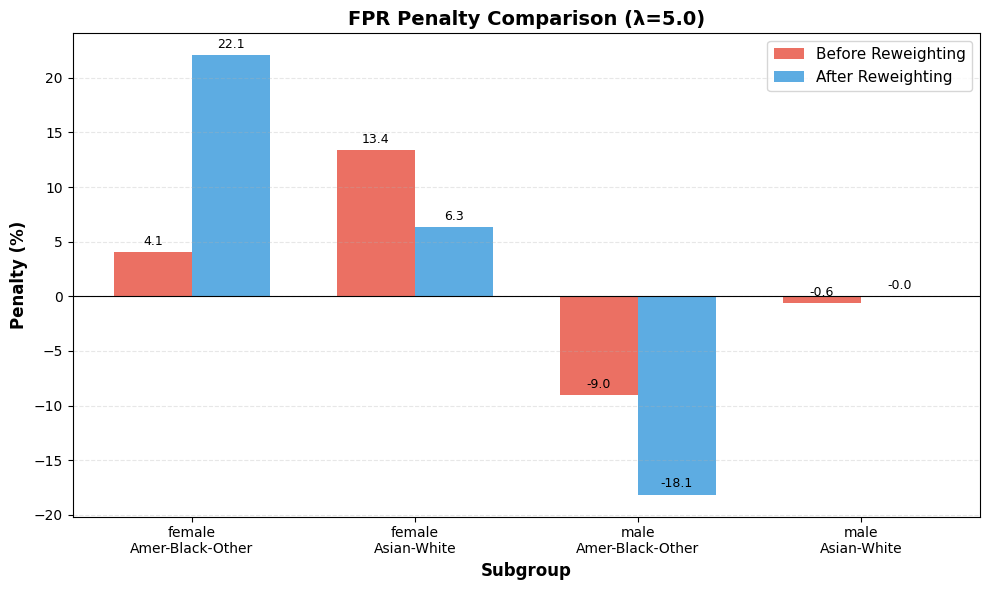


FPR - Penalty Changes:
  female-Amer-Black-Other: 4.05 → 22.06 (Δ = +18.01)
  female-Asian-White: 13.42 → 6.35 (Δ = -7.07)
  male-Amer-Black-Other: -9.00 → -18.15 (Δ = -9.14)
  male-Asian-White: -0.63 → -0.02 (Δ = +0.61)
------------------------------------------------------------


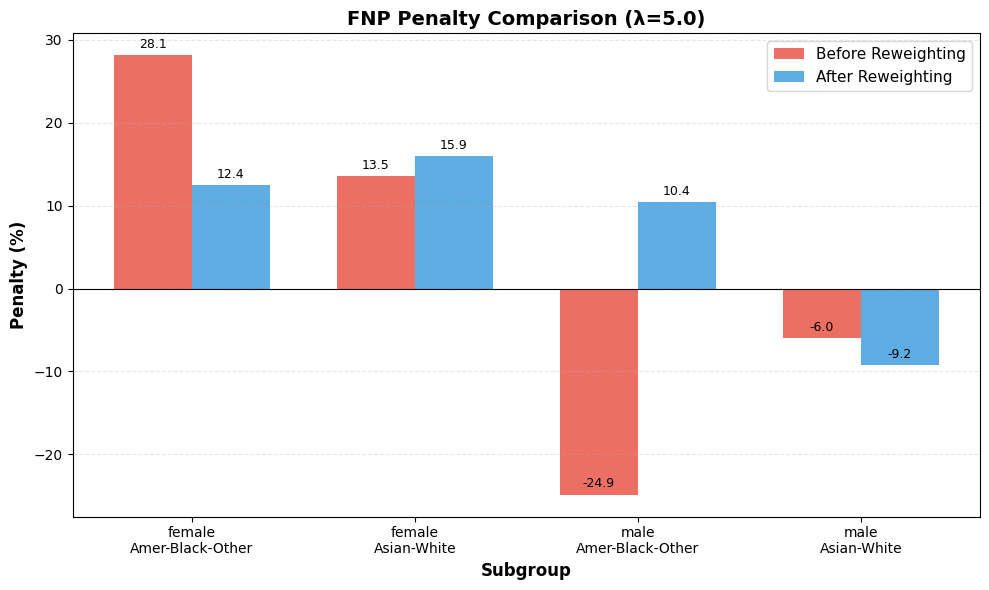


FNP - Penalty Changes:
  female-Amer-Black-Other: 28.14 → 12.43 (Δ = -15.70)
  female-Asian-White: 13.54 → 15.93 (Δ = +2.39)
  male-Amer-Black-Other: -24.85 → 10.39 (Δ = +35.24)
  male-Asian-White: -5.99 → -9.22 (Δ = -3.23)
------------------------------------------------------------


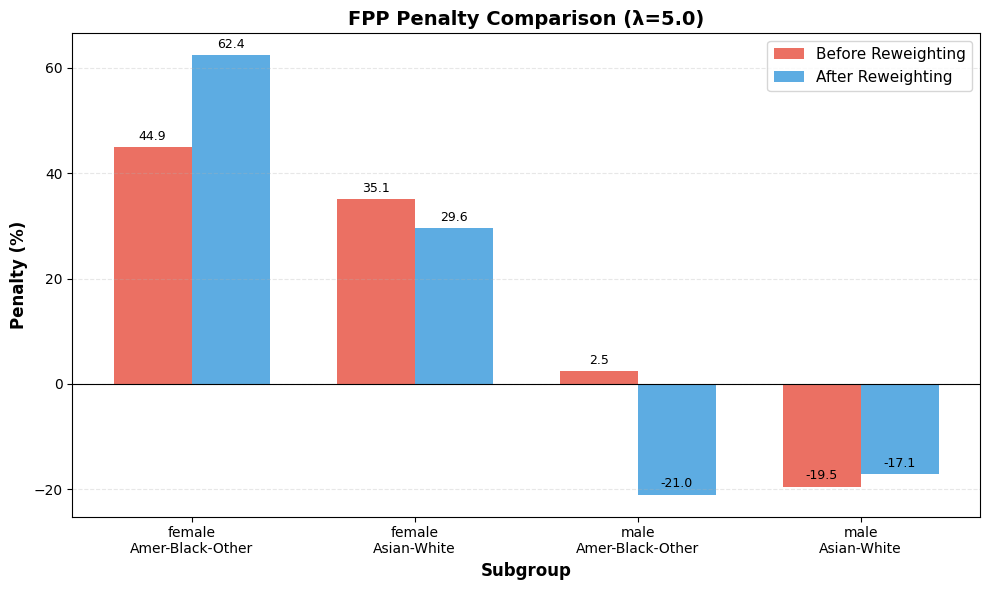


FPP - Penalty Changes:
  female-Amer-Black-Other: 44.93 → 62.37 (Δ = +17.44)
  female-Asian-White: 35.14 → 29.62 (Δ = -5.52)
  male-Amer-Black-Other: 2.48 → -21.01 (Δ = -23.49)
  male-Asian-White: -19.49 → -17.09 (Δ = +2.40)
------------------------------------------------------------


In [127]:
plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_kfold, sensible_attribute, mapping)

---

# Anchor-Based K-Fold: Ensuring Subgroup Representation

## Professor's Method: Fixed Anchor Samples

**Problem**: Some subgroups (e.g., black females = '00') may have zero or very few samples in certain K-fold splits, causing unreliable fairness metric computation.

**Solution**: 
1. **Extract anchor samples** from the target subgroup (e.g., 10 positive + 10 negative black females)
2. **Remove these anchors from the K-fold pool**
3. **Always add anchor samples to each fold's test/validation set**

This guarantees every fold has representation of the underrepresented subgroup with both positive and negative labels.

**Process**:
1. From trainval data, extract N positive + N negative samples from black females (subgroup '00')
2. These "anchor" samples are held out from K-fold splitting
3. For each fold: train on 4 folds (excluding anchors), validate on 1 fold + anchors
4. Compute fairness metrics/penalties on validation + anchors
5. Average across folds

In [128]:
# Configuration for anchor-based K-fold
TARGET_SUBGROUP = '00'  # Black females (sex=0, race=0)
N_ANCHOR_POS = 10  # Number of positive (y=1) anchor samples
N_ANCHOR_NEG = 10  # Number of negative (y=0) anchor samples

# Decode the target subgroup for readability
individual_attrs = sensible_attribute.split('-')
decoded_target = '-'.join([mapping[individual_attrs[i]][int(TARGET_SUBGROUP[i])] for i in range(len(individual_attrs))])
print(f"Target subgroup: {TARGET_SUBGROUP} ({decoded_target})")
print(f"Anchor samples: {N_ANCHOR_POS} positive + {N_ANCHOR_NEG} negative = {N_ANCHOR_POS + N_ANCHOR_NEG} total")

Target subgroup: 00 (female-Amer-Black-Other)
Anchor samples: 10 positive + 10 negative = 20 total


In [129]:
def extract_anchor_samples(X_trainval, y_trainval, sensible_attribute, target_subgroup, n_pos, n_neg, random_state=42):
    """
    Extract fixed anchor samples from a target subgroup.
    
    Args:
        X_trainval: Features dataframe (train+val combined)
        y_trainval: Target series (train+val combined)
        sensible_attribute: Column name for combined attribute (e.g., 'sex-race')
        target_subgroup: The subgroup code to extract from (e.g., '00' for black females)
        n_pos: Number of positive (y=1) samples to extract
        n_neg: Number of negative (y=0) samples to extract
        random_state: Random seed for reproducibility
    
    Returns:
        anchor_idx: Indices of anchor samples
        remaining_idx: Indices of remaining samples (for K-fold)
        X_anchor, y_anchor: Anchor samples features and labels
        X_remaining, y_remaining: Remaining samples for K-fold
    """
    np.random.seed(random_state)
    
    # Get indices of target subgroup
    subgroup_mask = X_trainval[sensible_attribute] == target_subgroup
    subgroup_idx = X_trainval[subgroup_mask].index.tolist()
    
    # Separate positive and negative within subgroup
    pos_mask = (X_trainval[sensible_attribute] == target_subgroup) & (y_trainval == 1)
    neg_mask = (X_trainval[sensible_attribute] == target_subgroup) & (y_trainval == 0)
    
    pos_idx = X_trainval[pos_mask].index.tolist()
    neg_idx = X_trainval[neg_mask].index.tolist()
    
    print(f"Target subgroup '{target_subgroup}' in trainval:")
    print(f"  Total: {len(subgroup_idx)}")
    print(f"  Positive (y=1): {len(pos_idx)}")
    print(f"  Negative (y=0): {len(neg_idx)}")
    
    # Check if we have enough samples
    if len(pos_idx) < n_pos:
        print(f"  WARNING: Only {len(pos_idx)} positive samples available, using all of them")
        n_pos = len(pos_idx)
    if len(neg_idx) < n_neg:
        print(f"  WARNING: Only {len(neg_idx)} negative samples available, using all of them")
        n_neg = len(neg_idx)
    
    # Randomly select anchor samples
    anchor_pos_idx = np.random.choice(pos_idx, size=n_pos, replace=False).tolist()
    anchor_neg_idx = np.random.choice(neg_idx, size=n_neg, replace=False).tolist()
    anchor_idx = anchor_pos_idx + anchor_neg_idx
    
    print(f"\nExtracted anchor samples:")
    print(f"  Positive anchors: {n_pos}")
    print(f"  Negative anchors: {n_neg}")
    print(f"  Total anchors: {len(anchor_idx)}")
    
    # Remaining samples (for K-fold)
    remaining_idx = [i for i in X_trainval.index if i not in anchor_idx]
    
    print(f"\nRemaining samples for K-fold: {len(remaining_idx)}")
    
    # Extract data
    X_anchor = X_trainval.loc[anchor_idx]
    y_anchor = y_trainval.loc[anchor_idx]
    X_remaining = X_trainval.loc[remaining_idx]
    y_remaining = y_trainval.loc[remaining_idx]
    
    return anchor_idx, remaining_idx, X_anchor, y_anchor, X_remaining, y_remaining

In [130]:
def compute_penalties_kfold_with_anchors(sensible_attribute, fair_metrics, 
                                          target_subgroup='00', n_anchor_pos=10, n_anchor_neg=10,
                                          n_folds=5, verbose=True):
    """
    Compute penalties using K-Fold CV with fixed anchor samples to ensure subgroup representation.
    
    The anchor samples from the target subgroup are ALWAYS added to the validation set of each fold,
    ensuring that the subgroup is represented with both positive and negative labels in every fold.
    
    Args:
        sensible_attribute: Combined attribute like 'sex-race'
        fair_metrics: List of fairness metrics to compute penalties for
        target_subgroup: Subgroup code to anchor (e.g., '00' for black females)
        n_anchor_pos: Number of positive anchor samples
        n_anchor_neg: Number of negative anchor samples
        n_folds: Number of folds (default 5)
        verbose: Print progress
    
    Returns:
        penalties_kfold_avg: Dict of {metric: {subgroup: averaged_penalty}}
        penalties_per_fold: Dict of {metric: {subgroup: [penalties_per_fold]}}
        anchor_info: Dict with anchor sample information
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    if verbose:
        print("="*100)
        print(f"ANCHOR-BASED K-FOLD CROSS-VALIDATION (K={n_folds})")
        print("="*100)
        print(f"Target subgroup for anchoring: {target_subgroup}")
        decoded_target = '-'.join([mapping[individual_attrs[i]][int(target_subgroup[i])] for i in range(len(individual_attrs))])
        print(f"Decoded: {decoded_target}")
        print(f"Train+Val samples: {len(X_trainval)}")
        print(f"Test samples (held out): {len(X_test[sensible_attribute])}")
    
    # Step 1: Extract anchor samples from target subgroup
    print("\n" + "-"*100)
    print("STEP 1: Extract Anchor Samples")
    print("-"*100)
    
    anchor_idx, remaining_idx, X_anchor, y_anchor, X_remaining, y_remaining = \
        extract_anchor_samples(X_trainval, y_trainval, sensible_attribute, 
                               target_subgroup, n_anchor_pos, n_anchor_neg)
    
    anchor_info = {
        'target_subgroup': target_subgroup,
        'n_pos': (y_anchor == 1).sum(),
        'n_neg': (y_anchor == 0).sum(),
        'anchor_indices': anchor_idx
    }
    
    # Initialize storage for penalties per fold
    subgroups = sorted(X_trainval[sensible_attribute].unique())
    penalties_per_fold = {m: {g: [] for g in subgroups} for m in fair_metrics}
    
    # Step 2: Setup stratified K-fold on REMAINING samples (excluding anchors)
    print("\n" + "-"*100)
    print("STEP 2: K-Fold on Remaining Samples (Anchors Added to Each Validation Set)")
    print("-"*100)
    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Load dataframe once for fairness computation
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx_rel, val_idx_rel) in enumerate(skf.split(X_remaining, y_remaining)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Get actual indices (not relative to X_remaining)
        train_idx = X_remaining.iloc[train_idx_rel].index.tolist()
        val_idx = X_remaining.iloc[val_idx_rel].index.tolist()
        
        # Split data for this fold (training = fold train only, NO anchors)
        X_fold_train = X_trainval.loc[train_idx]
        y_fold_train = y_trainval.loc[train_idx]
        
        # Validation = fold validation + ANCHOR samples
        val_idx_with_anchors = val_idx + anchor_idx
        X_fold_val = X_trainval.loc[val_idx_with_anchors]
        y_fold_val = y_trainval.loc[val_idx_with_anchors]
        
        if verbose:
            # Show distribution in this fold's validation set
            val_dist = X_fold_val[sensible_attribute].value_counts().sort_index()
            print(f"  Train samples: {len(X_fold_train)}")
            print(f"  Val samples: {len(val_idx)} + {len(anchor_idx)} anchors = {len(X_fold_val)}")
            print(f"  Val distribution: {val_dist.to_dict()}")
            
            # Verify target subgroup has both pos and neg
            target_in_val = X_fold_val[X_fold_val[sensible_attribute] == target_subgroup]
            target_pos = (y_fold_val.loc[target_in_val.index] == 1).sum()
            target_neg = (y_fold_val.loc[target_in_val.index] == 0).sum()
            print(f"  Target subgroup '{target_subgroup}' in val: {len(target_in_val)} samples ({target_pos} pos, {target_neg} neg)")
        
        # Convert to numeric for XGBoost
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        X_fold_val_num = X_fold_val.copy()
        X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes
        
        # Train model on this fold's training data (WITHOUT anchors)
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # Predict on this fold's validation data (WITH anchors)
        y_pred_fold_val = model_fold.predict(X_fold_val_num)
        
        # Compute fairness metrics for each attribute
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            # Get sensible indexes for this fold's validation set (including anchors)
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
            
            # Compute confusion matrix
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
            )
            
            # Compute fairness metrics
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties for each metric
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            # Store penalty for each subgroup
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {}
    for m in fair_metrics:
        penalties_kfold_avg[m] = {}
        for group in subgroups:
            fold_penalties = penalties_per_fold[m][group]
            penalties_kfold_avg[m][group] = np.mean(fold_penalties)
    
    if verbose:
        print("\n" + "="*100)
        print("AVERAGED PENALTIES (across folds, with anchors)")
        print("="*100)
        for m in fair_metrics[:3]:  # Show first 3 metrics
            print(f"\n{m}:")
            for group in subgroups:
                decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                fold_vals = penalties_per_fold[m][group]
                marker = " <-- ANCHORED" if group == target_subgroup else ""
                print(f"  {group} ({decoded:18s}): avg={avg:+.2f}%, std={std:.2f}{marker}")
    
    return penalties_kfold_avg, penalties_per_fold, anchor_info

## Run Anchor-Based K-Fold

Test with different anchor configurations:
- 10 positive + 10 negative (default)
- 5 positive + 5 negative (smaller anchor set)
- 20 positive + 20 negative (larger anchor set, if available)

In [131]:
# Run anchor-based K-fold with 10+10 anchors for black females ('00')
print("="*100)
print("ANCHOR-BASED K-FOLD: 10 positive + 10 negative anchors from black females")
print("="*100)

penalties_anchor_avg, penalties_anchor_per_fold, anchor_info = compute_penalties_kfold_with_anchors(
    sensible_attribute='sex-race',
    fair_metrics=fair_metrics,
    target_subgroup='00',  # Black females
    n_anchor_pos=10,
    n_anchor_neg=10,
    n_folds=5,
    verbose=True
)

ANCHOR-BASED K-FOLD: 10 positive + 10 negative anchors from black females
ANCHOR-BASED K-FOLD CROSS-VALIDATION (K=5)
Target subgroup for anchoring: 00
Decoded: female-Amer-Black-Other
Train+Val samples: 27676
Test samples (held out): 4885

----------------------------------------------------------------------------------------------------
STEP 1: Extract Anchor Samples
----------------------------------------------------------------------------------------------------
Target subgroup '00' in trainval:
  Total: 1496
  Positive (y=1): 85
  Negative (y=0): 1411

Extracted anchor samples:
  Positive anchors: 10
  Negative anchors: 10
  Total anchors: 20

Remaining samples for K-fold: 27656

----------------------------------------------------------------------------------------------------
STEP 2: K-Fold on Remaining Samples (Anchors Added to Each Validation Set)
----------------------------------------------------------------------------------------------------

--- Fold 1/5 ---
  Train s

In [132]:
# Compare: Standard K-fold vs Anchor-based K-fold
print("="*100)
print("COMPARISON: Standard K-Fold vs Anchor-Based K-Fold")
print("="*100)

individual_attrs = sensible_attribute.split('-')

for m in fair_metrics[:5]:  # Show first 5 metrics
    print(f"\n{m}:")
    print(f"  {'Group':<25} | {'Std K-Fold':>12} | {'Anchor K-Fold':>12} | {'Std-KF StdDev':>12} | {'Anc-KF StdDev':>12}")
    print("  " + "-"*90)
    
    for group in ['00', '01', '10', '11']:
        # Decode group name
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        std_kfold_avg = penalties_kfold_avg[m][group]
        std_kfold_std = np.std(penalties_per_fold[m][group])
        
        anchor_kfold_avg = penalties_anchor_avg[m][group]
        anchor_kfold_std = np.std(penalties_anchor_per_fold[m][group])
        
        marker = " <-- ANCHORED" if group == '00' else ""
        print(f"  {group} ({decoded:18s}) | {std_kfold_avg:+12.2f} | {anchor_kfold_avg:+12.2f} | {std_kfold_std:12.2f} | {anchor_kfold_std:12.2f}{marker}")

print("\n" + "="*100)
print("INTERPRETATION:")
print("  - Lower StdDev = more stable penalty estimate across folds")
print("  - Anchor-based should show more stable estimates for the anchored subgroup ('00')")
print("="*100)

COMPARISON: Standard K-Fold vs Anchor-Based K-Fold

FPN:
  Group                     |   Std K-Fold | Anchor K-Fold | Std-KF StdDev | Anc-KF StdDev
  ------------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |       +12.97 |       +43.62 |        55.40 |        38.41 <-- ANCHORED
  01 (female-Asian-White) |       +15.32 |        +5.40 |         8.68 |         4.56
  10 (male-Amer-Black-Other) |       +16.93 |       +12.57 |        22.21 |        38.97
  11 (male-Asian-White  ) |        -4.12 |        -3.20 |         0.90 |         1.48

PPE:
  Group                     |   Std K-Fold | Anchor K-Fold | Std-KF StdDev | Anc-KF StdDev
  ------------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |       +57.54 |       +64.79 |        27.58 |        26.92 <-- ANCHORED
  01 (female-Asian-White) |       +30.29 |       +25.06 |         6.66 |         3.03
  10 (male-Ame

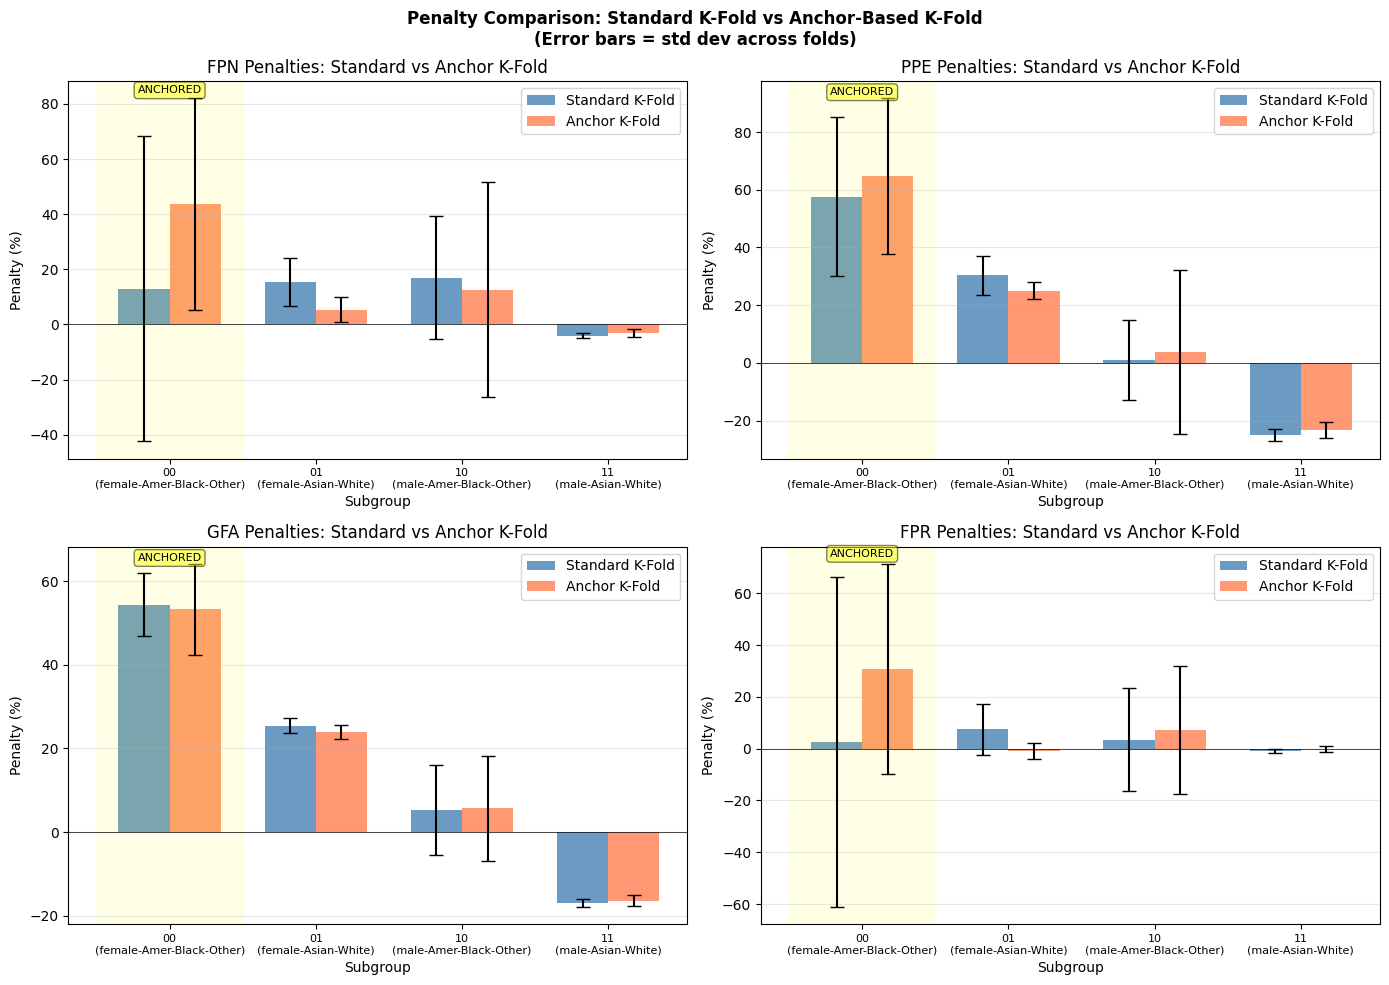

In [133]:
# Visualization: Compare penalty stability between methods
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

subgroups = ['00', '01', '10', '11']
decoded_labels = ['-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))]) for g in subgroups]

# metrics_to_plot = ['FPN', 'PPE', 'EOP', 'FPR']
metrics_to_plot = ['FPN', 'PPE', 'GFA', 'FPR']


for idx, m in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    x = np.arange(len(subgroups))
    width = 0.35
    
    # Standard K-fold values
    std_means = [penalties_kfold_avg[m][g] for g in subgroups]
    std_stds = [np.std(penalties_per_fold[m][g]) for g in subgroups]
    
    # Anchor K-fold values
    anchor_means = [penalties_anchor_avg[m][g] for g in subgroups]
    anchor_stds = [np.std(penalties_anchor_per_fold[m][g]) for g in subgroups]
    
    bars1 = ax.bar(x - width/2, std_means, width, label='Standard K-Fold', 
                   yerr=std_stds, capsize=5, color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, anchor_means, width, label='Anchor K-Fold', 
                   yerr=anchor_stds, capsize=5, color='coral', alpha=0.8)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Subgroup')
    ax.set_ylabel('Penalty (%)')
    ax.set_title(f'{m} Penalties: Standard vs Anchor K-Fold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight anchored subgroup
    ax.axvspan(-0.5, 0.5, alpha=0.1, color='yellow')
    ax.text(0, ax.get_ylim()[1]*0.95, 'ANCHORED', ha='center', fontsize=8, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.suptitle('Penalty Comparison: Standard K-Fold vs Anchor-Based K-Fold\n(Error bars = std dev across folds)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Experiment: Different Anchor Sizes

Test how the number of anchor samples affects penalty stability:
- **5+5**: Smaller anchor set (less impact on validation size)
- **10+10**: Default anchor set
- **All available**: Use all positive + all negative from the target subgroup

In [134]:
# Test different anchor sizes
anchor_configs = [
    {'n_pos': 5, 'n_neg': 5, 'label': '5+5'},
    {'n_pos': 10, 'n_neg': 10, 'label': '10+10'},
    # You can add more configurations here
]

results_by_anchor_size = {}

for config in anchor_configs:
    print(f"\n{'='*100}")
    print(f"Testing anchor size: {config['label']}")
    print(f"{'='*100}")
    
    penalties_avg, penalties_fold, info = compute_penalties_kfold_with_anchors(
        sensible_attribute='sex-race',
        fair_metrics=fair_metrics,
        target_subgroup='00',
        n_anchor_pos=config['n_pos'],
        n_anchor_neg=config['n_neg'],
        n_folds=5,
        verbose=False
    )
    
    results_by_anchor_size[config['label']] = {
        'avg': penalties_avg,
        'per_fold': penalties_fold,
        'info': info
    }
    
    # Summary for this config
    print(f"\nResults for {config['label']}:")
    m = 'FPN'
    for group in ['00', '01', '10', '11']:
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        avg = penalties_avg[m][group]
        std = np.std(penalties_fold[m][group])
        marker = " <-- ANCHORED" if group == '00' else ""
        print(f"  {group} ({decoded}): avg={avg:+.2f}%, std={std:.2f}{marker}")


Testing anchor size: 5+5

----------------------------------------------------------------------------------------------------
STEP 1: Extract Anchor Samples
----------------------------------------------------------------------------------------------------
Target subgroup '00' in trainval:
  Total: 1496
  Positive (y=1): 85
  Negative (y=0): 1411

Extracted anchor samples:
  Positive anchors: 5
  Negative anchors: 5
  Total anchors: 10

Remaining samples for K-fold: 27666

----------------------------------------------------------------------------------------------------
STEP 2: K-Fold on Remaining Samples (Anchors Added to Each Validation Set)
----------------------------------------------------------------------------------------------------

Results for 5+5:
  00 (female-Amer-Black-Other): avg=+39.92%, std=35.85 <-- ANCHORED
  01 (female-Asian-White): avg=+13.79%, std=4.34
  10 (male-Amer-Black-Other): avg=+21.56%, std=21.42
  11 (male-Asian-White): avg=-4.77%, std=1.38

Testing

## Apply Anchor-Based Penalties for Reweighting

Use the penalties computed from anchor-based K-fold to compute sample weights and evaluate improvement on test set.

In [135]:
# Use anchor-based penalties to compute weights
# Using FPN metric as example

metric_to_use = 'FPN'
lambda_value = 1.0  # Weighting strength parameter

print("="*100)
print(f"COMPUTING WEIGHTS FROM ANCHOR-BASED K-FOLD PENALTIES (metric: {metric_to_use})")
print("="*100)

# Get penalties for the combined attribute
anchor_penalties = penalties_anchor_avg[metric_to_use]
print(f"\nAnchor-based penalties:")
for group in ['00', '01', '10', '11']:
    decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
    print(f"  {group} ({decoded}): {anchor_penalties[group]:+.2f}%")

# Compute weights for each sample in training set based on their subgroup penalty
X_trainval_combined = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
y_trainval_combined = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])

# Create weight array
weights_anchor = np.ones(len(X_trainval_combined))

for i, (idx, row) in enumerate(X_trainval_combined.iterrows()):
    group = row[sensible_attribute]
    penalty = anchor_penalties.get(group, 0)
    # Weight formula: higher penalty = higher weight (to prioritize disadvantaged groups)
    weights_anchor[i] = 1 + lambda_value * (penalty / 100)
    # Ensure weights are positive
    weights_anchor[i] = max(0.1, weights_anchor[i])

print(f"\nWeight statistics:")
print(f"  Min: {weights_anchor.min():.3f}")
print(f"  Max: {weights_anchor.max():.3f}")
print(f"  Mean: {weights_anchor.mean():.3f}")
print(f"  Std: {weights_anchor.std():.3f}")

# Show weights per subgroup
print(f"\nAverage weight per subgroup:")
for group in ['00', '01', '10', '11']:
    decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
    group_mask = X_trainval_combined[sensible_attribute] == group
    avg_weight = weights_anchor[group_mask.values].mean()
    print(f"  {group} ({decoded}): {avg_weight:.3f}")

COMPUTING WEIGHTS FROM ANCHOR-BASED K-FOLD PENALTIES (metric: FPN)

Anchor-based penalties:
  00 (female-Amer-Black-Other): +43.62%
  01 (female-Asian-White): +5.40%
  10 (male-Amer-Black-Other): +12.57%
  11 (male-Asian-White): -3.20%

Weight statistics:
  Min: 0.968
  Max: 1.436
  Mean: 1.026
  Std: 0.109

Average weight per subgroup:
  00 (female-Amer-Black-Other): 1.436
  01 (female-Asian-White): 1.054
  10 (male-Amer-Black-Other): 1.126
  11 (male-Asian-White): 0.968


In [136]:
# Train weighted model and evaluate on test set
import xgboost as xgb

print("="*100)
print("TRAINING WEIGHTED MODEL AND EVALUATING ON TEST SET")
print("="*100)

# Prepare training data
X_trainval_num = X_trainval_combined.copy()
X_trainval_num[sensible_attribute] = X_trainval_num[sensible_attribute].astype('category').cat.codes

X_test_num = X_test[sensible_attribute].copy()
X_test_num[sensible_attribute] = X_test_num[sensible_attribute].astype('category').cat.codes

# Train model WITHOUT weights (baseline)
print("\nTraining baseline model (no weights)...")
model_baseline = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
model_baseline.fit(X_trainval_num, y_trainval_combined)
y_pred_baseline = model_baseline.predict(X_test_num)

# Train model WITH anchor-based weights
print("Training weighted model (anchor-based penalties)...")
model_weighted = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
model_weighted.fit(X_trainval_num, y_trainval_combined, sample_weight=weights_anchor)
y_pred_weighted = model_weighted.predict(X_test_num)

print("\n" + "-"*100)
print("BASELINE MODEL PERFORMANCE (Test Set):")
print("-"*100)
performance_metrics(y_test[sensible_attribute], y_pred_baseline)

print("\n" + "-"*100)
print("WEIGHTED MODEL PERFORMANCE (Test Set):")
print("-"*100)
performance_metrics(y_test[sensible_attribute], y_pred_weighted)

TRAINING WEIGHTED MODEL AND EVALUATING ON TEST SET

Training baseline model (no weights)...
Training weighted model (anchor-based penalties)...

----------------------------------------------------------------------------------------------------
BASELINE MODEL PERFORMANCE (Test Set):
----------------------------------------------------------------------------------------------------
Precision: 0.7732949087415946, Recall: 0.6674958540630183, Accuracy: 0.8696008188331628, F1: 0.7165109034267912

----------------------------------------------------------------------------------------------------
WEIGHTED MODEL PERFORMANCE (Test Set):
----------------------------------------------------------------------------------------------------
Precision: 0.7766895200783546, Recall: 0.6575456053067993, Accuracy: 0.8687819856704196, F1: 0.7121688370004491


(0.7766895200783546,
 0.6575456053067993,
 0.8687819856704196,
 0.7121688370004491)

In [137]:
# Compare penalties on test set: Baseline vs Weighted
df_original = pd.read_csv(dataset_path)
attributes = sensible_attribute.split('-') + [sensible_attribute]
individual_attrs = sensible_attribute.split('-')

# Compute fairness metrics for baseline
fairness_baseline = {}
for attribute in attributes:
    df_attr = df_original.copy()
    if '-' in attribute:
        indiv_attrs = attribute.split('-')
        df_attr[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str),
            [df_attr[col] for col in indiv_attrs]
        )
    
    sensible_idx_test = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
    cm_dict_baseline = compute_cm_group(
        df_attr, attribute, sensible_idx_test,
        y_pred_baseline, y_test[sensible_attribute], X_test[sensible_attribute], target_variable_labels
    )
    fairness_baseline[attribute] = {}
    for m in fair_metrics:
        fairness_baseline[attribute][m], _ = compute_fairness_metrics_and_counts(
            cm_dict_baseline, m, attribute, mapping, dataset_path
        )

# Compute penalties for baseline
penalties_baseline_test = {}
for m in fair_metrics:
    penalties_baseline_test[m], _, _ = compute_penalty_2(
        fairness_baseline, df_original,
        individual_attrs[0], individual_attrs[1], m
    )

# Compute fairness metrics for weighted model
fairness_weighted = {}
for attribute in attributes:
    df_attr = df_original.copy()
    if '-' in attribute:
        indiv_attrs = attribute.split('-')
        df_attr[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str),
            [df_attr[col] for col in indiv_attrs]
        )
    
    sensible_idx_test = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
    cm_dict_weighted = compute_cm_group(
        df_attr, attribute, sensible_idx_test,
        y_pred_weighted, y_test[sensible_attribute], X_test[sensible_attribute], target_variable_labels
    )
    fairness_weighted[attribute] = {}
    for m in fair_metrics:
        fairness_weighted[attribute][m], _ = compute_fairness_metrics_and_counts(
            cm_dict_weighted, m, attribute, mapping, dataset_path
        )

# Compute penalties for weighted model
penalties_weighted_test = {}
for m in fair_metrics:
    penalties_weighted_test[m], _, _ = compute_penalty_2(
        fairness_weighted, df_original,
        individual_attrs[0], individual_attrs[1], m
    )

# Compare penalties
print("="*100)
print("PENALTY COMPARISON ON TEST SET: Baseline vs Anchor-Weighted")
print("="*100)

for m in fair_metrics[:5]:
    print(f"\n{m}:")
    print(f"  {'Group':<25} | {'Baseline':>12} | {'Weighted':>12} | {'Change':>12} | {'Improved?':>10}")
    print("  " + "-"*80)
    
    for group in ['00', '01', '10', '11']:
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        baseline = penalties_baseline_test[m].get(group, 0)
        weighted = penalties_weighted_test[m].get(group, 0)
        change = weighted - baseline
        # Improvement means penalty moved closer to 0
        improved = "✓" if abs(weighted) < abs(baseline) else "✗"
        marker = " <-- TARGET" if group == '00' else ""
        print(f"  {group} ({decoded:18s}) | {baseline:+12.2f} | {weighted:+12.2f} | {change:+12.2f} | {improved:>10}{marker}")

PENALTY COMPARISON ON TEST SET: Baseline vs Anchor-Weighted

FPN:
  Group                     |     Baseline |     Weighted |       Change |  Improved?
  --------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |      +100.00 |      +100.00 |        +0.00 |          ✗ <-- TARGET
  01 (female-Asian-White) |        +9.70 |       +10.72 |        +1.02 |          ✗
  10 (male-Amer-Black-Other) |       -22.42 |       +12.07 |       +34.49 |          ✓
  11 (male-Asian-White  ) |        -3.18 |        -5.76 |        -2.58 |          ✗

PPE:
  Group                     |     Baseline |     Weighted |       Change |  Improved?
  --------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |      +100.00 |      +100.00 |        +0.00 |          ✗ <-- TARGET
  01 (female-Asian-White) |       +24.59 |       +25.14 |        +0.55 |          ✗
  10 (male-Amer-Black-Other) |       -37.23 |      

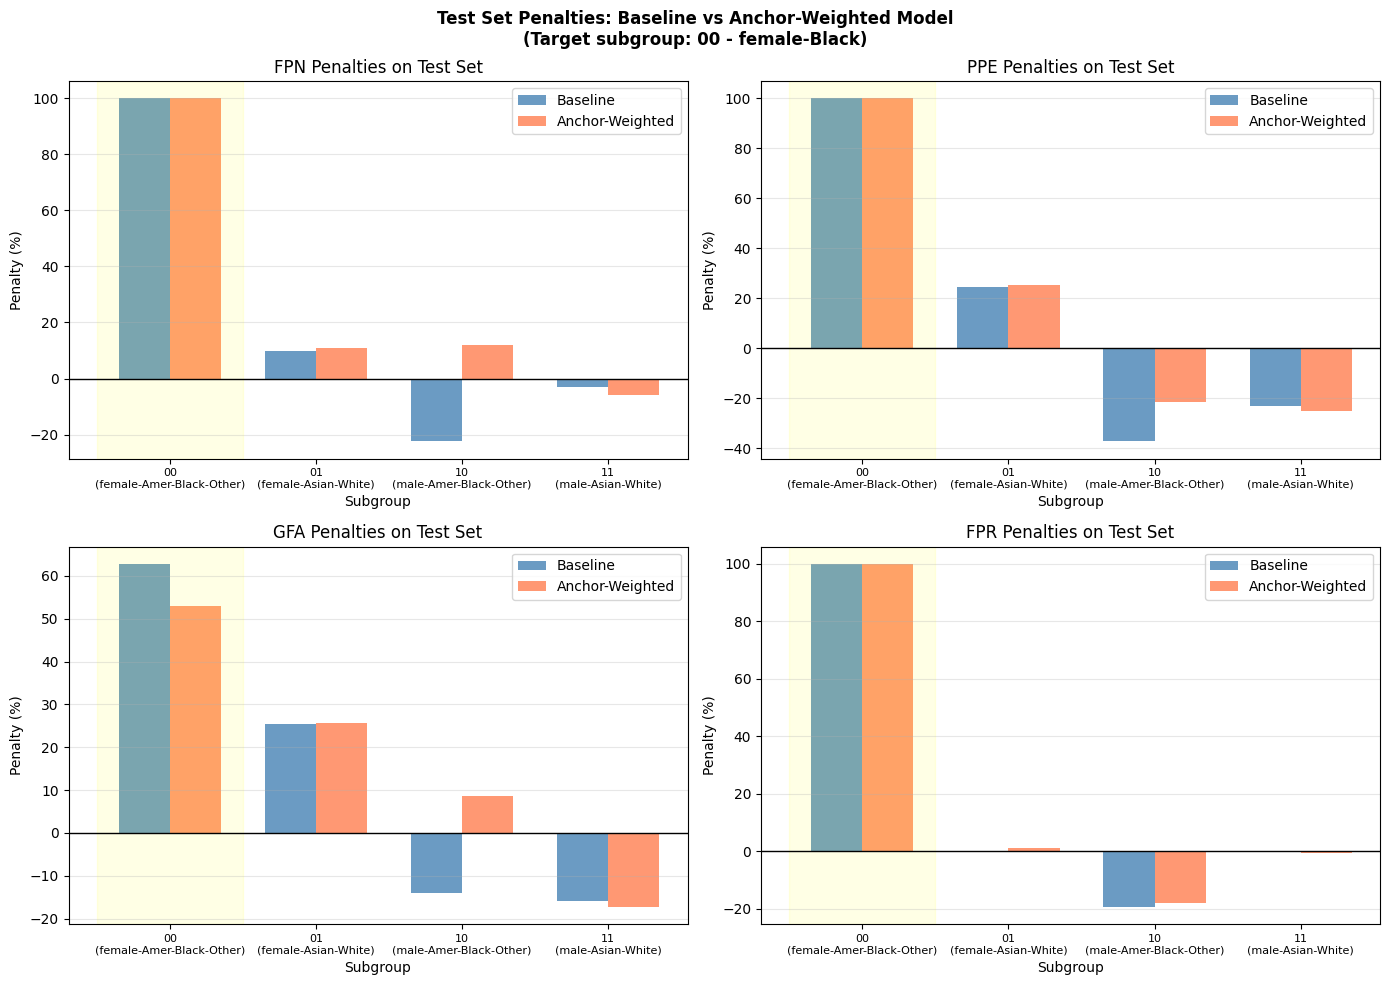


SUMMARY: Anchor-Based K-Fold Reweighting Results

Target subgroup: 00 (female-Amer-Black-Other)
Anchor samples used: 10 positive + 10 negative

Key observations:
  - Check if penalties for target subgroup ('00') moved closer to 0
  - Trade-off: improving one subgroup may affect others


In [138]:
# Visualization: Before vs After penalties (test set)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

subgroups = ['00', '01', '10', '11']
decoded_labels = ['-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))]) for g in subgroups]

# metrics_to_plot = ['FPN', 'PPE', 'EOP', 'FPR']
metrics_to_plot = ['FPN', 'PPE', 'GFA', 'FPR']

for idx, m in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    x = np.arange(len(subgroups))
    width = 0.35
    
    baseline_vals = [penalties_baseline_test[m].get(g, 0) for g in subgroups]
    weighted_vals = [penalties_weighted_test[m].get(g, 0) for g in subgroups]
    
    bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, weighted_vals, width, label='Anchor-Weighted', color='coral', alpha=0.8)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Subgroup')
    ax.set_ylabel('Penalty (%)')
    ax.set_title(f'{m} Penalties on Test Set')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight target subgroup
    ax.axvspan(-0.5, 0.5, alpha=0.1, color='yellow')

plt.suptitle('Test Set Penalties: Baseline vs Anchor-Weighted Model\n(Target subgroup: 00 - female-Black)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*100)
print("SUMMARY: Anchor-Based K-Fold Reweighting Results")
print("="*100)
print(f"\nTarget subgroup: {anchor_info['target_subgroup']} ({decoded_target})")
print(f"Anchor samples used: {anchor_info['n_pos']} positive + {anchor_info['n_neg']} negative")
print(f"\nKey observations:")
print("  - Check if penalties for target subgroup ('00') moved closer to 0")
print("  - Trade-off: improving one subgroup may affect others")
print("="*100)

# Alternative Approach: Stratified K-Fold on Subgroup×Label

## The Problem
Standard `StratifiedKFold` only stratifies on the **target label** (y=0/1), not on subgroups. This means small subgroups like black females ('00') might have 0 samples or missing labels in some folds.

## Solution Options

### Option 1: StratifiedKFold on combined (subgroup, label)
Create a combined stratification variable: `subgroup_label` = `'00_pos'`, `'00_neg'`, `'01_pos'`, etc.
This ensures each fold has proportional samples from each (subgroup, label) combination.

### Option 2: Guaranteed Minimum with Normal Training
- Run K-fold as normal for training
- For validation: ensure minimum N samples from each subgroup by "borrowing" from training if needed
- The borrowed samples are used ONLY for fairness metric computation, not for gradient updates

### About GroupShuffleSplit
`GroupShuffleSplit` ensures samples from the same "group" stay together (either all in train or all in test). This is useful when you have repeated measurements from the same subject, but **not helpful here** since we want the opposite - we want each subgroup represented in every fold.

In [139]:
# Option 1: Stratified K-Fold on Combined (Subgroup × Label)
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

def compute_penalties_kfold_subgroup_stratified(sensible_attribute, fair_metrics, n_folds=5, verbose=True):
    """
    K-Fold with stratification on BOTH subgroup AND label.
    
    This ensures each fold has proportional representation of each (subgroup, label) combination,
    preventing cases where a subgroup has 0 positives or 0 negatives in a fold.
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    # Create combined stratification variable: subgroup + label
    # e.g., "00_0" for black female with y=0, "00_1" for black female with y=1
    stratify_var = X_trainval[sensible_attribute].astype(str) + '_' + y_trainval.astype(str)
    
    if verbose:
        print("="*100)
        print(f"SUBGROUP-STRATIFIED K-FOLD CROSS-VALIDATION (K={n_folds})")
        print("="*100)
        print(f"\nStratification variable distribution:")
        strat_counts = stratify_var.value_counts().sort_index()
        for combo, count in strat_counts.items():
            subgroup, label = combo.split('_')
            decoded = '-'.join([mapping[individual_attrs[i]][int(subgroup[i])] for i in range(len(individual_attrs))])
            label_str = "positive" if label == "1" else "negative"
            print(f"  {combo} ({decoded}, {label_str}): {count} samples")
        
        # Check if any combination has fewer than n_folds samples
        min_count = strat_counts.min()
        if min_count < n_folds:
            print(f"\n  ⚠️ WARNING: Some combinations have fewer than {n_folds} samples!")
            print(f"     Minimum count: {min_count}. Consider using fewer folds.")
    
    # Initialize storage
    subgroups = sorted(X_trainval[sensible_attribute].unique())
    penalties_per_fold = {m: {g: [] for g in subgroups} for m in fair_metrics}
    
    # Setup stratified K-fold on the combined variable
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, stratify_var)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Split data for this fold
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        if verbose:
            # Show distribution in this fold's validation set
            print(f"  Validation set distribution:")
            for group in subgroups:
                group_mask = X_fold_val[sensible_attribute] == group
                n_total = group_mask.sum()
                n_pos = (y_fold_val[group_mask] == 1).sum()
                n_neg = (y_fold_val[group_mask] == 0).sum()
                decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
                status = "✓" if n_pos > 0 and n_neg > 0 else "⚠️ MISSING LABEL"
                print(f"    {group} ({decoded}): {n_total} total ({n_pos} pos, {n_neg} neg) {status}")
        
        # Convert to numeric for XGBoost
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        X_fold_val_num = X_fold_val.copy()
        X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes
        
        # Train model
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # Predict on validation
        y_pred_fold_val = model_fold.predict(X_fold_val_num)
        
        # Compute fairness metrics for each attribute
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
            
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
            )
            
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {}
    for m in fair_metrics:
        penalties_kfold_avg[m] = {}
        for group in subgroups:
            fold_penalties = penalties_per_fold[m][group]
            penalties_kfold_avg[m][group] = np.mean(fold_penalties)
    
    if verbose:
        print("\n" + "="*100)
        print("AVERAGED PENALTIES (Subgroup-Stratified K-Fold)")
        print("="*100)
        for m in fair_metrics[:3]:
            print(f"\n{m}:")
            for group in subgroups:
                decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                print(f"  {group} ({decoded:18s}): avg={avg:+.2f}%, std={std:.2f}")
    
    return penalties_kfold_avg, penalties_per_fold

In [140]:
# Option 2: Guaranteed Minimum - Normal training, but ensure minimum samples for fairness computation
def compute_penalties_kfold_guaranteed_minimum(sensible_attribute, fair_metrics, 
                                                min_samples_per_subgroup=5, n_folds=5, verbose=True):
    """
    Run normal K-fold for training, but ensure each validation fold has at least 
    min_samples_per_subgroup from each subgroup (with at least 1 pos and 1 neg).
    
    If a fold's validation set is missing samples, we "borrow" from training.
    These borrowed samples are used ONLY for fairness metric computation,
    not for model training (so no data leakage for the model itself).
    
    This is closer to the professor's intent: run code as normal, but fix anchors
    to ensure consistency in fairness evaluation.
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    if verbose:
        print("="*100)
        print(f"GUARANTEED-MINIMUM K-FOLD (K={n_folds}, min={min_samples_per_subgroup} per subgroup)")
        print("="*100)
        print("Strategy: Train normally, augment validation with borrowed samples for fairness computation")
    
    subgroups = sorted(X_trainval[sensible_attribute].unique())
    penalties_per_fold = {m: {g: [] for g in subgroups} for m in fair_metrics}
    
    # Standard stratified K-fold (on label only, as normal)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Get train/val splits (these are the actual training splits)
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        # Check each subgroup in validation and borrow if needed
        borrowed_idx = []
        
        for group in subgroups:
            # Current validation samples for this subgroup
            val_group_mask = X_fold_val[sensible_attribute] == group
            val_group_idx = X_fold_val[val_group_mask].index.tolist()
            val_group_y = y_fold_val[val_group_mask]
            
            n_val_pos = (val_group_y == 1).sum()
            n_val_neg = (val_group_y == 0).sum()
            
            # Training samples for this subgroup (potential donors)
            train_group_mask = X_fold_train[sensible_attribute] == group
            train_group_pos_mask = train_group_mask & (y_fold_train == 1)
            train_group_neg_mask = train_group_mask & (y_fold_train == 0)
            
            train_pos_idx = X_fold_train[train_group_pos_mask].index.tolist()
            train_neg_idx = X_fold_train[train_group_neg_mask].index.tolist()
            
            # Borrow positive samples if needed
            need_pos = max(0, 1 - n_val_pos)  # Ensure at least 1 positive
            if need_pos > 0 and len(train_pos_idx) > 0:
                borrow_pos = train_pos_idx[:min(need_pos, len(train_pos_idx))]
                borrowed_idx.extend(borrow_pos)
                if verbose:
                    decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
                    print(f"  Borrowed {len(borrow_pos)} positive from training for {group} ({decoded})")
            
            # Borrow negative samples if needed
            need_neg = max(0, 1 - n_val_neg)  # Ensure at least 1 negative
            if need_neg > 0 and len(train_neg_idx) > 0:
                borrow_neg = train_neg_idx[:min(need_neg, len(train_neg_idx))]
                borrowed_idx.extend(borrow_neg)
                if verbose:
                    decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
                    print(f"  Borrowed {len(borrow_neg)} negative from training for {group} ({decoded})")
        
        # Create augmented validation set (only for fairness computation)
        if borrowed_idx:
            augmented_val_idx = list(X_fold_val.index) + borrowed_idx
            X_fold_val_augmented = X_trainval.loc[augmented_val_idx]
            y_fold_val_augmented = y_trainval.loc[augmented_val_idx]
        else:
            X_fold_val_augmented = X_fold_val
            y_fold_val_augmented = y_fold_val
        
        if verbose:
            print(f"  Original val size: {len(X_fold_val)}, Augmented val size: {len(X_fold_val_augmented)}")
            for group in subgroups:
                aug_mask = X_fold_val_augmented[sensible_attribute] == group
                n_total = aug_mask.sum()
                n_pos = (y_fold_val_augmented[aug_mask] == 1).sum()
                n_neg = (y_fold_val_augmented[aug_mask] == 0).sum()
                status = "✓" if n_pos > 0 and n_neg > 0 else "⚠️"
                print(f"    {group}: {n_total} ({n_pos} pos, {n_neg} neg) {status}")
        
        # TRAIN ON ORIGINAL FOLD (no borrowed samples in training)
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # PREDICT ON AUGMENTED VALIDATION (for fairness computation)
        X_fold_val_aug_num = X_fold_val_augmented.copy()
        X_fold_val_aug_num[sensible_attribute] = X_fold_val_aug_num[sensible_attribute].astype('category').cat.codes
        
        y_pred_fold_val = model_fold.predict(X_fold_val_aug_num)
        
        # Compute fairness metrics on AUGMENTED validation set
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val_augmented.index)]
            
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val_augmented, X_fold_val_augmented, target_variable_labels
            )
            
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {m: {g: np.mean(penalties_per_fold[m][g]) for g in subgroups} for m in fair_metrics}
    
    if verbose:
        print("\n" + "="*100)
        print("AVERAGED PENALTIES (Guaranteed-Minimum K-Fold)")
        print("="*100)
        for m in fair_metrics[:3]:
            print(f"\n{m}:")
            for group in subgroups:
                decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                print(f"  {group} ({decoded:18s}): avg={avg:+.2f}%, std={std:.2f}")
    
    return penalties_kfold_avg, penalties_per_fold

## Run and Compare All K-Fold Approaches

In [141]:
# Run Option 1: Subgroup-Stratified K-Fold
print("\n" + "="*100)
print("OPTION 1: SUBGROUP-STRATIFIED K-FOLD")
print("="*100)
penalties_subgroup_strat_avg, penalties_subgroup_strat_fold = compute_penalties_kfold_subgroup_stratified(
    sensible_attribute='sex-race',
    fair_metrics=fair_metrics,
    n_folds=5,
    verbose=True
)


OPTION 1: SUBGROUP-STRATIFIED K-FOLD
SUBGROUP-STRATIFIED K-FOLD CROSS-VALIDATION (K=5)

Stratification variable distribution:
  00_0 (female-Amer-Black-Other, negative): 1411 samples
  00_1 (female-Amer-Black-Other, positive): 85 samples
  01_0 (female-Asian-White, negative): 6751 samples
  01_1 (female-Asian-White, positive): 914 samples
  10_0 (male-Amer-Black-Other, negative): 1353 samples
  10_1 (male-Amer-Black-Other, positive): 287 samples
  11_0 (male-Asian-White, negative): 11526 samples
  11_1 (male-Asian-White, positive): 5349 samples

--- Fold 1/5 ---
  Validation set distribution:
    00 (female-Amer-Black-Other): 299 total (17 pos, 282 neg) ✓
    01 (female-Asian-White): 1533 total (183 pos, 1350 neg) ✓
    10 (male-Amer-Black-Other): 328 total (58 pos, 270 neg) ✓
    11 (male-Asian-White): 3376 total (1070 pos, 2306 neg) ✓

--- Fold 2/5 ---
  Validation set distribution:
    00 (female-Amer-Black-Other): 300 total (17 pos, 283 neg) ✓
    01 (female-Asian-White): 1533 tot

In [142]:
# Run Option 2: Guaranteed Minimum K-Fold
print("\n" + "="*100)
print("OPTION 2: GUARANTEED-MINIMUM K-FOLD")
print("="*100)
penalties_guaranteed_avg, penalties_guaranteed_fold = compute_penalties_kfold_guaranteed_minimum(
    sensible_attribute='sex-race',
    fair_metrics=fair_metrics,
    min_samples_per_subgroup=5,
    n_folds=5,
    verbose=True
)


OPTION 2: GUARANTEED-MINIMUM K-FOLD
GUARANTEED-MINIMUM K-FOLD (K=5, min=5 per subgroup)
Strategy: Train normally, augment validation with borrowed samples for fairness computation

--- Fold 1/5 ---
  Original val size: 5536, Augmented val size: 5536
    00: 276 (17 pos, 259 neg) ✓
    01: 1619 (194 pos, 1425 neg) ✓
    10: 300 (43 pos, 257 neg) ✓
    11: 3341 (1073 pos, 2268 neg) ✓

--- Fold 2/5 ---
  Original val size: 5535, Augmented val size: 5535
    00: 306 (17 pos, 289 neg) ✓
    01: 1472 (174 pos, 1298 neg) ✓
    10: 341 (65 pos, 276 neg) ✓
    11: 3416 (1071 pos, 2345 neg) ✓

--- Fold 3/5 ---
  Original val size: 5535, Augmented val size: 5535
    00: 317 (21 pos, 296 neg) ✓
    01: 1545 (194 pos, 1351 neg) ✓
    10: 361 (67 pos, 294 neg) ✓
    11: 3312 (1045 pos, 2267 neg) ✓

--- Fold 4/5 ---
  Original val size: 5535, Augmented val size: 5535
    00: 310 (19 pos, 291 neg) ✓
    01: 1500 (170 pos, 1330 neg) ✓
    10: 339 (61 pos, 278 neg) ✓
    11: 3386 (1077 pos, 2309 neg) ✓

In [143]:
# Compare all approaches side by side
print("="*120)
print("COMPARISON: Standard K-Fold vs Subgroup-Stratified vs Guaranteed-Minimum")
print("="*120)

individual_attrs = sensible_attribute.split('-')

# We need to run standard K-fold first if not already done
# Using the existing penalties_kfold_avg and penalties_per_fold from earlier in notebook

for m in fair_metrics[:4]:  # Show first 4 metrics
    print(f"\n{m}:")
    print(f"  {'Group':<25} | {'Std K-Fold':>12} | {'Subgrp-Strat':>12} | {'Guaranteed':>12} | {'Std-KF σ':>10} | {'SS-KF σ':>10} | {'GM-KF σ':>10}")
    print("  " + "-"*110)
    
    for group in ['00', '01', '10', '11']:
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        # Standard K-fold (from earlier)
        std_avg = penalties_kfold_avg[m][group] if 'penalties_kfold_avg' in dir() else 0
        std_std = np.std(penalties_per_fold[m][group]) if 'penalties_per_fold' in dir() else 0
        
        # Subgroup-stratified
        ss_avg = penalties_subgroup_strat_avg[m][group]
        ss_std = np.std(penalties_subgroup_strat_fold[m][group])
        
        # Guaranteed minimum
        gm_avg = penalties_guaranteed_avg[m][group]
        gm_std = np.std(penalties_guaranteed_fold[m][group])
        
        print(f"  {group} ({decoded:18s}) | {std_avg:+12.2f} | {ss_avg:+12.2f} | {gm_avg:+12.2f} | {std_std:10.2f} | {ss_std:10.2f} | {gm_std:10.2f}")

print("\n" + "="*120)
print("INTERPRETATION:")
print("  σ = standard deviation across folds (lower = more stable)")
print("  - Subgroup-Stratified: Ensures proportional representation via stratification on (subgroup, label)")
print("  - Guaranteed-Minimum: Normal training, augments validation with borrowed samples for fairness eval")
print("="*120)

COMPARISON: Standard K-Fold vs Subgroup-Stratified vs Guaranteed-Minimum

FPN:
  Group                     |   Std K-Fold | Subgrp-Strat |   Guaranteed |   Std-KF σ |    SS-KF σ |    GM-KF σ
  --------------------------------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |       +12.97 |       +10.83 |       +12.97 |      55.40 |      58.53 |      55.40
  01 (female-Asian-White) |       +15.32 |       +16.58 |       +15.32 |       8.68 |       3.87 |       8.68
  10 (male-Amer-Black-Other) |       +16.93 |       +15.11 |       +16.93 |      22.21 |      29.49 |      22.21
  11 (male-Asian-White  ) |        -4.12 |        -4.18 |        -4.12 |       0.90 |       1.60 |       0.90

PPE:
  Group                     |   Std K-Fold | Subgrp-Strat |   Guaranteed |   Std-KF σ |    SS-KF σ |    GM-KF σ
  --------------------------------------------------------------------------------------------------------------
  00 (female-Amer

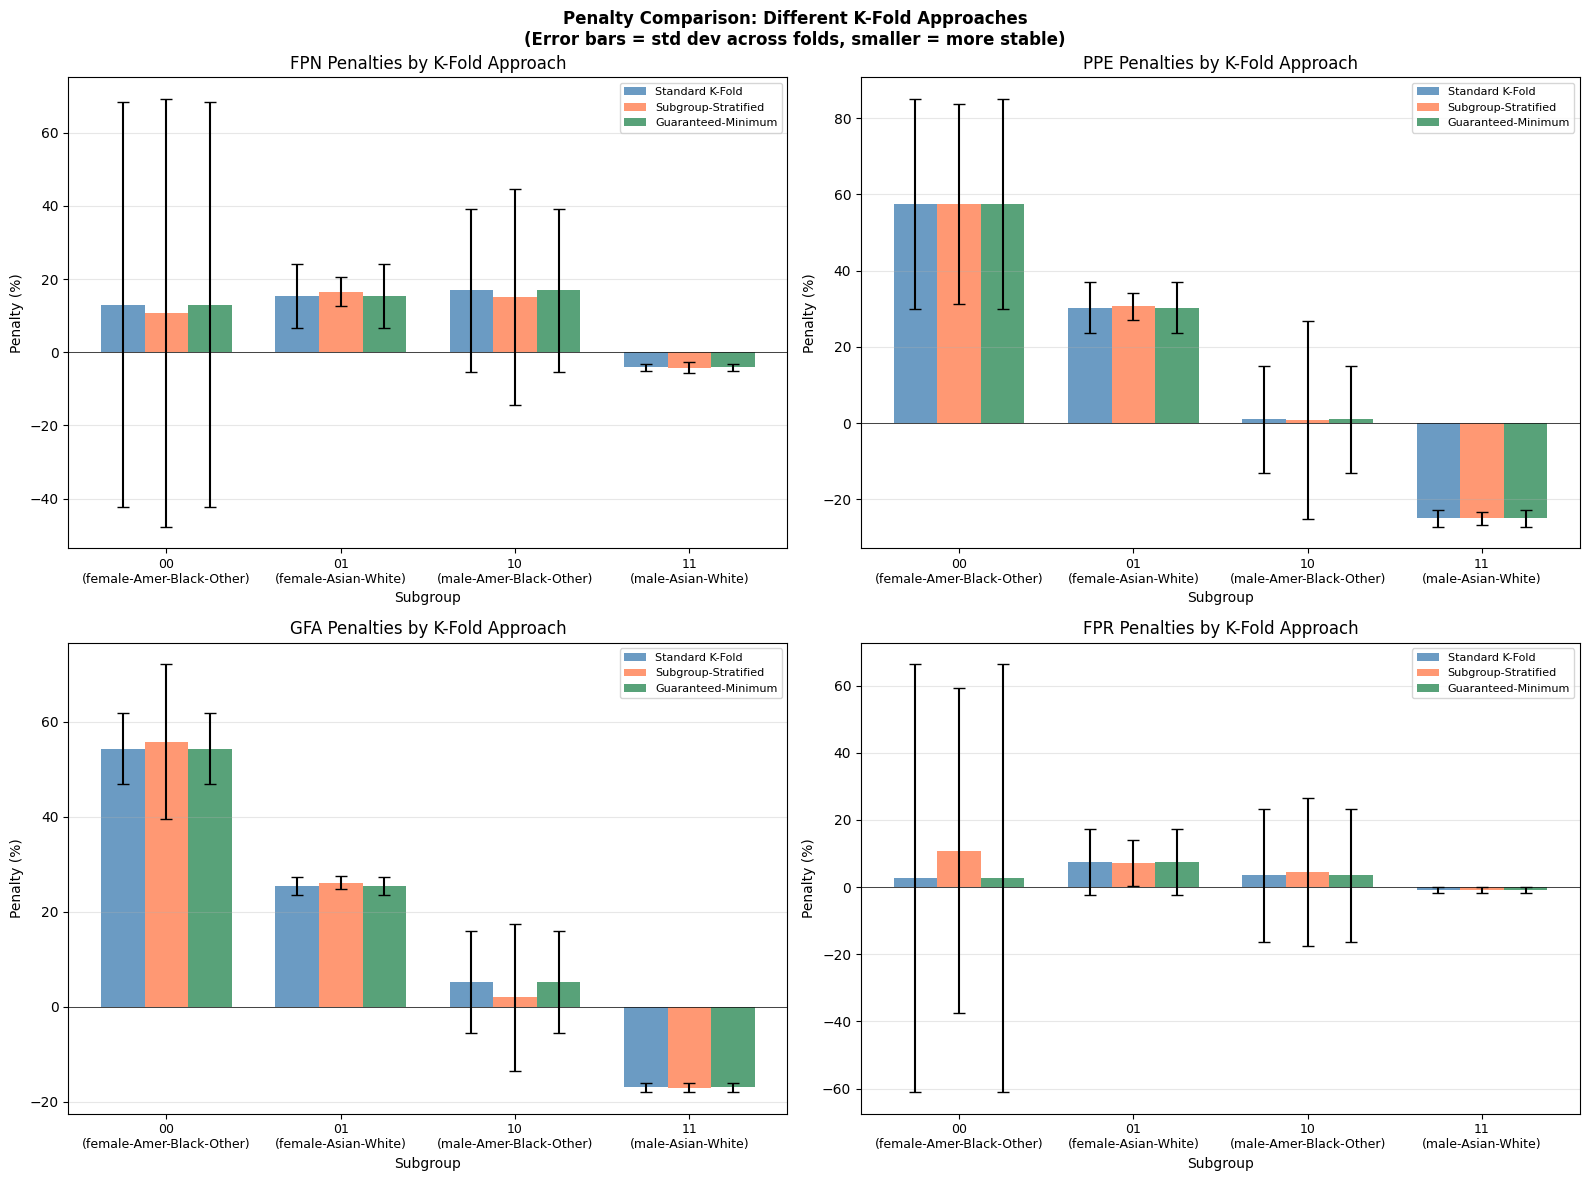

In [144]:
# Visualization: Penalty stability comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

subgroups = ['00', '01', '10', '11']
decoded_labels = ['-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))]) for g in subgroups]

# metrics_to_plot = ['FPN', 'PPE', 'EOP', 'FPR']
metrics_to_plot = ['FPN', 'PPE', 'GFA', 'FPR']

for idx, m in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    x = np.arange(len(subgroups))
    width = 0.25
    
    # Standard K-fold
    std_means = [penalties_kfold_avg[m][g] if 'penalties_kfold_avg' in dir() else 0 for g in subgroups]
    std_stds = [np.std(penalties_per_fold[m][g]) if 'penalties_per_fold' in dir() else 0 for g in subgroups]
    
    # Subgroup-stratified
    ss_means = [penalties_subgroup_strat_avg[m][g] for g in subgroups]
    ss_stds = [np.std(penalties_subgroup_strat_fold[m][g]) for g in subgroups]
    
    # Guaranteed minimum
    gm_means = [penalties_guaranteed_avg[m][g] for g in subgroups]
    gm_stds = [np.std(penalties_guaranteed_fold[m][g]) for g in subgroups]
    
    bars1 = ax.bar(x - width, std_means, width, label='Standard K-Fold', 
                   yerr=std_stds, capsize=4, color='steelblue', alpha=0.8)
    bars2 = ax.bar(x, ss_means, width, label='Subgroup-Stratified', 
                   yerr=ss_stds, capsize=4, color='coral', alpha=0.8)
    bars3 = ax.bar(x + width, gm_means, width, label='Guaranteed-Minimum', 
                   yerr=gm_stds, capsize=4, color='seagreen', alpha=0.8)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Subgroup')
    ax.set_ylabel('Penalty (%)')
    ax.set_title(f'{m} Penalties by K-Fold Approach')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Penalty Comparison: Different K-Fold Approaches\n(Error bars = std dev across folds, smaller = more stable)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion Matrix Visualization per Subgroup

Visualize TP, FP, TN, FN for each subgroup in the 2-cardinality combination (sex-race) for both validation and test sets.

In [ ]:
# Extract confusion matrix values for the combined attribute (sex-race)
combined_attr = 'sex-race'
individual_attrs = combined_attr.split('-')

# Get the confusion matrix dict for the combined attribute
cm_val_combined = cm_dict_val[combined_attr]
cm_test_combined = cm_dict_test[combined_attr]

# Prepare data for plotting
subgroups = sorted(cm_val_combined.keys())

# Decode subgroup labels
decoded_labels = []
for g in subgroups:
    decoded = '-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))])
    decoded_labels.append(decoded)

print("="*100)
print(f"CONFUSION MATRIX VALUES PER SUBGROUP ({combined_attr})")
print("="*100)

print("\nVALIDATION SET:")
print(f"  {'Subgroup':<10} | {'Decoded':<25} | {'TP':>8} | {'FP':>8} | {'TN':>8} | {'FN':>8} | {'Total':>8}")
print("  " + "-"*90)
for g, decoded in zip(subgroups, decoded_labels):
    cm = cm_val_combined[g]
    tp, fp, tn, fn = cm['TP'], cm['FP'], cm['TN'], cm['FN']
    total = tp + fp + tn + fn
    print(f"  {g:<10} | {decoded:<25} | {tp:>8} | {fp:>8} | {tn:>8} | {fn:>8} | {total:>8}")

print("\nTEST SET:")
print(f"  {'Subgroup':<10} | {'Decoded':<25} | {'TP':>8} | {'FP':>8} | {'TN':>8} | {'FN':>8} | {'Total':>8}")
print("  " + "-"*90)
for g, decoded in zip(subgroups, decoded_labels):
    cm = cm_test_combined[g]
    tp, fp, tn, fn = cm['TP'], cm['FP'], cm['TN'], cm['FN']
    total = tp + fp + tn + fn
    print(f"  {g:<10} | {decoded:<25} | {tp:>8} | {fp:>8} | {tn:>8} | {fn:>8} | {total:>8}")

In [ ]:
# Visualization 1: Stacked bar chart showing TP, FP, TN, FN per subgroup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(subgroups))
width = 0.6

# Colors for confusion matrix components
colors = {'TP': '#2ecc71', 'FP': '#e74c3c', 'TN': '#3498db', 'FN': '#f39c12'}

# Validation Set
ax1 = axes[0]
val_tp = [cm_val_combined[g]['TP'] for g in subgroups]
val_fp = [cm_val_combined[g]['FP'] for g in subgroups]
val_tn = [cm_val_combined[g]['TN'] for g in subgroups]
val_fn = [cm_val_combined[g]['FN'] for g in subgroups]

ax1.bar(x, val_tn, width, label='TN', color=colors['TN'], alpha=0.8)
ax1.bar(x, val_fp, width, bottom=val_tn, label='FP', color=colors['FP'], alpha=0.8)
ax1.bar(x, val_fn, width, bottom=np.array(val_tn)+np.array(val_fp), label='FN', color=colors['FN'], alpha=0.8)
ax1.bar(x, val_tp, width, bottom=np.array(val_tn)+np.array(val_fp)+np.array(val_fn), label='TP', color=colors['TP'], alpha=0.8)

ax1.set_xlabel('Subgroup')
ax1.set_ylabel('Count')
ax1.set_title('Confusion Matrix Components - VALIDATION Set')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=9)
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Test Set
ax2 = axes[1]
test_tp = [cm_test_combined[g]['TP'] for g in subgroups]
test_fp = [cm_test_combined[g]['FP'] for g in subgroups]
test_tn = [cm_test_combined[g]['TN'] for g in subgroups]
test_fn = [cm_test_combined[g]['FN'] for g in subgroups]

ax2.bar(x, test_tn, width, label='TN', color=colors['TN'], alpha=0.8)
ax2.bar(x, test_fp, width, bottom=test_tn, label='FP', color=colors['FP'], alpha=0.8)
ax2.bar(x, test_fn, width, bottom=np.array(test_tn)+np.array(test_fp), label='FN', color=colors['FN'], alpha=0.8)
ax2.bar(x, test_tp, width, bottom=np.array(test_tn)+np.array(test_fp)+np.array(test_fn), label='TP', color=colors['TP'], alpha=0.8)

ax2.set_xlabel('Subgroup')
ax2.set_ylabel('Count')
ax2.set_title('Confusion Matrix Components - TEST Set')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=9)
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(f'Confusion Matrix Breakdown by Subgroup ({combined_attr})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()